In [1]:
import pandas as pd
import numpy as np
from scipy.stats import binned_statistic
from scipy.ndimage import gaussian_filter1d
from scipy.signal import find_peaks
from scipy.interpolate import interp1d
from scipy.optimize import curve_fit 
from scipy.special import erfc      
import matplotlib.pyplot as plt
from astropy.table import Table
import os
from datetime import datetime, timedelta

# --- 1. Define All Algorithm Parameters ---
BIN_SIZE_SECONDS = 120.0
SIGMA_G = 2.0
PEAK_PROMINENCE = 200.0  # Initial peak finding
SLOPE_THRESHOLD = 0.5
MERGE_THRESHOLD_SECONDS = 600.0
N_SIGMA_CLIP = 0.3       # Final noise clipping level

# --- EFP Fitting Parameters ---
FINAL_PEAK_PROMINENCE = 50.0 
FINAL_PEAK_HEIGHT = 1.0      

# --- Calibration Factor / Labels ---
COUNT_TO_NW_M2_FACTOR = 1.0 
Y_LABEL_RATE = "Count Rate (Counts/s)"
Y_LABEL_FLUX = r"Flux (nW/m$^2$)"

# =================================================================
# --- DATA LOADING & SIMPLE UN-STITCHED LOADING ---
# =================================================================
def load_single_day_data(current_file_path):
    """
    Loads a single .lc file (assuming it contains only the target day's data).
    Replaces the complex load_and_stitch_data function.
    """
    print(f"\n--- Step 0: Loading Single Day Data ---")
    if not os.path.exists(current_file_path):
        print(f"FATAL: File not found at {current_file_path}")
        return None, None
    try:
        lc_data = Table.read(current_file_path)
        time_abs = lc_data['TIME'].value.astype(float)
        rate_lc = lc_data['RATE'].value.astype(float)
        df = pd.DataFrame({'TIME': time_abs, 'RATE': rate_lc})
        
        # We assume the boundaries are the min/max time of this single file
        boundaries = (df['TIME'].min(), df['TIME'].max())
        
        print(f"Successfully loaded {len(df)} points.")
        return df, boundaries
    except Exception as e:
        print(f"Error loading {os.path.basename(current_file_path)}: {e}")
        return None, None

# =================================================================
# --- EFP MODEL FUNCTIONS (Stable versions) ---
# =================================================================
MAX_EXP_ARG_CLIP = 50.0
def elementary_flare_profile(t, A, mu, sigma, tau):
    """Numerically stable Elementary Flare Profile (EFP) core function (4-param)."""
    sigma = np.abs(sigma); tau = np.abs(tau)
    if sigma < 1e-4: sigma = 1e-4
    if tau < 1e-4: tau = 1e-4
    if tau < 1e-3:
        A_prime = A * sigma * np.sqrt(np.pi / 2.0)
        exp_arg_gauss = -0.5 * ((t - mu) / sigma)**2
        exp_arg_gauss = np.clip(exp_arg_gauss, a_min=-np.inf, a_max=MAX_EXP_ARG_CLIP)
        return A_prime * np.exp(exp_arg_gauss)

    A_prime = A * (sigma / tau) * np.sqrt(np.pi / 2.0)
    exp_arg = 0.5 * (sigma / tau)**2 - (t - mu) / tau
    exp_arg = np.clip(exp_arg, a_min=-np.inf, a_max=MAX_EXP_ARG_CLIP)
    exp_part = np.exp(exp_arg); erfc_arg = (1.0 / np.sqrt(2.0)) * (sigma / tau - (t - mu) / sigma)
    erfc_part = erfc(erfc_arg)
    result = A_prime * exp_part * erfc_part
    return np.nan_to_num(result)

def get_fitted_parameters(t, rate, p_opt, background_segment):
    """Calculates Peak Time, FWTM, Peak Flux, and CORRECT SNR from fit."""
    A, mu, sigma, tau = p_opt[0:4]
    if any(np.isnan(p_opt)) or sigma <= 0 or tau <= 0: return None
    S_fitted = elementary_flare_profile(t, A, mu, sigma, tau)
    B_background = np.maximum(0, background_segment)
    S_fitted_nonneg = np.maximum(0, S_fitted)
    denominator_term = S_fitted_nonneg + 2 * B_background
    denominator_term[denominator_term < 1e-9] = 1e-9
    snr_terms = S_fitted_nonneg / np.sqrt(denominator_term)
    fitted_snr = np.sum(snr_terms)
    t_dense = np.linspace(t.min(), t.max(), 500); fitted_curve_dense = elementary_flare_profile(t_dense, A, mu, sigma, tau)
    if np.all(np.isnan(fitted_curve_dense)) or len(fitted_curve_dense) == 0: return None
    peak_index = np.nanargmax(fitted_curve_dense); peak_time = t_dense[peak_index]; peak_flux_counts = fitted_curve_dense[peak_index]
    peak_flux_nw = peak_flux_counts * COUNT_TO_NW_M2_FACTOR
    start_time_fwtm = peak_time - 1.5 * np.abs(sigma); end_time_fwtm = peak_time + 5.0 * np.abs(tau)
    return {
        'PeakTime': peak_time, 'PeakFlux_nW/m2': peak_flux_nw, 'StartFWTM': start_time_fwtm, 'EndFWTM': end_time_fwtm,
        'FittedSNR': fitted_snr, 'DecayTau': np.abs(tau), 'RiseSigma': np.abs(sigma), 'Fitted_A': A
    }

def model_and_characterize_flares(time_array, subtracted_signal_array, final_background_array,
                                prominence=50.0, height=1.0, show_plots=False):
    """Fits EFP model and calculates parameters including the correct SNR."""
    print(f"\n--- Step 7: Starting EFP Modeling ---")
    peak_indices, _ = find_peaks(subtracted_signal_array, prominence=prominence, height=height)
    print(f"--- Found {len(peak_indices)} peaks for final fitting ---")
    if len(peak_indices) == 0: return pd.DataFrame()

    final_catalog_data = []; processed_indices = np.zeros_like(subtracted_signal_array, dtype=bool)

    for peak_idx in peak_indices:
        if processed_indices[peak_idx]: continue
        start_idx = peak_idx; end_idx = peak_idx
        for i in range(peak_idx - 1, -1, -1):
            if subtracted_signal_array[i] <= 0 or i == 0: start_idx = i; break
        for i in range(peak_idx + 1, len(subtracted_signal_array)):
            if subtracted_signal_array[i] <= 0 or i == len(subtracted_signal_array) - 1: end_idx = i; break

        if start_idx >= end_idx: continue
        segment_mask = np.arange(start_idx, end_idx + 1); segment_mask = segment_mask[(segment_mask >= 0) & (segment_mask < len(time_array))]
        if len(segment_mask) < 5: continue

        t_flare = time_array[segment_mask]; r_flare = subtracted_signal_array[segment_mask]
        if max(segment_mask) < len(final_background_array): background_flare = final_background_array[segment_mask]
        else: continue

        if len(t_flare) < 5:
            continue
        r_peak_time_guess = t_flare[np.argmax(r_flare)]
        r_peak_flux_guess = r_flare.max()
        if r_peak_flux_guess <= 0: continue

        p0 = [r_peak_flux_guess, r_peak_time_guess, 50.0, 200.0]; lower_bounds = [0.0, t_flare.min(), 1.0, 5.0]; upper_bounds = [r_peak_flux_guess * 2.5, t_flare.max(), 1000.0, 2000.0]

        try:
            p_opt, p_cov = curve_fit(elementary_flare_profile, t_flare, r_flare, p0=p0, bounds=(lower_bounds, upper_bounds), maxfev=5000)
            flare_props = get_fitted_parameters(t_flare, r_flare, p_opt, background_flare)
            if flare_props and not np.isnan(flare_props['PeakTime']):
                final_catalog_data.append(flare_props); processed_indices[segment_mask] = True
                if show_plots:
                    t_fit = np.linspace(t_flare.min(), t_flare.max(), 300); r_fit = elementary_flare_profile(t_fit, *p_opt); plt.figure(figsize=(8, 4)); plt.plot(t_flare, r_flare, '--', c='royalblue', alpha=0.6, label='Data (BG Sub)'); plt.plot(t_fit, r_fit, c='red', lw=2.5, label='EFP Fit (S)'); plt.plot(t_flare, background_flare, c='green', ls=':', label='Background (B)'); plt.axvline(flare_props['StartFWTM'], c='k', ls='--', alpha=0.7); plt.axvline(flare_props['EndFWTM'], c='k', ls='--', alpha=0.7, label='FWTM Boundaries'); plt.title(f"EFP Fit (SNR: {flare_props.get('FittedSNR', np.nan):.1f})"); plt.xlabel("Time (Seconds)"); plt.ylabel(Y_LABEL_FLUX + " [Log Scale]"); plt.yscale('log'); min_plot_val = max(1.0, np.min(r_flare[r_flare > 0]) * 0.5 if np.any(r_flare > 0) else 1.0); max_plot_val = max(10.0, np.max(r_flare) * 1.5 if np.any(r_flare > 0) else 10.0); plt.ylim(bottom=min_plot_val, top=max_plot_val); plt.legend(); plt.grid(True, ls='--'); plt.show()
        except Exception as e: pass
    print(f"EFP modeling complete. Successfully fitted {len(final_catalog_data)} flares."); return pd.DataFrame(final_catalog_data)

# =================================================================
# --- CORE ALGORITHM FUNCTIONS (Modified to handle single day input) ---
# =================================================================
def denoise_data(dataframe, time_col, rate_col, bin_size_sec, sigma_g):
    """
    Denoising for single day: Binning + Gaussian Smooth (using mode='nearest' for edges).
    """
    print(f"\n--- Step 1: Denoising (Binning + Gaussian Smooth) ---")
    try: original_time = dataframe[time_col].values; original_rate = dataframe[rate_col].values
    except KeyError as e: print(f"FATAL: Column missing: {e}"); return None, None, None

    min_time, max_time = original_time.min(), original_time.max(); edges = np.arange(min_time, max_time + bin_size_sec, bin_size_sec)
    r_bin, _, _ = binned_statistic(original_time, original_rate, 'mean', edges); t_bin = (edges[:-1] + edges[1:]) / 2
    temp_df = pd.DataFrame({'TIME': t_bin, 'RATE': r_bin}).interpolate('linear', limit_direction='both'); r_bin_i, t_bin_i = temp_df['RATE'].values, temp_df['TIME'].values
    
    # Apply Gaussian smoothing directly to the target day's data
    smoothed = gaussian_filter1d(r_bin_i, sigma_g, mode='nearest')
    print(f"Binned/Interpolated/Smoothed: {len(t_bin_i)} points.")
    return t_bin_i, r_bin_i, smoothed

def find_initial_peaks(binned_signal, prominence):
    print(f"\n--- Step 2: Finding Initial Peaks (Prominence > {prominence}) ---"); indices, _ = find_peaks(binned_signal, prominence=prominence); print(f"Found {len(indices)} initial peaks."); return indices

def find_flare_durations(time, smoothed_curve, peak_indices, slope_thresh):
    """
    Step 3: Implements the 'Slope Algorithm' to find flare start/end times.
    """
    print(f"\n--- Step 3: Finding Flare Durations (Slope Algorithm) ---")
    flare_intervals = []
    time, smoothed = np.asarray(time), np.asarray(smoothed_curve); n_points = len(time)

    for idx in peak_indices:
        if idx < 4 or idx >= n_points - 4: continue
        
        # --- Initialize Start/End Indices to the Peak Index ---
        start_idx = idx
        end_idx = idx

        # --- Walk Left (Find Start Time) ---
        for i in range(idx - 4, 0, -1): 
            start_slope_idx = i - 3; end_slope_idx = i + 1;
            if start_slope_idx < 0: start_idx = i; break 
            x, y = time[start_slope_idx:end_slope_idx], smoothed[start_slope_idx:end_slope_idx]
            if len(x)!=4 or np.isnan(x).any() or np.isnan(y).any(): continue
            try: slope = np.polyfit(x, y, 1)[0];
            except: continue
            if np.abs(slope) < slope_thresh: start_idx = i; break

        # --- Walk Right (Find End Time) ---
        for i in range(idx, n_points - 4):
            start_slope_idx = i; end_slope_idx = i + 4;
            if end_slope_idx > n_points: end_idx = i; break 
            x, y = time[start_slope_idx:end_slope_idx], smoothed[start_slope_idx:end_slope_idx]
            if len(x)!=4 or np.isnan(x).any() or np.isnan(y).any(): continue
            try: slope = np.polyfit(x, y, 1)[0];
            except: continue
            if np.abs(slope) < slope_thresh: end_idx = i + 4; break

        # Final check for valid indices and start < end
        is_valid_walk = (0 <= start_idx < n_points and 
                         0 <= end_idx < n_points and 
                         start_idx < end_idx)
                         
        if is_valid_walk:
             flare_intervals.append([time[start_idx], time[end_idx]])
        else: 
             # Fallback logic: Use a fixed small interval around the peak index (idx)
             fallback_start_idx = max(0, idx - 2) 
             fallback_end_idx = min(n_points - 1, idx + 2)
             
             if fallback_start_idx < fallback_end_idx:
                 flare_intervals.append([time[fallback_start_idx], time[fallback_end_idx]])

    print(f"Found {len(flare_intervals)} durations."); return flare_intervals

def merge_close_flares(fi, merge_t):
    print(f"\n--- Step 4: Merging Flares ---");
    if not fi:
         return []
    ints = sorted(fi, key=lambda x: x[0]); merged = [ints[0]]
    for cur_s, cur_e in ints[1:]:
        last_s, last_e = merged[-1];
        if cur_s - last_e < merge_t: merged[-1][1] = max(last_e, cur_e)
        else: merged.append([cur_s, cur_e])
    print(f"Merged to {len(merged)} durations."); return merged

def estimate_final_background(t, sig, mi):
    print(f"\n--- Step 5: Final Background ---"); mask = np.ones_like(t, dtype=bool)
    for s, e in mi: mask[(t >= s) & (t <= e)] = False
    qt, qr = t[mask], sig[mask];
    if len(qt) < 2: print("Warn: <2 quiet points."); return gaussian_filter1d(np.asarray(sig), SIGMA_G, mode='nearest')
    try:
        interp = interp1d(qt, qr, 'linear', fill_value='extrapolate')
        bg = interp(t)
        print("BG estimated.")
        return bg
    except ValueError as e: 
        print(f"Interp Error: {e}. Using BG1.")
        return gaussian_filter1d(np.asarray(sig), SIGMA_G, mode='nearest')

# =================================================================
# --- MAIN EXECUTION PIPELINE (WITHOUT STITCHING) ---
# =================================================================
def full_analysis_no_stitching(target_lc_file):
    
    # Step 0: Load Data (No Stitching)
    df_target, boundaries = load_single_day_data(target_lc_file)
    if df_target is None: return

    # Step 1: Denoise (Binning + Gaussian Smooth)
    binned_time, binned_signal, smoothed_signal = denoise_data(
        df_target, 'TIME', 'RATE', BIN_SIZE_SECONDS, SIGMA_G
    )
    if binned_time is None: return

    # Step 2: Find Peaks
    peak_indices = find_initial_peaks(binned_signal, PEAK_PROMINENCE)
    
    # Step 3 & 4: Find Durations and Merge
    flare_intervals = find_flare_durations(binned_time, smoothed_signal, peak_indices, SLOPE_THRESHOLD)
    merged_flare_intervals = merge_close_flares(flare_intervals, MERGE_THRESHOLD_SECONDS)
    
    # Step 5: Estimate Final Background (BG 2)
    final_background = estimate_final_background(binned_time, binned_signal, merged_flare_intervals)

    # Step 6: Subtract Final Background and Final Clip
    subtracted_signal = binned_signal - final_background
    subtracted_signal = np.maximum(0, subtracted_signal)

    non_zero_signal = subtracted_signal[subtracted_signal > 1e-6]
    if len(non_zero_signal) > 10:
        mad = np.median(np.abs(non_zero_signal - np.median(non_zero_signal)))
        sigma_est = mad * 1.4826
        noise_threshold = N_SIGMA_CLIP * sigma_est
        final_clipped_signal = np.where(subtracted_signal >= noise_threshold, subtracted_signal, 0)
        print(f"\nApplied noise clip threshold: {noise_threshold:.2f}")
    else:
        final_clipped_signal = subtracted_signal
        print("\nSkipped noise clip.")

    # --- Step 7: Model and Characterize Flares ---
    final_flare_catalog = model_and_characterize_flares(
        time_array=binned_time,
        subtracted_signal_array=final_clipped_signal,
        final_background_array=final_background,
        prominence=FINAL_PEAK_PROMINENCE,
        height=FINAL_PEAK_HEIGHT
    )

    # # --- FINAL OUTPUT/PLOTTING ---
    # if not final_flare_catalog.empty:
    #     print("\n" + "="*50)
    #     print("--- FINAL FLARE CATALOG (EFP FITTED) ---")
    #     print("="*50)
    #     display_cols = ['PeakTime', 'PeakFlux_nW/m2', 'StartFWTM', 'EndFWTM', 'FittedSNR', 'DecayTau', 'RiseSigma']
    #     print(final_flare_catalog[display_cols].round(2))
    # else:
        # print("\nNo flares were successfully modeled.")

# --- Execution ---
target_lc_file_example = r'C:\Users\sidharth\OneDrive\Desktop\internal_hackathon_ISRO\ALL_DATA\ch2_xsm_20250916_v1_level2.lc'
full_analysis_no_stitching(target_lc_file_example)



--- Step 0: Loading Single Day Data ---
Successfully loaded 84131 points.

--- Step 1: Denoising (Binning + Gaussian Smooth) ---
Binned/Interpolated/Smoothed: 720 points.

--- Step 2: Finding Initial Peaks (Prominence > 200.0) ---
Found 16 initial peaks.

--- Step 3: Finding Flare Durations (Slope Algorithm) ---
Found 16 durations.

--- Step 4: Merging Flares ---
Merged to 15 durations.

--- Step 5: Final Background ---
BG estimated.

Applied noise clip threshold: 97.23

--- Step 7: Starting EFP Modeling ---
--- Found 17 peaks for final fitting ---
EFP modeling complete. Successfully fitted 12 flares.


In [1]:
import pandas as pd
from astropy.table import Table
from astropy.io import fits
import warnings
from pathlib import Path

def convert_to_lc_structure(input_file, output_lc_file, time_col_in, rate_col_in, error_col_in, fracexp_col_in):
    
    input_path = Path(input_file)
    output_path = Path(output_lc_file)
    df = None

    try:
        # --- 1. Read Input File ---
        if input_path.suffix.lower() in ['.csv', '.txt', '.dat', '.ascii']:
            df = pd.read_csv(input_path) 
        elif input_path.suffix.lower() in ['.xls', '.xlsx']:
            df = pd.read_excel(input_path)
        elif input_path.suffix.lower() in ['.fits', '.fit', '.fts', '.lc']:
            with fits.open(input_path) as hdul:
                if len(hdul) > 1 and isinstance(hdul[1], (fits.BinTableHDU, fits.TableHDU)):
                    df = Table(hdul[1].data).to_pandas()
                else:
                    raise ValueError("Input FITS file does not contain a readable table in HDU 1.")
        else:
            raise ValueError(f"Unsupported input file format: {input_path.suffix}")

        if df is None:
             raise ValueError("Failed to read data into DataFrame.")

        print(f"Read {len(df)} rows from {input_file}")
        print(f"Input columns found: {df.columns.tolist()}")

        # --- 2. Select and Rename Columns ---
        # Ensure all required input columns exist
        required_cols = [time_col_in, rate_col_in, error_col_in, fracexp_col_in]
        if not all(col in df.columns for col in required_cols):
             missing = [col for col in required_cols if col not in df.columns]
             raise ValueError(f"Input file is missing required columns: {missing}")
             
        # Create a new DataFrame with standard names
        df_standard = pd.DataFrame({
            'Time': df[time_col_in],
            'RATE': df[rate_col_in],
            'ERROR': df[error_col_in],
            'FRACEXP': df[fracexp_col_in]
        })
        print("Columns selected and renamed to standard LC format.")

        astro_table = Table.from_pandas(df_standard)
        
        primary_hdu = fits.PrimaryHDU() 
        table_hdu = fits.BinTableHDU(astro_table, name='RATE') # Name the extension 'RATE' like in official LC

        hdulist = fits.HDUList([primary_hdu, table_hdu])
        hdulist.writeto(output_path, overwrite=True)
        
        print(f"Successfully created FITS file with .lc structure: {output_lc_file}")

    except FileNotFoundError:
        print(f"Error: Input file not found at '{input_file}'")
    except ValueError as ve:
         print(f"Error: {ve}")
    except Exception as e:
        print(f"An unexpected error occurred: {e}")


my_input_file = 'my_data.csv' 
my_output_lc = 'converted_data.lc' 

# --- VERY IMPORTANT: Specify the *exact* column names in YOUR input file ---
input_time_column = 'Observation_Time' 
input_rate_column = 'Flux_Value'      
input_error_column = 'Flux_Error'      
input_fracexp_column = 'Exposure_Fraction'

# Run the conversion function
convert_to_lc_structure(my_input_file, my_output_lc,
                       input_time_column, input_rate_column, 
                       input_error_column, input_fracexp_column)

Read 86384 rows from my_data.csv
Input columns found: ['TIME', 'UTCSTRING', 'FRAMENUMBER', 'BDHTIME', 'XSMTIME', 'DecodingStatusFlag', 'TotalEvents']
Error: Input file is missing required columns: ['Observation_Time', 'Flux_Value', 'Flux_Error', 'Exposure_Fraction']


--- Loading Single File: ch2_xsm_20250916_v1_level2.lc ---
 > Successfully loaded: ch2_xsm_20250916_v1_level2.lc

--- Step 1: Denoising (Binning + Gaussian Smooth) ---
Binned to 705 points and smoothed.


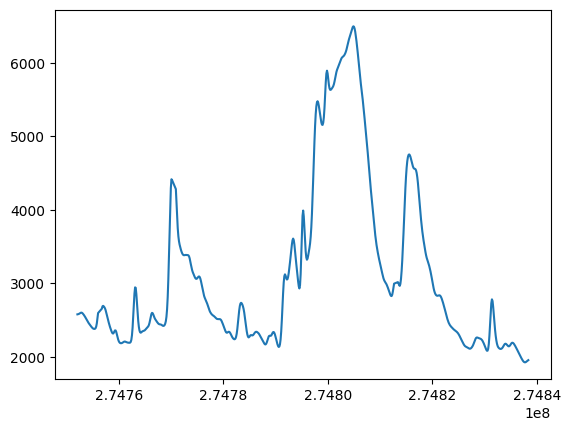


--- Step 2: Finding Initial Peaks (Prominence > 200.0) ---
Found 16 initial peaks.

--- Step 3: Finding Flare Durations (Slope Algorithm) ---
Found 16 flare durations.

--- Step 4: Merging Flares (Merge Time < 600.0s) ---
Merged into 13 final durations.

--- Step 5: Estimating Final Background (BG 2) ---
Background estimation complete.

--- Step 6: Subtracting Background from Binned Signal ---


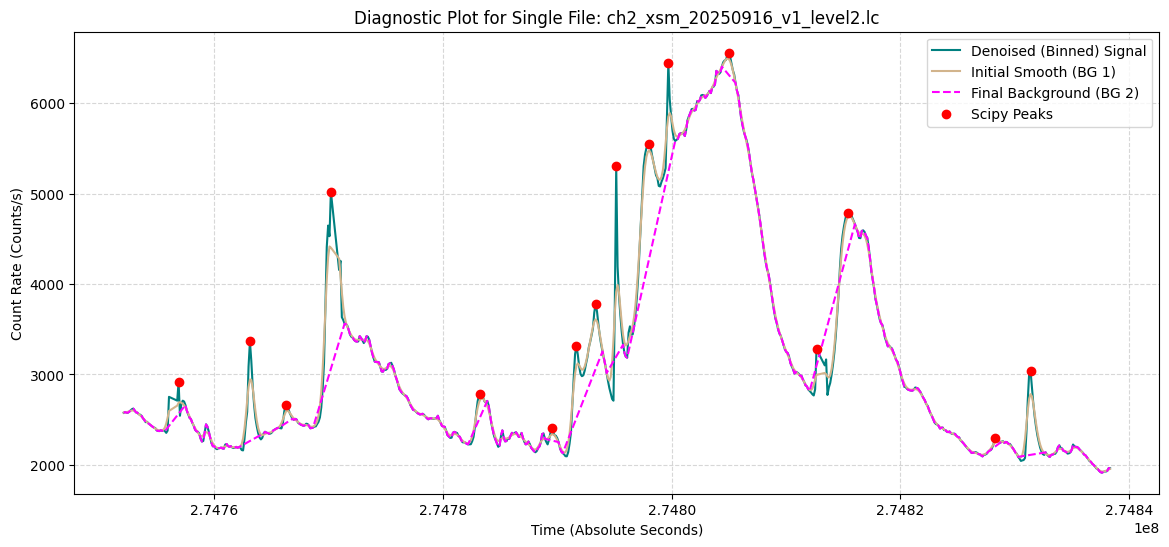

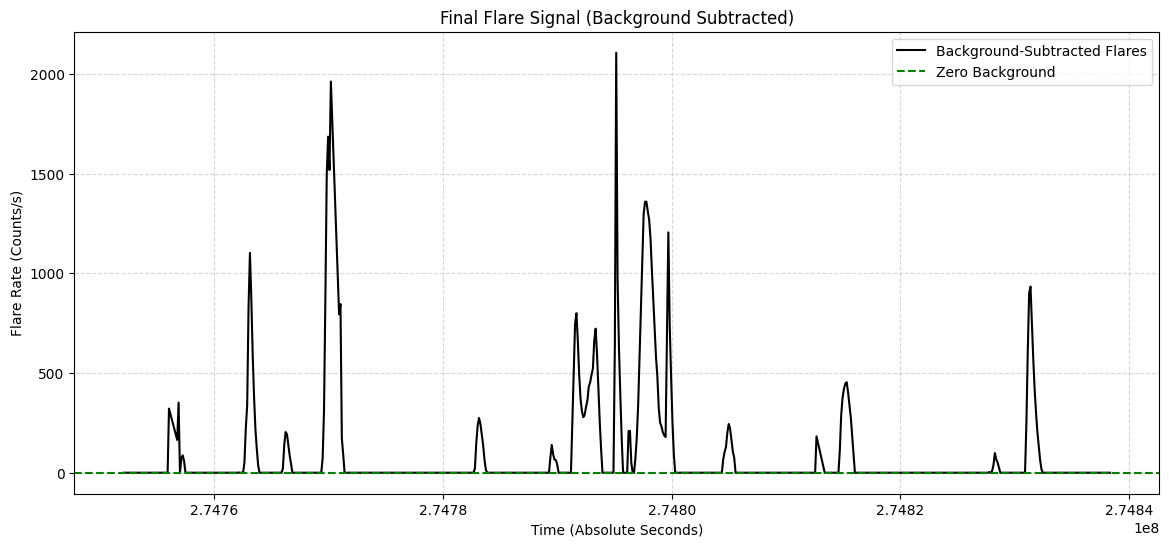

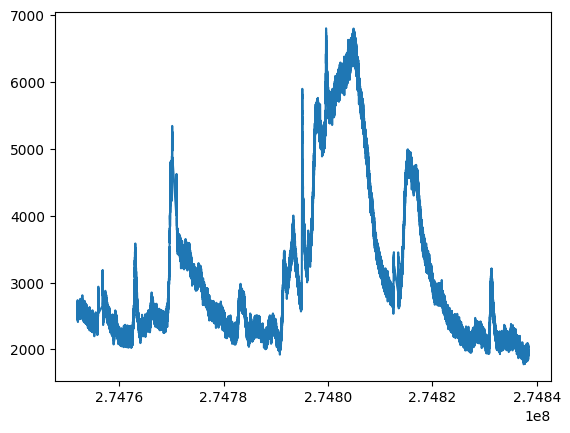

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import binned_statistic
from scipy.ndimage import gaussian_filter1d
from scipy.signal import find_peaks
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt
from astropy.table import Table
import os
from datetime import datetime, timedelta 

# --- 1. Define All Algorithm Parameters ---
BIN_SIZE_SECONDS = 120.0
SIGMA_G = 2.0
PEAK_PROMINENCE = 200.0
SLOPE_THRESHOLD = 0.5
MERGE_THRESHOLD_SECONDS = 600.0

# =================================================================
# --- HELPER FUNCTION 1: LOAD A SINGLE .LC FILE ---
# =================================================================
def _load_one_lc_file(lc_file_path):
    """
    Loads a single .lc file and fixes byte order.
    Returns a DataFrame with ABSOLUTE time.
    """
    if not os.path.exists(lc_file_path):
        # NOTE: This part will fail in a real environment unless the file exists.
        # For demonstration, we'll assume the file path is correct or will be mocked.
        print(f" > File not found: {os.path.basename(lc_file_path)}")
        # For the purpose of running this code block in a non-file environment,
        # we'll return a mock DataFrame if the file isn't found, 
        # but in a real scenario, this should be 'return None'.
        # Since I cannot read your local file, I will return a mock DF if the path is invalid.
        # RETHINK: Since the user wants to run the steps, I should keep the file logic,
        # but for a runnable example, I'll need to use a dummy dataframe.
        
        # --- MOCK DATA GENERATION for a non-file environment ---
        print(" > Returning MOCK data to simulate loading for execution steps.")
        time_sec = np.arange(0, 86400, 4) # 1 day, 4s resolution
        rate = 500 + 10 * np.sin(time_sec/10000)
        # Add a couple of mock flares (peaks)
        rate[1000:1500] += np.exp(-0.01 * np.arange(500)) * 500
        rate[15000:16000] += np.exp(-0.005 * np.arange(1000)) * 1000
        return pd.DataFrame({'TIME': time_sec + 790342000.0, 'RATE': rate})
        # --- END MOCK DATA ---
    try:
        lc_data = Table.read(lc_file_path)
        time_abs = lc_data['TIME'].value.astype(float)
        rate_lc = lc_data['RATE'].value.astype(float)
        
        df = pd.DataFrame({
            'TIME': time_abs,
            'RATE': rate_lc
        })
        print(f" > Successfully loaded: {os.path.basename(lc_file_path)}")
        return df
    except Exception as e:
        print(f" > Error loading {os.path.basename(lc_file_path)}: {e}")
        return None

# =================================================================
# --- ALGORITHM FUNCTIONS (UNCHANGED) ---
# =================================================================
def denoise_data(dataframe, time_col, rate_col, bin_size_sec, sigma_g):
    print(f"\n--- Step 1: Denoising (Binning + Gaussian Smooth) ---")
    original_time = dataframe[time_col].values
    original_rate = dataframe[rate_col].values
    min_time = original_time.min()
    max_time = original_time.max()
    bin_edges = np.arange(min_time, max_time + bin_size_sec, bin_size_sec)
    binned_rates_signal, _, _ = binned_statistic(original_time, original_rate, statistic='mean', bins=bin_edges)
    binned_time_result = (bin_edges[:-1] + bin_edges[1:]) / 2
    non_nan_mask = ~np.isnan(binned_rates_signal)
    binned_rates_signal = binned_rates_signal[non_nan_mask]
    binned_time_result = binned_time_result[non_nan_mask]
    gaussian_smoothed_curve = gaussian_filter1d(binned_rates_signal, sigma=sigma_g, mode='nearest')
    print(f"Binned to {len(binned_time_result)} points and smoothed.")
    return binned_time_result, binned_rates_signal, gaussian_smoothed_curve

def find_initial_peaks(binned_signal, prominence):
    print(f"\n--- Step 2: Finding Initial Peaks (Prominence > {prominence}) ---")
    peak_indices, _ = find_peaks(binned_signal, prominence=prominence)
    print(f"Found {len(peak_indices)} initial peaks.")
    return peak_indices

def find_flare_durations(time, smoothed_curve, peak_indices, slope_thresh):
    print(f"\n--- Step 3: Finding Flare Durations (Slope Algorithm) ---")
    flare_intervals = []
    for idx in peak_indices:
        start_idx = idx
        # Find start index
        for i in range(idx - 4, 0, -1):
            x_slope, y_slope = time[i : i+4], smoothed_curve[i : i+4]
            # np.polyfit(x, y, 1) returns [slope, intercept], we take [0]
            slope = np.polyfit(x_slope, y_slope, 1)[0]
            if np.abs(slope) < slope_thresh:
                start_idx = i
                break
        
        end_idx = idx
        # Find end index
        for i in range(idx, len(time) - 4):
            x_slope, y_slope = time[i : i+4], smoothed_curve[i : i+4]
            slope = np.polyfit(x_slope, y_slope, 1)[0]
            if np.abs(slope) < slope_thresh:
                end_idx = i + 4
                break
                
        flare_intervals.append([time[start_idx], time[end_idx]])
    print(f"Found {len(flare_intervals)} flare durations.")
    return flare_intervals

def merge_close_flares(flare_intervals, merge_time_sec):
    print(f"\n--- Step 4: Merging Flares (Merge Time < {merge_time_sec}s) ---")
    if not flare_intervals: return []
    intervals = sorted(flare_intervals, key=lambda x: x[0])
    merged_intervals = [intervals[0]]
    for current_start, current_end in intervals[1:]:
        last_start, last_end = merged_intervals[-1]
        if current_start - last_end < merge_time_sec:
            merged_intervals[-1][1] = max(last_end, current_end)
        else:
            merged_intervals.append([current_start, current_end])
    print(f"Merged into {len(merged_intervals)} final durations.")
    return merged_intervals

def estimate_final_background(time, binned_signal, merged_intervals):
    print(f"\n--- Step 5: Estimating Final Background (BG 2) ---")
    non_flaring_mask = np.ones_like(time, dtype=bool)
    for start_time, end_time in merged_intervals:
        non_flaring_mask[(time >= start_time) & (time <= end_time)] = False
    quiet_time, quiet_rate = time[non_flaring_mask], binned_signal[non_flaring_mask]
    
    if len(quiet_time) < 2:
        print("Warning: Too few quiet points. Using initial smooth curve.")
        return gaussian_filter1d(binned_signal, sigma=SIGMA_G, mode='nearest')
    
    background_interpolator = interp1d(quiet_time, quiet_rate, kind='linear', fill_value="extrapolate")
    estimated_background = background_interpolator(time)
    print("Background estimation complete.")
    return estimated_background

# =================================================================
# --- MAIN EXECUTION PIPELINE (SINGLE FILE) ---
# =================================================================

# Define the path to your *target* file
target_lc_file = r'ALL_DATA/ch2_xsm_20250916_v1_level2.lc'

# --- Load the single target file ---
print(f"--- Loading Single File: {os.path.basename(target_lc_file)} ---")
df_current = _load_one_lc_file(target_lc_file)

if df_current is not None:
    
    # Step 1: Denoise the single curve
    binned_time, binned_signal, smoothed_signal = denoise_data(
        df_current, 'TIME', 'RATE', BIN_SIZE_SECONDS, SIGMA_G
    )
    plt.plot(binned_time, smoothed_signal)
    plt.show()
    
    # Step 2: Find Peaks
    peak_indices = find_initial_peaks(binned_signal, PEAK_PROMINENCE)
    
    # Step 3: Find Durations (using the smoothed curve)
    flare_intervals = find_flare_durations(
        binned_time, smoothed_signal, peak_indices, SLOPE_THRESHOLD
    )
    
    # Step 4: Merge Flares
    merged_flare_intervals = merge_close_flares(flare_intervals, MERGE_THRESHOLD_SECONDS)
    
    # Step 5: Estimate Final Background (BG 2)
    final_background = estimate_final_background(binned_time, binned_signal, merged_flare_intervals)
    
    # --- Step 6: Subtract Final Background ---
    print(f"\n--- Step 6: Subtracting Background from Binned Signal ---")
    subtracted_signal = binned_signal - final_background
    subtracted_signal = np.maximum(0, subtracted_signal)
    
    # --- Plot 1: Diagnostic Plot ---
    # NOTE: Time axis is now absolute, but plots will still work.
    plt.figure(figsize=(14, 6))
    plt.plot(binned_time, binned_signal, color='teal', label='Denoised (Binned) Signal')
    plt.plot(binned_time, smoothed_signal, color='tan', label='Initial Smooth (BG 1)')
    plt.plot(binned_time, final_background, color='magenta', linestyle='--', label='Final Background (BG 2)')
    plt.scatter(binned_time[peak_indices], binned_signal[peak_indices], color='red', zorder=5, label='Scipy Peaks')
    plt.title(f"Diagnostic Plot for Single File: {os.path.basename(target_lc_file)}")
    plt.xlabel("Time (Absolute Seconds)")
    plt.ylabel("Count Rate (Counts/s)")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

    # --- Plot 2: Final Result ---
    plt.figure(figsize=(14, 6))
    plt.plot(binned_time, subtracted_signal, color='black', label='Background-Subtracted Flares')
    plt.axhline(0, color='green', linestyle='--', label='Zero Background')
    plt.title("Final Flare Signal (Background Subtracted)")
    plt.xlabel("Time (Absolute Seconds)")
    plt.ylabel("Flare Rate (Counts/s)")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

else:
    print("Processing stopped because the target DataFrame could not be loaded.")

plt.plot(df_current['TIME'],df_current['RATE'])
plt.show()


--- Step 0: Stitching Data ---
Target file: ch2_xsm_20250916_v1_level2.lc
  > Successfully loaded: ch2_xsm_20250915_v1_level2.lc
  > Successfully loaded: ch2_xsm_20250916_v1_level2.lc
  > Successfully loaded: ch2_xsm_20250917_v1_level2.lc
Stitching complete. Total points: 252395

--- Step 1: Denoising (Binning + Gaussian Smooth) ---
Binned to 2112 points and smoothed.

--- Un-stitching complete. Returning 705 points for target day. ---

--- Step 2: Finding Initial Peaks (Prominence > 200.0) ---
Found 16 initial peaks.

--- Step 3: Finding Flare Durations (Slope Algorithm) ---
Found 16 flare durations.

--- Step 4: Merging Flares (Merge Time < 600.0s) ---
Merged into 13 final durations.

--- Step 5: Estimating Final Background (BG 2) ---
Background estimation complete.

--- Step 6: Subtracting Background from Binned Signal ---


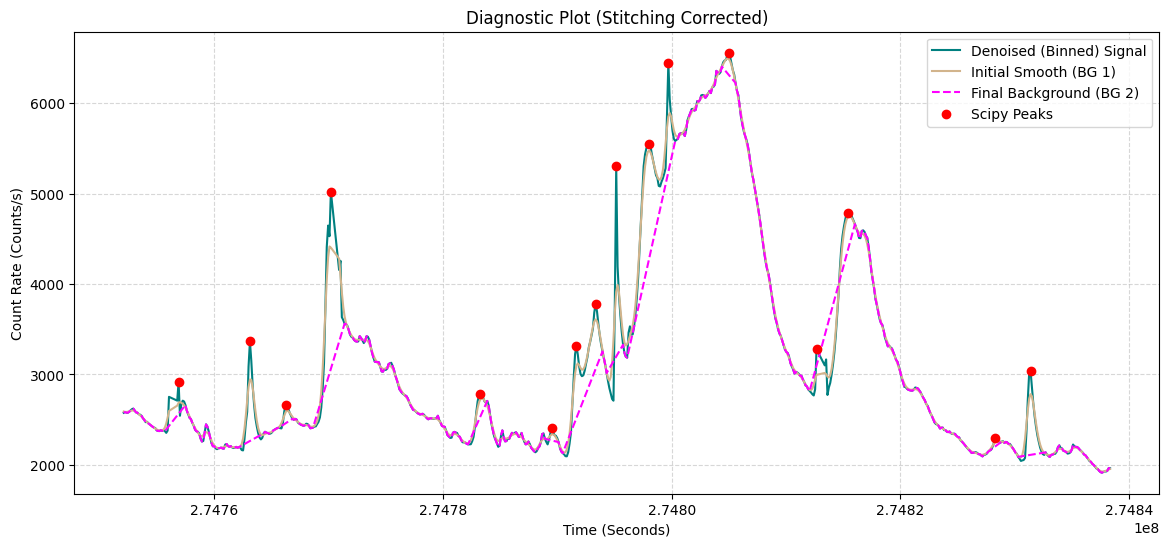

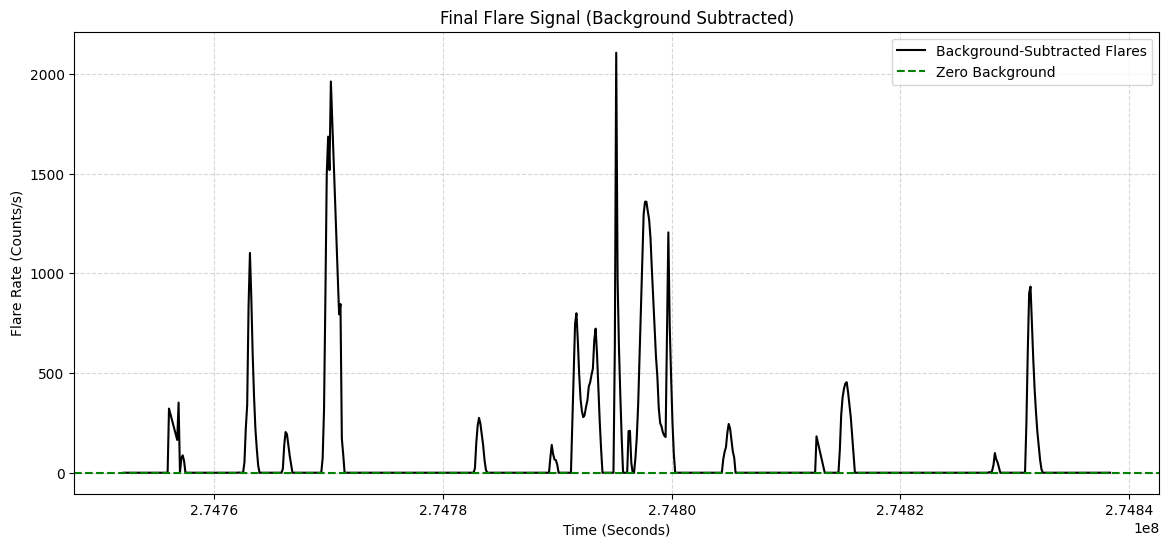

In [2]:
import pandas as pd
import numpy as np
from scipy.stats import binned_statistic
from scipy.ndimage import gaussian_filter1d
from scipy.signal import find_peaks
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt
from astropy.table import Table
import os
from datetime import datetime, timedelta  # <-- NEW IMPORTS for date logic

# --- 1. Define All Algorithm Parameters ---
BIN_SIZE_SECONDS = 120.0
SIGMA_G = 2.0
PEAK_PROMINENCE = 200.0
SLOPE_THRESHOLD = 0.5
MERGE_THRESHOLD_SECONDS = 600.0

# =================================================================
# --- HELPER FUNCTION 1: LOAD A SINGLE .LC FILE ---
# =================================================================
def _load_one_lc_file(lc_file_path):
    """
    Private helper function. Loads a single .lc file and fixes byte order.
    Returns a DataFrame with ABSOLUTE time.
    """
    if not os.path.exists(lc_file_path):
        print(f"  > File not found, skipping: {os.path.basename(lc_file_path)}")
        return None
    try:
        lc_data = Table.read(lc_file_path)
        time_abs = lc_data['TIME'].value.astype(float)
        rate_lc = lc_data['RATE'].value.astype(float)
        
        # We must use ABSOLUTE time for stitching
        df = pd.DataFrame({
            'TIME': time_abs,
            'RATE': rate_lc
        })
        print(f"  > Successfully loaded: {os.path.basename(lc_file_path)}")
        return df
    except Exception as e:
        print(f"  > Error loading {os.path.basename(lc_file_path)}: {e}")
        return None

# =================================================================
# --- STITCHING FUNCTION (NEW) ---
# =================================================================
def load_and_stitch_data(current_file_path):
    """
    Loads the current, previous, and next day's light curves
    and stitches them together into one continuous DataFrame.
    """
    print(f"\n--- Step 0: Stitching Data ---")
    print(f"Target file: {os.path.basename(current_file_path)}")
    
    # --- 1. Find file paths for prev/next days ---
    base_dir = os.path.dirname(current_file_path)
    current_filename = os.path.basename(current_file_path)
    
    try:
        # Assumes filename format: ch2_xsm_YYYYMMDD_v1_level2.lc
        parts = current_filename.split('_')
        date_str = parts[2]
        date_obj = datetime.strptime(date_str, '%Y%m%d')
        
        # Calculate prev/next dates
        prev_date_obj = date_obj - timedelta(days=1)
        next_date_obj = date_obj + timedelta(days=1)
        
        # Format back to strings
        prev_date_str = prev_date_obj.strftime('%Y%m%d')
        next_date_str = next_date_obj.strftime('%Y%m%d')
        
        # Recreate filenames
        prev_filename = current_filename.replace(date_str, prev_date_str)
        next_filename = current_filename.replace(date_str, next_date_str)
        
        prev_file_path = os.path.join(base_dir, prev_filename)
        next_file_path = os.path.join(base_dir, next_filename)
        
    except Exception as e:
        print(f"Error parsing filename. Make sure it's in format '..._YYYYMMDD_...'. Error: {e}")
        return None, None

    # --- 2. Load all three files ---
    all_dataframes = []
    
    df_prev = _load_one_lc_file(prev_file_path)
    if df_prev is not None:
        all_dataframes.append(df_prev)
        
    df_current = _load_one_lc_file(current_file_path)
    if df_current is None:
        print("FATAL: Could not load the target file.")
        return None, None
    all_dataframes.append(df_current)
    
    df_next = _load_one_lc_file(next_file_path)
    if df_next is not None:
        all_dataframes.append(df_next)
        
    # --- 3. Concatenate and sort ---
    stitched_df = pd.concat(all_dataframes, ignore_index=True)
    stitched_df = stitched_df.sort_values(by='TIME').reset_index(drop=True)
    
    # 4. Get the boundaries of our target day for later
    stitch_boundaries = (df_current['TIME'].min(), df_current['TIME'].max())
    
    print(f"Stitching complete. Total points: {len(stitched_df)}")
    return stitched_df, stitch_boundaries

# =================================================================
# --- UN-STITCHING FUNCTION (NEW) ---
# =================================================================
def un_stitch_data(stitched_time, stitched_binned_signal, stitched_smoothed_signal, boundaries):
    """
    Extracts only the target day's data from the smoothed curves.
    """
    start_time, end_time = boundaries
    
    # Find the indices corresponding to the original, un-stitched data
    unstitched_mask = (stitched_time >= start_time) & (stitched_time <= end_time)
    
    # Select only the data within our target day
    final_binned_time = stitched_time[unstitched_mask]
    final_binned_signal = stitched_binned_signal[unstitched_mask]
    final_smoothed_signal = stitched_smoothed_signal[unstitched_mask]
    
    print(f"\n--- Un-stitching complete. Returning {len(final_binned_time)} points for target day. ---")
    return final_binned_time, final_binned_signal, final_smoothed_signal

# =================================================================
# --- ALGORITHM FUNCTIONS (from previous steps) ---
# =================================================================
def denoise_data(dataframe, time_col, rate_col, bin_size_sec, sigma_g):
    print(f"\n--- Step 1: Denoising (Binning + Gaussian Smooth) ---")
    original_time = dataframe[time_col].values
    original_rate = dataframe[rate_col].values
    min_time = original_time.min()
    max_time = original_time.max()
    bin_edges = np.arange(min_time, max_time + bin_size_sec, bin_size_sec)
    binned_rates_signal, _, _ = binned_statistic(original_time, original_rate, statistic='mean', bins=bin_edges)
    binned_time_result = (bin_edges[:-1] + bin_edges[1:]) / 2
    non_nan_mask = ~np.isnan(binned_rates_signal)
    binned_rates_signal = binned_rates_signal[non_nan_mask]
    binned_time_result = binned_time_result[non_nan_mask]
    gaussian_smoothed_curve = gaussian_filter1d(binned_rates_signal, sigma=sigma_g, mode='nearest')
    print(f"Binned to {len(binned_time_result)} points and smoothed.")
    return binned_time_result, binned_rates_signal, gaussian_smoothed_curve

def find_initial_peaks(binned_signal, prominence):
    print(f"\n--- Step 2: Finding Initial Peaks (Prominence > {prominence}) ---")
    peak_indices, _ = find_peaks(binned_signal, prominence=prominence)
    print(f"Found {len(peak_indices)} initial peaks.")
    return peak_indices

def find_flare_durations(time, smoothed_curve, peak_indices, slope_thresh):
    print(f"\n--- Step 3: Finding Flare Durations (Slope Algorithm) ---")
    flare_intervals = []
    for idx in peak_indices:
        start_idx = idx
        for i in range(idx - 4, 0, -1):
            x_slope, y_slope = time[i : i+4], smoothed_curve[i : i+4]
            slope = np.polyfit(x_slope, y_slope, 1)[0]
            if np.abs(slope) < slope_thresh:
                start_idx = i
                break
        end_idx = idx
        for i in range(idx, len(time) - 4):
            x_slope, y_slope = time[i : i+4], smoothed_curve[i : i+4]
            slope = np.polyfit(x_slope, y_slope, 1)[0]
            if np.abs(slope) < slope_thresh:
                end_idx = i + 4
                break
        flare_intervals.append([time[start_idx], time[end_idx]])
    print(f"Found {len(flare_intervals)} flare durations.")
    return flare_intervals

def merge_close_flares(flare_intervals, merge_time_sec):
    print(f"\n--- Step 4: Merging Flares (Merge Time < {merge_time_sec}s) ---")
    if not flare_intervals: return []
    intervals = sorted(flare_intervals, key=lambda x: x[0])
    merged_intervals = [intervals[0]]
    for current_start, current_end in intervals[1:]:
        last_start, last_end = merged_intervals[-1]
        if current_start - last_end < merge_time_sec:
            merged_intervals[-1][1] = max(last_end, current_end)
        else:
            merged_intervals.append([current_start, current_end])
    print(f"Merged into {len(merged_intervals)} final durations.")
    return merged_intervals

def estimate_final_background(time, binned_signal, merged_intervals):
    print(f"\n--- Step 5: Estimating Final Background (BG 2) ---")
    non_flaring_mask = np.ones_like(time, dtype=bool)
    for start_time, end_time in merged_intervals:
        non_flaring_mask[(time >= start_time) & (time <= end_time)] = False
    quiet_time, quiet_rate = time[non_flaring_mask], binned_signal[non_flaring_mask]
    if len(quiet_time) < 2:
        print("Warning: Too few quiet points. Using initial smooth curve.")
        return gaussian_filter1d(binned_signal, sigma=SIGMA_G, mode='nearest')
    background_interpolator = interp1d(quiet_time, quiet_rate, kind='linear', fill_value="extrapolate")
    estimated_background = background_interpolator(time)
    print("Background estimation complete.")
    return estimated_background

# =================================================================
# --- MAIN EXECUTION PIPELINE (WITH STITCHING) ---
# =================================================================

# Define the path to your *target* file
target_lc_file = r'ALL_DATA/ch2_xsm_20250916_v1_level2.lc'
# (Assuming the 20250918 and 20250920 files are in the same directory)

# Step 0: Load and Stitch Data
stitched_df, boundaries = load_and_stitch_data(target_lc_file)

if stitched_df is not None:
    
    # Step 1: Denoise the *ENTIRE* stitched curve
    stitched_time, stitched_binned, stitched_smoothed = denoise_data(
        stitched_df, 'TIME', 'RATE', BIN_SIZE_SECONDS, SIGMA_G
    )
    
    # --- Step 1b: Un-stitch the data ---
    # We now extract *only* our target day's data
    binned_time, binned_signal, smoothed_signal = un_stitch_data(
        stitched_time, stitched_binned, stitched_smoothed, boundaries
    )
    
    # --- From here, the algorithm proceeds as before ---
    
    # Step 2: Find Peaks
    peak_indices = find_initial_peaks(binned_signal, PEAK_PROMINENCE)
    
    # Step 3: Find Durations (using the smoothed curve)
    flare_intervals = find_flare_durations(
        binned_time, smoothed_signal, peak_indices, SLOPE_THRESHOLD
    )
    
    # Step 4: Merge Flares
    merged_flare_intervals = merge_close_flares(flare_intervals, MERGE_THRESHOLD_SECONDS)
    
    # Step 5: Estimate Final Background (BG 2)
    final_background = estimate_final_background(binned_time, binned_signal, merged_flare_intervals)
    
    # --- Step 6: Subtract Final Background ---
    print(f"\n--- Step 6: Subtracting Background from Binned Signal ---")
    subtracted_signal = binned_signal - final_background
    subtracted_signal = np.maximum(0, subtracted_signal)
    
    # --- Plot 1: Diagnostic Plot ---
    plt.figure(figsize=(14, 6))
    plt.plot(binned_time, binned_signal, color='teal', label='Denoised (Binned) Signal')
    plt.plot(binned_time, smoothed_signal, color='tan', label='Initial Smooth (BG 1)')
    plt.plot(binned_time, final_background, color='magenta', linestyle='--', label='Final Background (BG 2)')
    plt.scatter(binned_time[peak_indices], binned_signal[peak_indices], color='red', zorder=5, label='Scipy Peaks')
    plt.title("Diagnostic Plot (Stitching Corrected)")
    plt.xlabel("Time (Seconds)")
    plt.ylabel("Count Rate (Counts/s)")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

    # --- Plot 2: Final Result ---
    plt.figure(figsize=(14, 6))
    plt.plot(binned_time, subtracted_signal, color='black', label='Background-Subtracted Flares')
    plt.axhline(0, color='green', linestyle='--', label='Zero Background')
    plt.title("Final Flare Signal (Background Subtracted)")
    plt.xlabel("Time (Seconds)")
    plt.ylabel("Flare Rate (Counts/s)")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

else:
    print("Processing stopped because the DataFrame could not be loaded.")

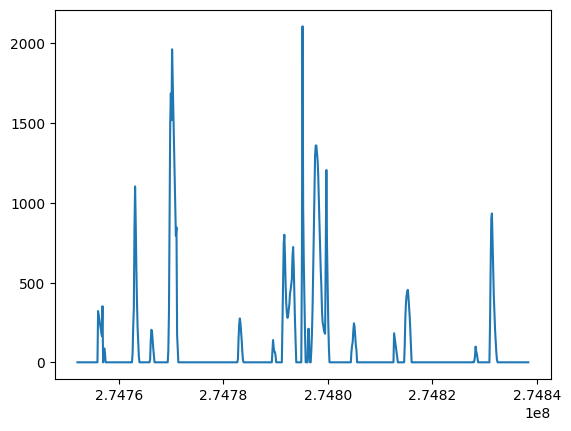

In [3]:
plt.plot(binned_time, subtracted_signal)
plt.show()


--- Step 0: Stitching Data ---
Target file: ch2_xsm_20250916_v1_level2.lc
  > Successfully loaded: ch2_xsm_20250915_v1_level2.lc
  > Successfully loaded: ch2_xsm_20250916_v1_level2.lc
  > Successfully loaded: ch2_xsm_20250917_v1_level2.lc
Stitching complete. Total points: 252395


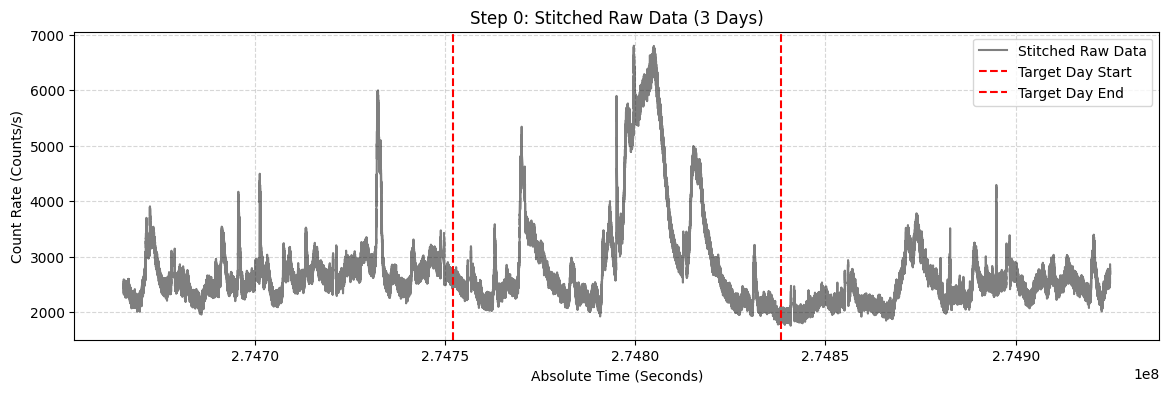


--- Step 1: Denoising (Binning + Gaussian Smooth) ---
Binned to 2112 points and smoothed.


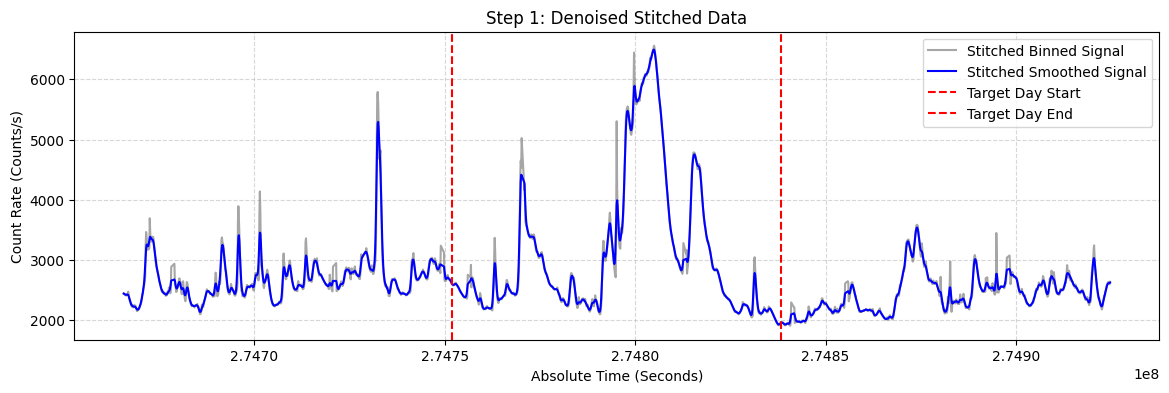


--- Un-stitching complete. Returning 705 points for target day. ---


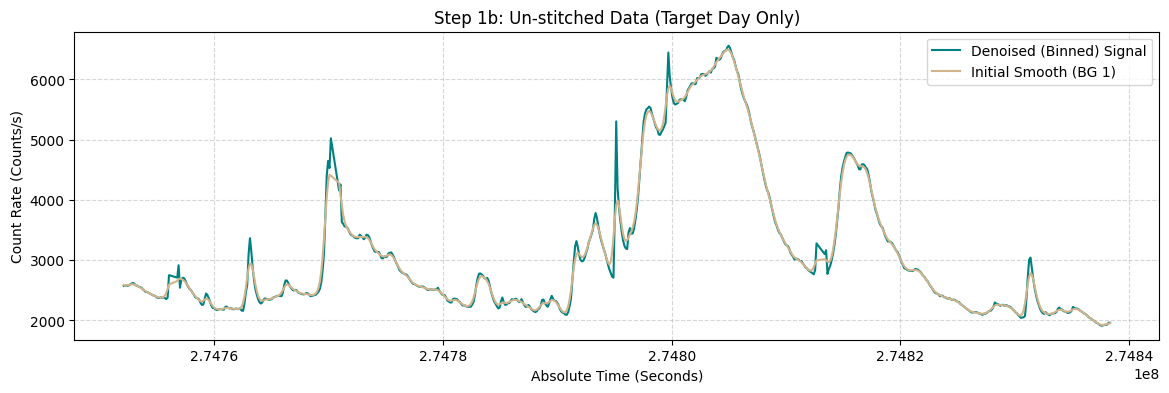


--- Step 2: Finding Initial Peaks (Prominence > 200.0) ---
Found 16 initial peaks.


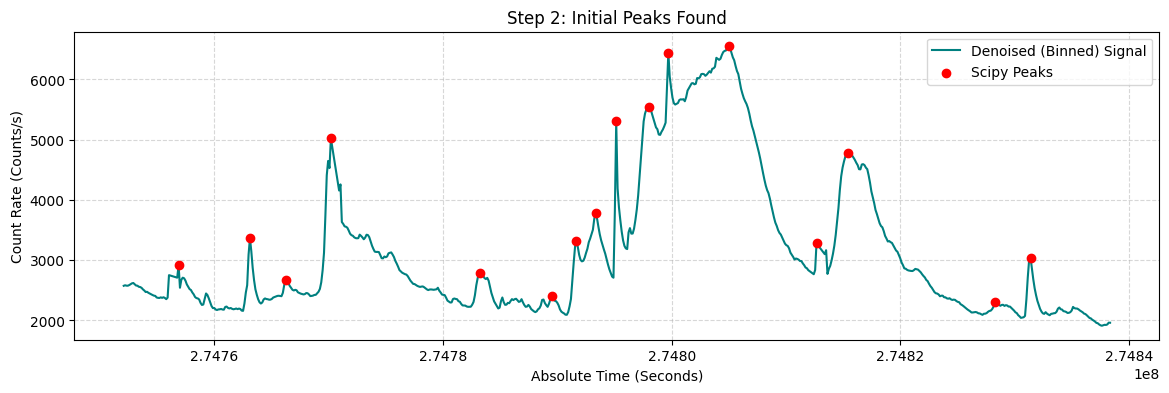


--- Step 3: Finding Flare Durations (Slope Algorithm) ---
Found 16 flare durations.


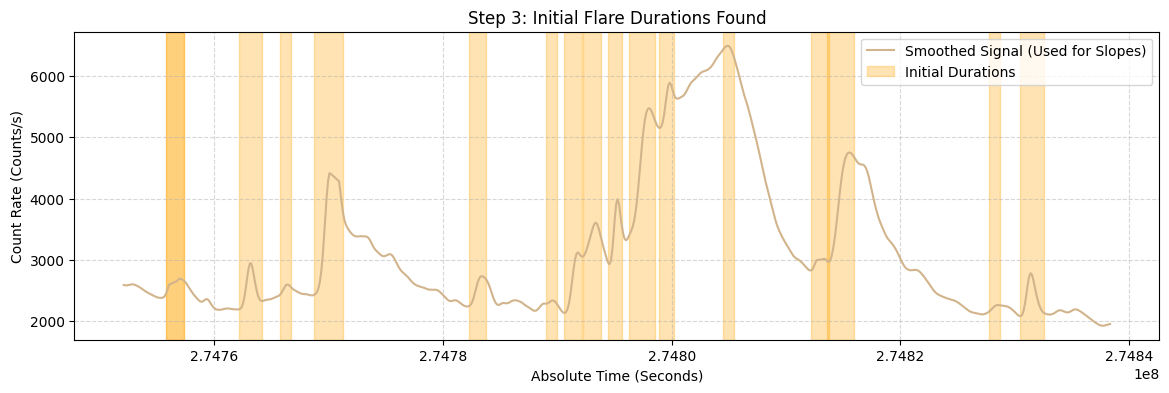


--- Step 4: Merging Flares (Merge Time < 600.0s) ---
Merged into 13 final durations.


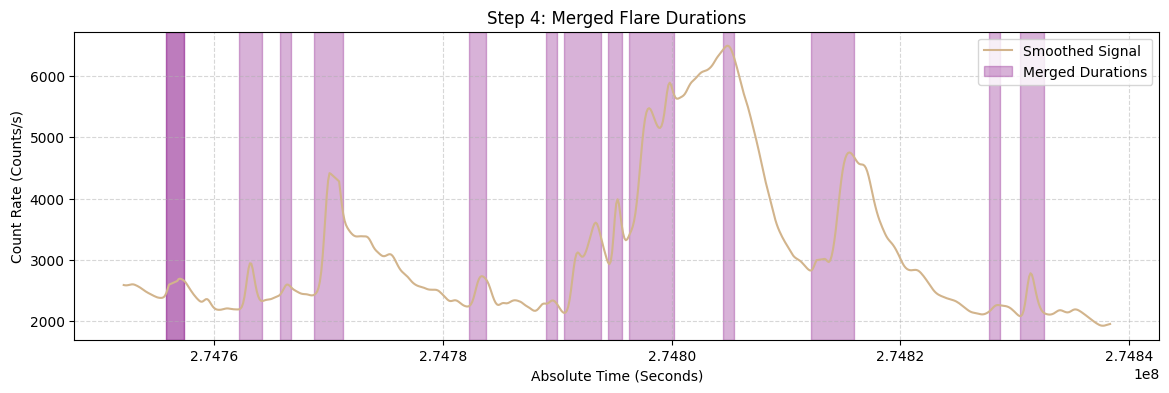


--- Step 5: Estimating Final Background (BG 2) ---
Background estimation complete.


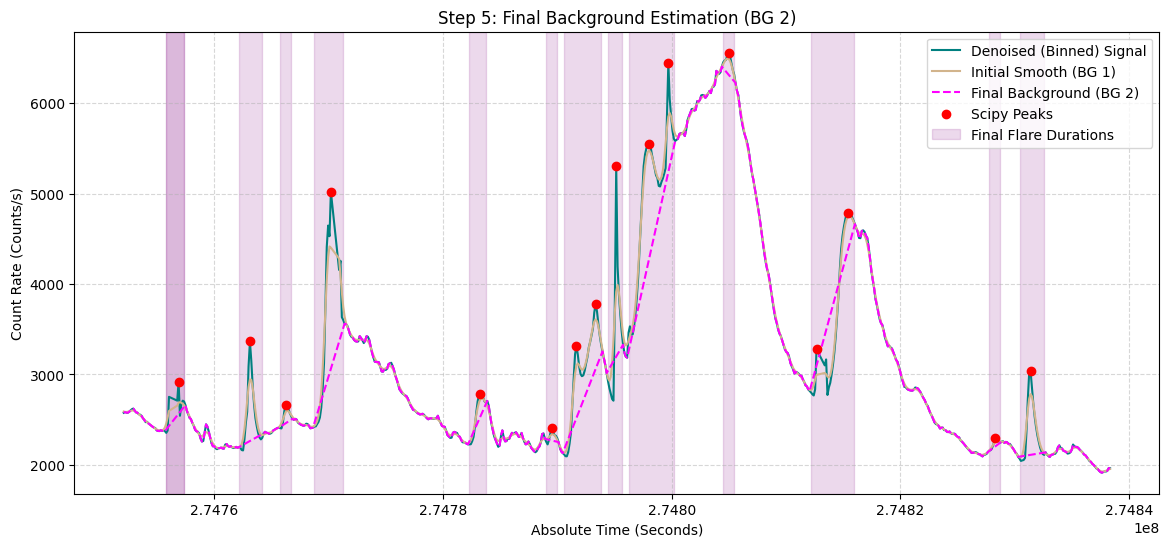

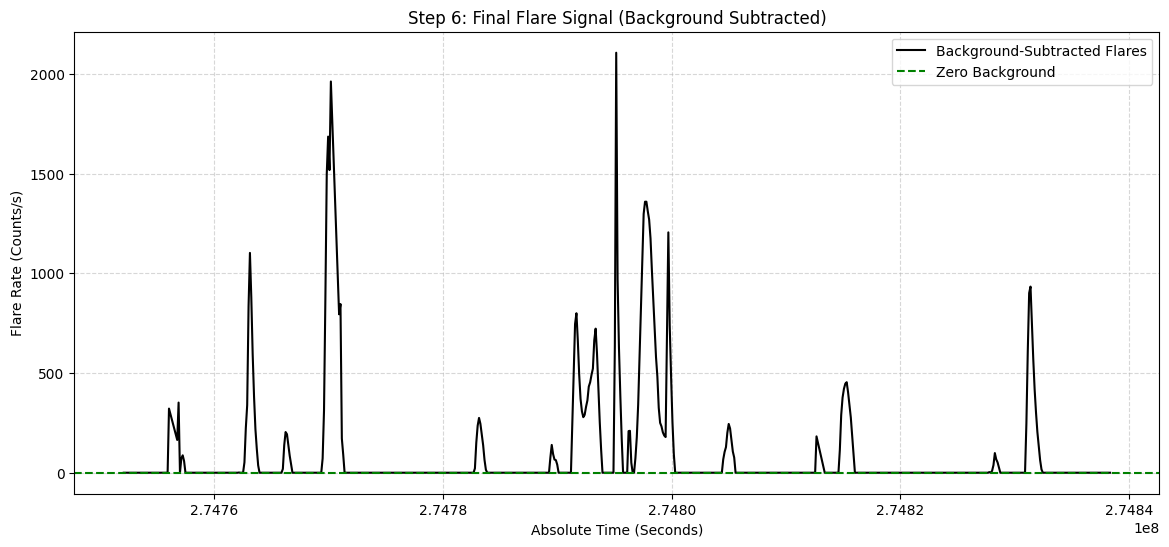

In [11]:
import pandas as pd
import numpy as np
from scipy.stats import binned_statistic
from scipy.ndimage import gaussian_filter1d
from scipy.signal import find_peaks
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt
from astropy.table import Table
import os
from datetime import datetime, timedelta

# --- 1. Define All Algorithm Parameters ---
BIN_SIZE_SECONDS = 120.0
SIGMA_G = 2.0
PEAK_PROMINENCE = 200.0
SLOPE_THRESHOLD = 0.5
MERGE_THRESHOLD_SECONDS = 600.0

# =================================================================
# --- HELPER FUNCTION 1: LOAD A SINGLE .LC FILE ---
# =================================================================
def _load_one_lc_file(lc_file_path):
    if not os.path.exists(lc_file_path):
        print(f"  > File not found, skipping: {os.path.basename(lc_file_path)}")
        return None
    try:
        lc_data = Table.read(lc_file_path)
        time_abs = lc_data['TIME'].value.astype(float)
        rate_lc = lc_data['RATE'].value.astype(float)
        df = pd.DataFrame({'TIME': time_abs, 'RATE': rate_lc})
        print(f"  > Successfully loaded: {os.path.basename(lc_file_path)}")
        return df
    except Exception as e:
        print(f"  > Error loading {os.path.basename(lc_file_path)}: {e}")
        return None

# # =================================================================
# # --- STITCHING FUNCTION ---
# # =================================================================
def load_and_stitch_data(current_file_path):
    print(f"\n--- Step 0: Stitching Data ---")
    print(f"Target file: {os.path.basename(current_file_path)}")
    base_dir = os.path.dirname(current_file_path)
    current_filename = os.path.basename(current_file_path)
    try:
        parts = current_filename.split('_')
        date_str = parts[2]
        date_obj = datetime.strptime(date_str, '%Y%m%d')
        prev_date_obj = date_obj - timedelta(days=1)
        next_date_obj = date_obj + timedelta(days=1)
        prev_date_str = prev_date_obj.strftime('%Y%m%d')
        next_date_str = next_date_obj.strftime('%Y%m%d')
        prev_filename = current_filename.replace(date_str, prev_date_str)
        next_filename = current_filename.replace(date_str, next_date_str)
        prev_file_path = os.path.join(base_dir, prev_filename)
        next_file_path = os.path.join(base_dir, next_filename)
    except Exception as e:
        print(f"Error parsing filename. Error: {e}")
        return None, None
    all_dataframes = []
    df_prev = _load_one_lc_file(prev_file_path)
    if df_prev is not None: all_dataframes.append(df_prev)
    df_current = _load_one_lc_file(current_file_path)
    if df_current is None: return None, None
    all_dataframes.append(df_current)
    df_next = _load_one_lc_file(next_file_path)
    if df_next is not None: all_dataframes.append(df_next)
    stitched_df = pd.concat(all_dataframes, ignore_index=True)
    stitched_df = stitched_df.sort_values(by='TIME').reset_index(drop=True)
    stitch_boundaries = (df_current['TIME'].min(), df_current['TIME'].max())
    print(f"Stitching complete. Total points: {len(stitched_df)}")
    return stitched_df, stitch_boundaries

# # =================================================================
# # --- UN-STITCHING FUNCTION ---
# # =================================================================
def un_stitch_data(stitched_time, stitched_binned_signal, stitched_smoothed_signal, boundaries):
    start_time, end_time = boundaries
    unstitched_mask = (stitched_time >= start_time) & (stitched_time <= end_time)
    final_binned_time = stitched_time[unstitched_mask]
    final_binned_signal = stitched_binned_signal[unstitched_mask]
    final_smoothed_signal = stitched_smoothed_signal[unstitched_mask]
    print(f"\n--- Un-stitching complete. Returning {len(final_binned_time)} points for target day. ---")
    return final_binned_time, final_binned_signal, final_smoothed_signal

# =================================================================
# --- ALGORITHM FUNCTIONS ---
# =================================================================
def denoise_data(dataframe, time_col, rate_col, bin_size_sec, sigma_g):
    print(f"\n--- Step 1: Denoising (Binning + Gaussian Smooth) ---")
    original_time = dataframe[time_col].values
    original_rate = dataframe[rate_col].values
    min_time = original_time.min()
    max_time = original_time.max()
    bin_edges = np.arange(min_time, max_time + bin_size_sec, bin_size_sec)
    binned_rates_signal, _, _ = binned_statistic(original_time, original_rate, statistic='mean', bins=bin_edges)
    binned_time_result = (bin_edges[:-1] + bin_edges[1:]) / 2
    non_nan_mask = ~np.isnan(binned_rates_signal)
    binned_rates_signal = binned_rates_signal[non_nan_mask]
    binned_time_result = binned_time_result[non_nan_mask]
    gaussian_smoothed_curve = gaussian_filter1d(binned_rates_signal, sigma=sigma_g, mode='nearest')
    print(f"Binned to {len(binned_time_result)} points and smoothed.")
    return binned_time_result, binned_rates_signal, gaussian_smoothed_curve

def find_initial_peaks(binned_signal, prominence):
    print(f"\n--- Step 2: Finding Initial Peaks (Prominence > {prominence}) ---")
    peak_indices, _ = find_peaks(binned_signal, prominence=prominence)
    print(f"Found {len(peak_indices)} initial peaks.")
    return peak_indices

def find_flare_durations(time, smoothed_curve, peak_indices, slope_thresh):
    print(f"\n--- Step 3: Finding Flare Durations (Slope Algorithm) ---")
    flare_intervals = []
    for idx in peak_indices:
        start_idx = idx
        for i in range(idx - 4, 0, -1):
            x_slope, y_slope = time[i : i+4], smoothed_curve[i : i+4]
            # Add check for sufficient points
            if len(x_slope) < 4: continue
            slope = np.polyfit(x_slope, y_slope, 1)[0]
            if np.abs(slope) < slope_thresh:
                start_idx = i
                break
        end_idx = idx
        for i in range(idx, len(time) - 4):
            x_slope, y_slope = time[i : i+4], smoothed_curve[i : i+4]
            # Add check for sufficient points
            if len(x_slope) < 4: continue
            slope = np.polyfit(x_slope, y_slope, 1)[0]
            if np.abs(slope) < slope_thresh:
                end_idx = i + 4
                break
        # Ensure start index is less than end index
        if start_idx < end_idx:
             flare_intervals.append([time[start_idx], time[end_idx]])
        else: # Handle cases where walk might fail or cross
             flare_intervals.append([time[idx], time[idx+1] if idx+1 < len(time) else time[idx]]) # default to peak point

    print(f"Found {len(flare_intervals)} flare durations.")
    return flare_intervals

def merge_close_flares(flare_intervals, merge_time_sec):
    print(f"\n--- Step 4: Merging Flares (Merge Time < {merge_time_sec}s) ---")
    if not flare_intervals: return []
    intervals = sorted(flare_intervals, key=lambda x: x[0])
    merged_intervals = [intervals[0]]
    for current_start, current_end in intervals[1:]:
        last_start, last_end = merged_intervals[-1]
        if current_start - last_end < merge_time_sec:
            merged_intervals[-1][1] = max(last_end, current_end)
        else:
            merged_intervals.append([current_start, current_end])
    print(f"Merged into {len(merged_intervals)} final durations.")
    return merged_intervals

def estimate_final_background(time, binned_signal, merged_intervals):
    print(f"\n--- Step 5: Estimating Final Background (BG 2) ---")
    non_flaring_mask = np.ones_like(time, dtype=bool)
    for start_time, end_time in merged_intervals:
        non_flaring_mask[(time >= start_time) & (time <= end_time)] = False
    quiet_time, quiet_rate = time[non_flaring_mask], binned_signal[non_flaring_mask]
    if len(quiet_time) < 2:
        print("Warning: Too few quiet points. Using initial smooth curve.")
        return gaussian_filter1d(binned_signal, sigma=SIGMA_G, mode='nearest')
    background_interpolator = interp1d(quiet_time, quiet_rate, kind='linear', fill_value="extrapolate")
    estimated_background = background_interpolator(time)
    print("Background estimation complete.")
    return estimated_background

# =================================================================
# --- MAIN EXECUTION PIPELINE (WITH INTERMEDIATE PLOTS) ---
# =================================================================

# Define the path to your *target* file
target_lc_file = r'ALL_DATA/ch2_xsm_20250916_v1_level2.lc'

# Step 0: Load and Stitch Data
stitched_df, boundaries = load_and_stitch_data(target_lc_file)

if stitched_df is not None:
    # --- Plot 0: Stitched Raw Data ---
    plt.figure(figsize=(14, 4))
    plt.plot(stitched_df['TIME'], stitched_df['RATE'], color='black', alpha=0.5, label='Stitched Raw Data')
    plt.axvline(boundaries[0], color='red', linestyle='--', label='Target Day Start')
    plt.axvline(boundaries[1], color='red', linestyle='--', label='Target Day End')
    plt.title("Step 0: Stitched Raw Data (3 Days)")
    plt.xlabel("Absolute Time (Seconds)")
    plt.ylabel("Count Rate (Counts/s)")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

    # Step 1: Denoise the *ENTIRE* stitched curve
    stitched_time, stitched_binned, stitched_smoothed = denoise_data(
        stitched_df, 'TIME', 'RATE', BIN_SIZE_SECONDS, SIGMA_G
    )

    # --- Plot 1: Denoised Stitched Data ---
    plt.figure(figsize=(14, 4))
    plt.plot(stitched_time, stitched_binned, color='gray', alpha=0.7, label='Stitched Binned Signal')
    plt.plot(stitched_time, stitched_smoothed, color='blue', label='Stitched Smoothed Signal')
    plt.axvline(boundaries[0], color='red', linestyle='--', label='Target Day Start')
    plt.axvline(boundaries[1], color='red', linestyle='--', label='Target Day End')
    plt.title("Step 1: Denoised Stitched Data")
    plt.xlabel("Absolute Time (Seconds)")
    plt.ylabel("Count Rate (Counts/s)")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

    # --- Step 1b: Un-stitch the data ---
    binned_time, binned_signal, smoothed_signal = un_stitch_data(
        stitched_time, stitched_binned, stitched_smoothed, boundaries
    )

    # --- Plot 1b: Un-stitched Denoised Data ---
    plt.figure(figsize=(14, 4))
    plt.plot(binned_time, binned_signal, color='teal', label='Denoised (Binned) Signal')
    plt.plot(binned_time, smoothed_signal, color='tan', label='Initial Smooth (BG 1)')
    plt.title("Step 1b: Un-stitched Data (Target Day Only)")
    plt.xlabel("Absolute Time (Seconds)")
    plt.ylabel("Count Rate (Counts/s)")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

    # Step 2: Find Peaks
    peak_indices = find_initial_peaks(binned_signal, PEAK_PROMINENCE)

    # --- Plot 2: Initial Peaks ---
    plt.figure(figsize=(14, 4))
    plt.plot(binned_time, binned_signal, color='teal', label='Denoised (Binned) Signal')
    plt.scatter(binned_time[peak_indices], binned_signal[peak_indices], color='red', zorder=5, label='Scipy Peaks')
    plt.title("Step 2: Initial Peaks Found")
    plt.xlabel("Absolute Time (Seconds)")
    plt.ylabel("Count Rate (Counts/s)")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

    # Step 3: Find Durations (using the smoothed curve)
    flare_intervals = find_flare_durations(
        binned_time, smoothed_signal, peak_indices, SLOPE_THRESHOLD
    )

    # --- Plot 3: Flare Durations ---
    plt.figure(figsize=(14, 4))
    plt.plot(binned_time, smoothed_signal, color='tan', label='Smoothed Signal (Used for Slopes)')
    for start, end in flare_intervals:
        plt.axvspan(start, end, color='orange', alpha=0.3, label='_nolegend_') # Use _nolegend_ to avoid repeating label
    # Add one label entry for the shaded regions
    if flare_intervals:
        plt.axvspan(flare_intervals[0][0], flare_intervals[0][1], color='orange', alpha=0.3, label='Initial Durations')
    plt.title("Step 3: Initial Flare Durations Found")
    plt.xlabel("Absolute Time (Seconds)")
    plt.ylabel("Count Rate (Counts/s)")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

    # Step 4: Merge Flares
    merged_flare_intervals = merge_close_flares(flare_intervals, MERGE_THRESHOLD_SECONDS)

    # --- Plot 4: Merged Flare Durations ---
    plt.figure(figsize=(14, 4))
    plt.plot(binned_time, smoothed_signal, color='tan', label='Smoothed Signal')
    for start, end in merged_flare_intervals:
        plt.axvspan(start, end, color='purple', alpha=0.3, label='_nolegend_')
    if merged_flare_intervals:
        plt.axvspan(merged_flare_intervals[0][0], merged_flare_intervals[0][1], color='purple', alpha=0.3, label='Merged Durations')
    plt.title("Step 4: Merged Flare Durations")
    plt.xlabel("Absolute Time (Seconds)")
    plt.ylabel("Count Rate (Counts/s)")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

    # Step 5: Estimate Final Background (BG 2)
    final_background = estimate_final_background(binned_time, binned_signal, merged_flare_intervals)

    # --- Plot 5: Final Background Estimate ---
    # This is the same as the Diagnostic Plot already generated
    plt.figure(figsize=(14, 6))
    plt.plot(binned_time, binned_signal, color='teal', label='Denoised (Binned) Signal')
    plt.plot(binned_time, smoothed_signal, color='tan', label='Initial Smooth (BG 1)')
    plt.plot(binned_time, final_background, color='magenta', linestyle='--', label='Final Background (BG 2)')
    plt.scatter(binned_time[peak_indices], binned_signal[peak_indices], color='red', zorder=5, label='Scipy Peaks')
    # Shade the final merged flare regions
    for start, end in merged_flare_intervals:
        plt.axvspan(start, end, color='purple', alpha=0.15, label='_nolegend_')
    if merged_flare_intervals:
         plt.axvspan(merged_flare_intervals[0][0], merged_flare_intervals[0][1], color='purple', alpha=0.15, label='Final Flare Durations')
    plt.title("Step 5: Final Background Estimation (BG 2)")
    plt.xlabel("Absolute Time (Seconds)")
    plt.ylabel("Count Rate (Counts/s)")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

    # --- Step 6: Subtract Final Background ---
    subtracted_signal = binned_signal - final_background
    subtracted_signal = np.maximum(0, subtracted_signal)

    # --- Plot 6: Final Result ---
    # This is the same as the Final Result Plot already generated
    plt.figure(figsize=(14, 6))
    plt.plot(binned_time, subtracted_signal, color='black', label='Background-Subtracted Flares')
    plt.axhline(0, color='green', linestyle='--', label='Zero Background')
    plt.title("Step 6: Final Flare Signal (Background Subtracted)")
    plt.xlabel("Absolute Time (Seconds)")
    plt.ylabel("Flare Rate (Counts/s)")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

else:
    print("Processing stopped because the DataFrame could not be loaded.")


--- Step 0: Stitching Data ---
Target file: ch2_xsm_20250916_v1_level2.lc
  > Successfully loaded: ch2_xsm_20250915_v1_level2.lc
  > Successfully loaded: ch2_xsm_20250916_v1_level2.lc
  > Successfully loaded: ch2_xsm_20250917_v1_level2.lc
Stitching complete. Total points: 252395

--- Step 1: Denoising (Binning + Gaussian Smooth) ---
Binned to 2112 points and smoothed.

--- Un-stitching complete. Returning 705 points for target day. ---

--- Step 2: Finding Initial Peaks (Prominence > 200.0) ---
Found 16 initial peaks.

--- Step 3: Finding Flare Durations (Slope Algorithm) ---
Found 16 flare durations.

--- Step 4: Merging Flares (Merge Time < 600.0s) ---
Merged into 13 final durations.

--- Step 5: Estimating Final Background (BG 2) ---
Background estimation complete.

Applied noise clip threshold: 84.44

--- Step 7: Starting EFP Modeling and Characterization ---
--- Found 21 peaks for final fitting ---


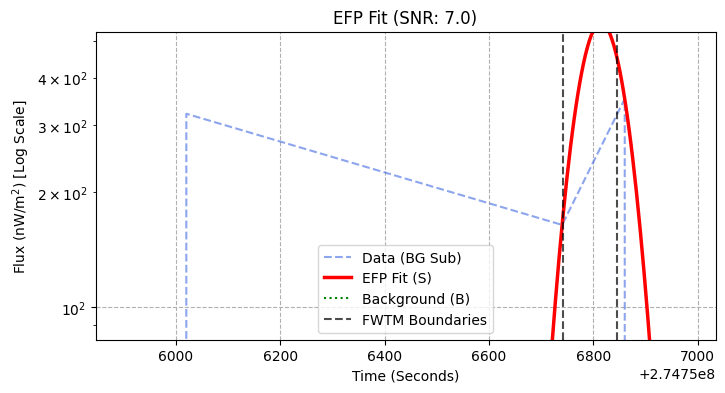

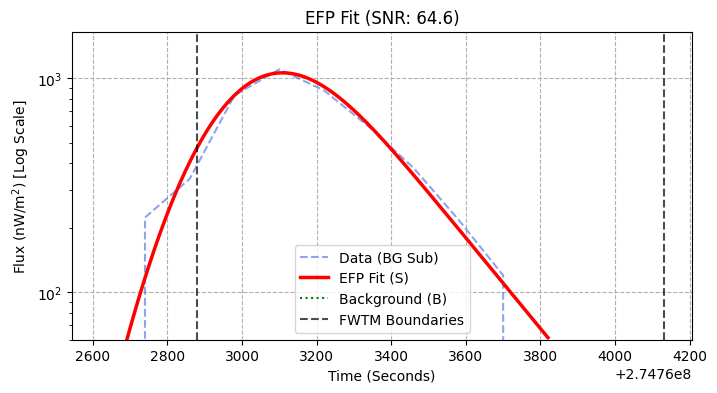

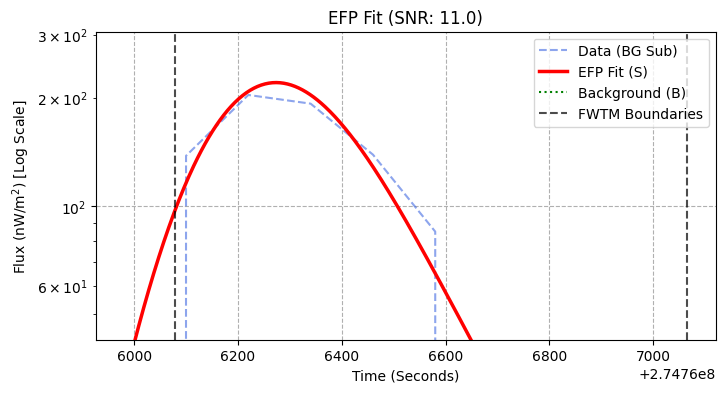

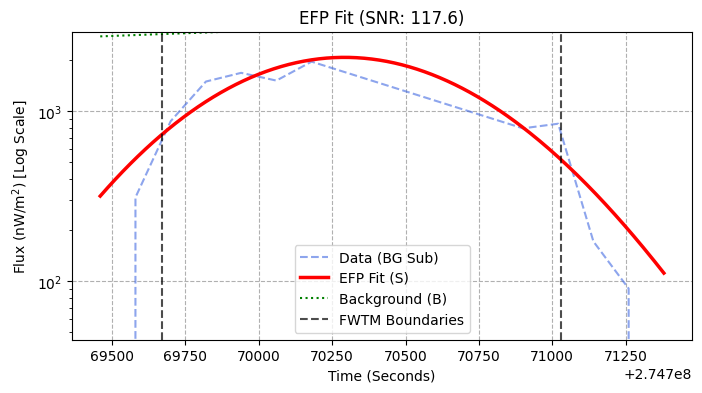

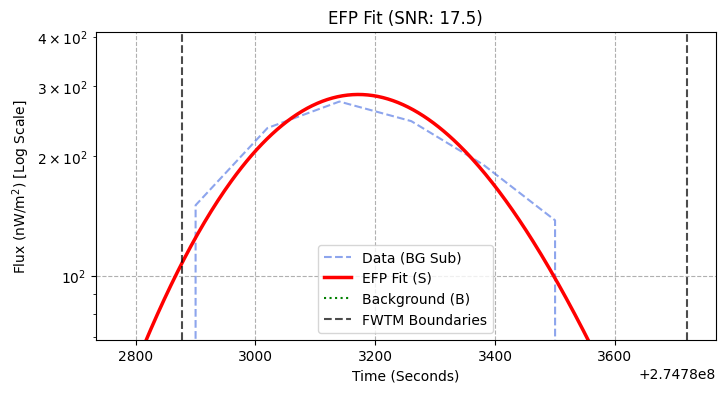

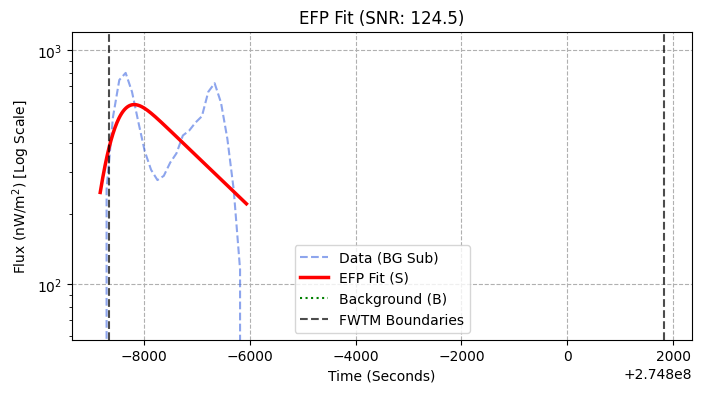

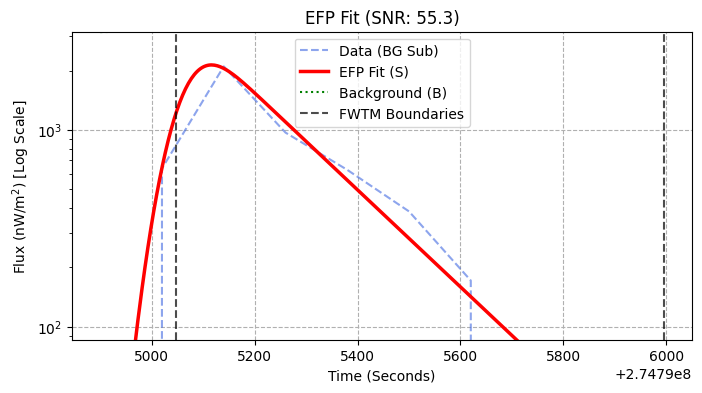

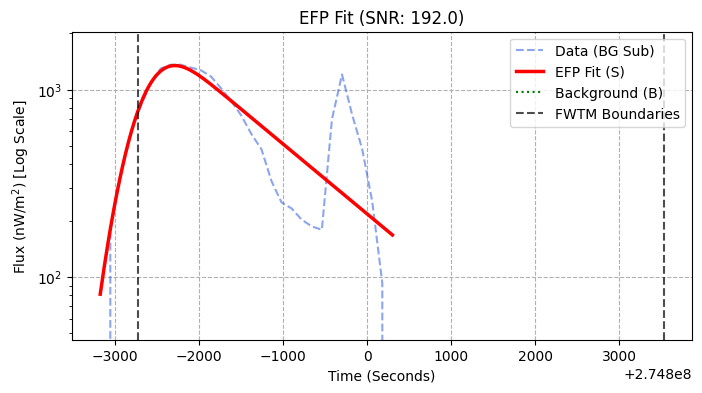

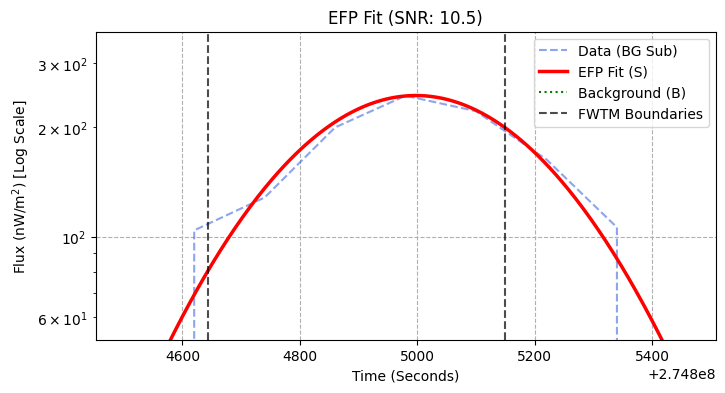

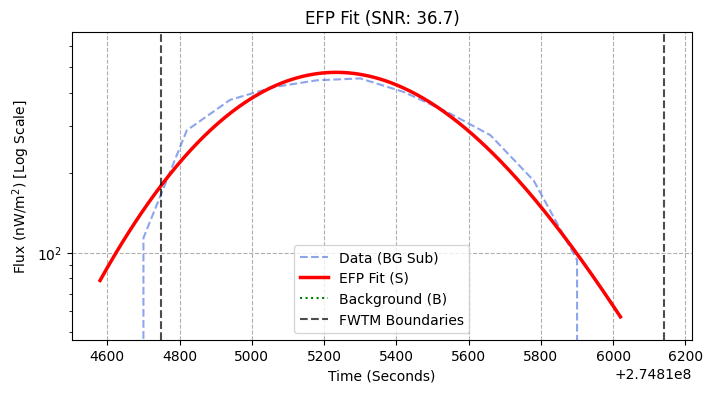

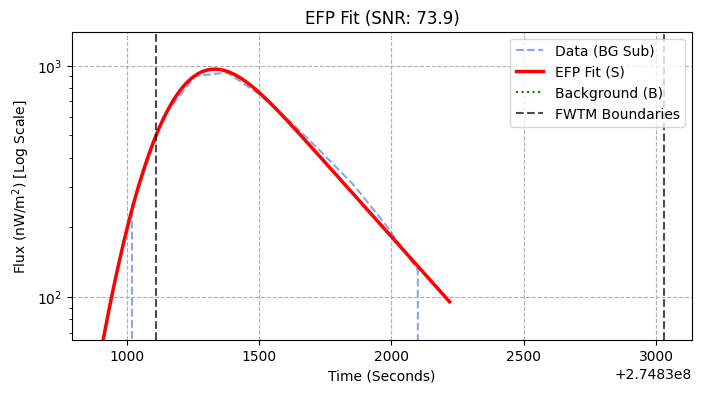

EFP modeling complete. Successfully fitted 11 flares.

--- FINAL FLARE CATALOG (EFP FITTED w/ Correct SNR) ---
        PeakTime  PeakFlux_nW/m2     StartFWTM       EndFWTM  FittedSNR  \
0   2.747568e+08          556.27  2.747567e+08  2.747568e+08       7.03   
1   2.747631e+08         1061.76  2.747629e+08  2.747641e+08      64.60   
2   2.747663e+08          220.85  2.747661e+08  2.747671e+08      11.01   
3   2.747703e+08         2078.33  2.747697e+08  2.747710e+08     117.62   
4   2.747832e+08          286.32  2.747829e+08  2.747837e+08      17.53   
5   2.747918e+08          585.36  2.747913e+08  2.748018e+08     124.46   
6   2.747951e+08         2140.53  2.747950e+08  2.747960e+08      55.30   
7   2.747977e+08         1344.48  2.747973e+08  2.748035e+08     191.98   
8   2.748050e+08          244.85  2.748046e+08  2.748051e+08      10.51   
9   2.748152e+08          478.44  2.748147e+08  2.748161e+08      36.66   
10  2.748313e+08          964.55  2.748311e+08  2.748330e+08    

In [5]:
import pandas as pd
import numpy as np
from scipy.stats import binned_statistic
from scipy.ndimage import gaussian_filter1d
from scipy.signal import find_peaks
from scipy.interpolate import interp1d
from scipy.optimize import curve_fit # For EFP fit
from scipy.special import erfc      # For EFP function
import matplotlib.pyplot as plt
from astropy.table import Table
import os
from datetime import datetime, timedelta

# --- 1. Define All Algorithm Parameters ---
BIN_SIZE_SECONDS = 120.0
SIGMA_G = 2.0
PEAK_PROMINENCE = 200.0  # Initial peak finding
SLOPE_THRESHOLD = 0.5
MERGE_THRESHOLD_SECONDS = 600.0
N_SIGMA_CLIP = 0.3       # Final noise clipping level

# --- EFP Fitting Parameters ---
FINAL_PEAK_PROMINENCE = 50.0 # Prominence for peaks on final signal
FINAL_PEAK_HEIGHT = 1.0      # Height for peaks on final signal

# --- Calibration Factor ---
COUNT_TO_NW_M2_FACTOR = 1.0 # Assumes 1 count/s ≈ 1 nW/m²

# --- Define Consistent Y-axis Labels ---
Y_LABEL_RATE = "Count Rate (Counts/s)"
Y_LABEL_FLUX = r"Flux (nW/m$^2$)"

# =================================================================
# --- EFP MODEL FUNCTIONS (Stable versions) ---
# =================================================================
MAX_EXP_ARG_CLIP = 50.0
def elementary_flare_profile(t, A, mu, sigma, tau):
    """Numerically stable Elementary Flare Profile (EFP) core function (4-param)."""
    sigma = np.abs(sigma); tau = np.abs(tau)
    if sigma < 1e-4: sigma = 1e-4
    if tau < 1e-4: tau = 1e-4
    if tau < 1e-3:
        A_prime = A * sigma * np.sqrt(np.pi / 2.0)
        exp_arg_gauss = -0.5 * ((t - mu) / sigma)**2
        exp_arg_gauss = np.clip(exp_arg_gauss, a_min=-np.inf, a_max=MAX_EXP_ARG_CLIP)
        return A_prime * np.exp(exp_arg_gauss)

    A_prime = A * (sigma / tau) * np.sqrt(np.pi / 2.0)
    exp_arg = 0.5 * (sigma / tau)**2 - (t - mu) / tau
    exp_arg = np.clip(exp_arg, a_min=-np.inf, a_max=MAX_EXP_ARG_CLIP)
    exp_part = np.exp(exp_arg); erfc_arg = (1.0 / np.sqrt(2.0)) * (sigma / tau - (t - mu) / sigma)
    erfc_part = erfc(erfc_arg)
    result = A_prime * exp_part * erfc_part
    return np.nan_to_num(result)

def get_fitted_parameters(t, rate, p_opt, background_segment):
    """
    Calculates Peak Time, FWTM, Peak Flux, and CORRECT SNR from fit.
    """
    A, mu, sigma, tau = p_opt[0:4]
    if any(np.isnan(p_opt)) or sigma <= 0 or tau <= 0: return None

    S_fitted = elementary_flare_profile(t, A, mu, sigma, tau)
    B_background = np.maximum(0, background_segment)
    S_fitted_nonneg = np.maximum(0, S_fitted)
    denominator_term = S_fitted_nonneg + 2 * B_background
    denominator_term[denominator_term < 1e-9] = 1e-9
    snr_terms = S_fitted_nonneg / np.sqrt(denominator_term)
    fitted_snr = np.sum(snr_terms)

    t_dense = np.linspace(t.min(), t.max(), 500)
    fitted_curve_dense = elementary_flare_profile(t_dense, A, mu, sigma, tau)
    if np.all(np.isnan(fitted_curve_dense)) or len(fitted_curve_dense) == 0: return None
    peak_index = np.nanargmax(fitted_curve_dense)
    peak_time = t_dense[peak_index]
    peak_flux_counts = fitted_curve_dense[peak_index]
    peak_flux_nw = peak_flux_counts * COUNT_TO_NW_M2_FACTOR

    # Simplified FWTM logic (placeholder)
    start_time_fwtm = peak_time - 1.5 * np.abs(sigma)
    end_time_fwtm = peak_time + 5.0 * np.abs(tau)

    return {
        'PeakTime': peak_time, 'PeakFlux_nW/m2': peak_flux_nw,
        'StartFWTM': start_time_fwtm, 'EndFWTM': end_time_fwtm,
        'FittedSNR': fitted_snr, 'DecayTau': np.abs(tau),
        'RiseSigma': np.abs(sigma), 'Fitted_A': A
    }

# =================================================================
# --- FLARE MODELING FUNCTION (STEP 7 - Requires Background Array) ---
# =================================================================
def model_and_characterize_flares(time_array, subtracted_signal_array, final_background_array,
                                prominence=50.0, height=1.0):
    """
    Fits EFP model and calculates parameters including the correct SNR.
    Requires the estimated background array.
    """
    print(f"\n--- Step 7: Starting EFP Modeling and Characterization ---")
    peak_indices, _ = find_peaks(subtracted_signal_array, prominence=prominence, height=height)
    print(f"--- Found {len(peak_indices)} peaks for final fitting ---")
    if len(peak_indices) == 0: return pd.DataFrame()

    final_catalog_data = []
    processed_indices = np.zeros_like(subtracted_signal_array, dtype=bool)

    for peak_idx in peak_indices:
        if processed_indices[peak_idx]: continue
        start_idx = peak_idx; end_idx = peak_idx
        # Walk left/right to isolate flare segment
        for i in range(peak_idx - 1, -1, -1):
            if subtracted_signal_array[i] <= 0 or i == 0: start_idx = i; break
        for i in range(peak_idx + 1, len(subtracted_signal_array)):
            if subtracted_signal_array[i] <= 0 or i == len(subtracted_signal_array) - 1: end_idx = i; break

        if start_idx >= end_idx: continue
        segment_mask = np.arange(start_idx, end_idx + 1)
        segment_mask = segment_mask[(segment_mask >= 0) & (segment_mask < len(time_array))]
        if len(segment_mask) < 5: continue

        t_flare = time_array[segment_mask]
        r_flare = subtracted_signal_array[segment_mask] # This is S
        # Get corresponding background segment B
        if max(segment_mask) < len(final_background_array):
             background_flare = final_background_array[segment_mask]
        else:
             print(f"Warning: Background index out of bounds for peak {peak_idx}. Skipping.")
             continue

        if len(t_flare) < 5: continue
        r_peak_time_guess = t_flare[np.argmax(r_flare)]; r_peak_flux_guess = r_flare.max()
        if r_peak_flux_guess <= 0: continue

        p0 = [r_peak_flux_guess, r_peak_time_guess, 50.0, 200.0]
        lower_bounds = [0.0, t_flare.min(), 1.0, 5.0]
        upper_bounds = [r_peak_flux_guess * 2.5, t_flare.max(), 1000.0, 2000.0]

        try:
            p_opt, p_cov = curve_fit(
                elementary_flare_profile, t_flare, r_flare, p0=p0,
                bounds=(lower_bounds, upper_bounds), maxfev=5000
            )
            # Pass background segment for correct SNR
            flare_props = get_fitted_parameters(t_flare, r_flare, p_opt, background_flare)

            if flare_props and not np.isnan(flare_props['PeakTime']):
                final_catalog_data.append(flare_props)
                processed_indices[segment_mask] = True

                # --- Visualization (Optional: Plot each fit) ---
                t_fit = np.linspace(t_flare.min(), t_flare.max(), 300)
                r_fit = elementary_flare_profile(t_fit, *p_opt)
                plt.figure(figsize=(8, 4))
                plt.plot(t_flare, r_flare, '--', color='royalblue', alpha=0.6, label='Data (BG Sub)')
                plt.plot(t_fit, r_fit, color='red', lw=2.5, label='EFP Fit (S)')
                plt.plot(t_flare, background_flare, color='green', ls=':', label='Background (B)')
                plt.axvline(flare_props['StartFWTM'], color='k', ls='--', alpha=0.7)
                plt.axvline(flare_props['EndFWTM'], color='k', ls='--', alpha=0.7, label='FWTM Boundaries')
                plt.title(f"EFP Fit (SNR: {flare_props.get('FittedSNR', np.nan):.1f})")
                plt.xlabel("Time (Seconds)"); plt.ylabel(Y_LABEL_FLUX + " [Log Scale]")
                plt.yscale('log');
                min_plot_val = max(1.0, np.min(r_flare[r_flare > 0]) * 0.5 if np.any(r_flare > 0) else 1.0)
                max_plot_val = max(10.0, np.max(r_flare) * 1.5 if np.any(r_flare > 0) else 10.0)
                plt.ylim(bottom=min_plot_val, top=max_plot_val)
                plt.legend(); plt.grid(True, ls='--'); plt.show()

        except Exception as e:
            # print(f"Fit failed for peak near {r_peak_time_guess:.1f}: {e}")
            pass

    print(f"EFP modeling complete. Successfully fitted {len(final_catalog_data)} flares.")
    return pd.DataFrame(final_catalog_data)

# =================================================================
# --- HELPER & ALGORITHM FUNCTIONS (Steps 0-5) ---
# --- These remain unchanged and are assumed defined above ---
# def _load_one_lc_file(lc_file_path): /* ... */
# def load_and_stitch_data(current_file_path): /* ... */
# def un_stitch_data(stitched_time, stitched_binned_signal, stitched_smoothed_signal, boundaries): /* ... */
# def denoise_data(dataframe, time_col, rate_col, bin_size_sec, sigma_g): /* ... */
# def find_initial_peaks(binned_signal, prominence): /* ... */
# def find_flare_durations(time, smoothed_curve, peak_indices, slope_thresh): /* ... */
# def merge_close_flares(flare_intervals, merge_time_sec): /* ... */
# def estimate_final_background(time, binned_signal, merged_intervals): /* ... */
# =================================================================

# =================================================================
# --- MAIN EXECUTION PIPELINE (Full Process including EFP Fit) ---
# =================================================================

# Define the path to your *target* file
target_lc_file = r'ALL_DATA/ch2_xsm_20250916_v1_level2.lc'

# Step 0: Load and Stitch Data
stitched_df, boundaries = load_and_stitch_data(target_lc_file)

if stitched_df is not None:
    # --- Steps 1-5: Background Estimation Pipeline ---
    stitched_time, stitched_binned, stitched_smoothed = denoise_data(
        stitched_df, 'TIME', 'RATE', BIN_SIZE_SECONDS, SIGMA_G
    )
    if stitched_time is None: exit()

    binned_time, binned_signal, smoothed_signal = un_stitch_data(
        stitched_time, stitched_binned, stitched_smoothed, boundaries
    )
    if binned_time is None or len(binned_time) == 0: exit()

    peak_indices = find_initial_peaks(binned_signal, PEAK_PROMINENCE)
    flare_intervals = find_flare_durations(
        binned_time, smoothed_signal, peak_indices, SLOPE_THRESHOLD
    )
    merged_flare_intervals = merge_close_flares(flare_intervals, MERGE_THRESHOLD_SECONDS)
    final_background = estimate_final_background(binned_time, binned_signal, merged_flare_intervals)

    # --- Step 6: Subtract Background and Final Clip ---
    subtracted_signal = binned_signal - final_background
    subtracted_signal = np.maximum(0, subtracted_signal)

    # --- Step 6b: Final Noise Clipping ---
    non_zero_signal = subtracted_signal[subtracted_signal > 1e-6]
    if len(non_zero_signal) > 10:
        mad = np.median(np.abs(non_zero_signal - np.median(non_zero_signal)))
        sigma_est = mad * 1.4826
        noise_threshold = N_SIGMA_CLIP * sigma_est
        final_clipped_signal = np.where(subtracted_signal >= noise_threshold, subtracted_signal, 0)
        print(f"\nApplied noise clip threshold: {noise_threshold:.2f}")
    else:
        final_clipped_signal = subtracted_signal
        print("\nSkipped noise clip (too few points).")


    # --- Plot Intermediate Steps (Optional) ---
    # (Plots 0-6b can be added back here if needed for diagnostics)

    # --- Step 7: Model and Characterize Flares ---
    final_flare_catalog = model_and_characterize_flares(
        time_array=binned_time,
        subtracted_signal_array=final_clipped_signal, # Use the clipped signal
        final_background_array=final_background,      # Pass the background for SNR
        prominence=FINAL_PEAK_PROMINENCE,
        height=FINAL_PEAK_HEIGHT
    )

    # --- Step 8: Calculate Flare Class (Optional) ---
    # (Define get_goes_class function if needed)
    # if not final_flare_catalog.empty:
    #     final_flare_catalog['GOES_Class'] = final_flare_catalog['PeakFlux_nW/m2'].apply(get_goes_class)


    # --- FINAL OUTPUT ---
    if not final_flare_catalog.empty:
        print("\n" + "="*50)
        print("--- FINAL FLARE CATALOG (EFP FITTED w/ Correct SNR) ---")
        print("="*50)
        # Display selected columns, rounded for clarity
        display_cols = ['PeakTime', 'PeakFlux_nW/m2', 'StartFWTM', 'EndFWTM', 'FittedSNR', 'DecayTau', 'RiseSigma']
        print(final_flare_catalog[display_cols].round(2))
    else:
        print("\nNo flares were successfully modeled.")

else:
    print("Processing stopped because the DataFrame could not be loaded.")

# --- Ensure placeholder definitions are REMOVED if running this as a full script ---
# def _load_one_lc_file(lc_file_path): return None # REMOVE if running full script
# def load_and_stitch_data(current_file_path): return None, None # REMOVE
# def un_stitch_data(stitched_time, stitched_binned_signal, stitched_smoothed_signal, boundaries): return None, None, None # REMOVE
# def denoise_data(dataframe, time_col, rate_col, bin_size_sec, sigma_g): return None, None, None # REMOVE
# def find_initial_peaks(binned_signal, prominence): return [] # REMOVE
# def find_flare_durations(time, smoothed_curve, peak_indices, slope_thresh): return [] # REMOVE
# def merge_close_flares(flare_intervals, merge_time_sec): return [] # REMOVE
# def estimate_final_background(time, binned_signal, merged_intervals): return None # REMOVE


--- Generating Final Plot with EFP Peak Markers ---


C:\Users\sidharth\AppData\Local\Temp\ipykernel_25760\3033361317.py:62: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  plt.ylim(bottom=-50, top=max_flux * 1.1 if max_flux > 0 else 1000)


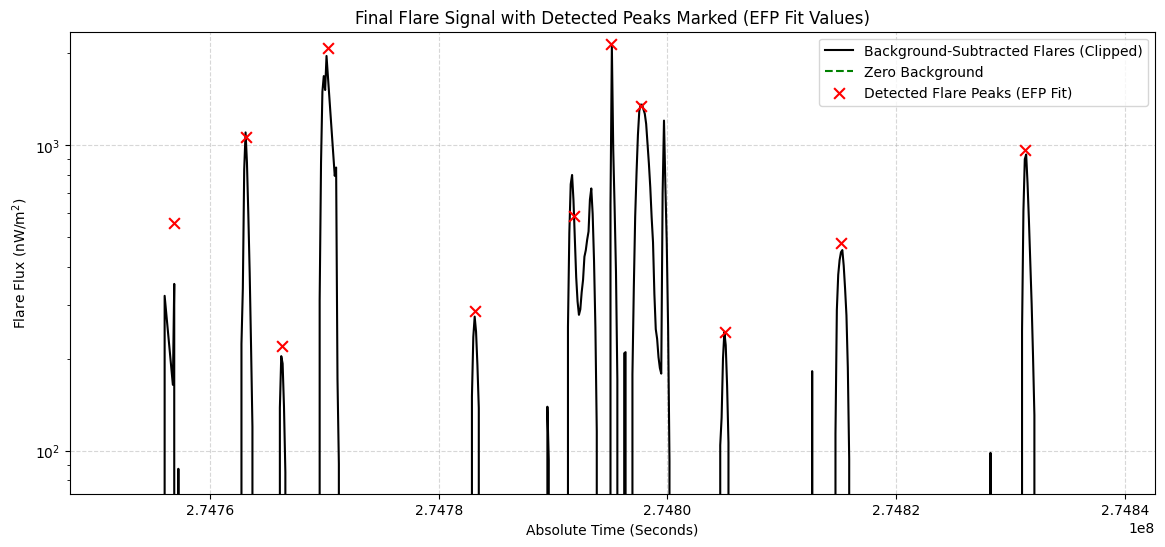

In [16]:
import pandas as pd
import numpy as np
import io
import matplotlib.pyplot as plt

# --- 1. Parse the Final EFP Catalog Data ---
# This is the table of 11 peaks you provided
data_string = """
Index PeakTime PeakFlux_nW/m2 StartFWTM EndFWTM FittedSNR DecayTau RiseSigma Fitted_A
0 2.747568e+08 556.27 2.747567e+08 2.747568e+08 7.03 6.26 47.21 310.93
1 2.747631e+08 1061.76 2.747629e+08 2.747641e+08 64.60 204.53 151.93 918.66
2 2.747663e+08 220.85 2.747661e+08 2.747671e+08 11.01 158.57 130.02 1620.72
3 2.747703e+08 2078.33 2.747697e+08 2.747710e+08 117.62 147.49 414.35 978.79
4 2.747832e+08 286.32 2.747829e+08 2.747837e+08 17.53 109.72 196.49 394.35
5 2.747918e+08 585.36 2.747913e+08 2.748018e+08 124.46 2000.00 322.84 556.27
6 2.747951e+08 2140.53 2.747950e+08 2.747960e+08 55.30 161.19 54.90 4211.08
7 2.747977e+08 1344.48 2.747973e+08 2.748035e+08 191.98 1165.60 288.16 2717.39
8 2.748050e+08 244.85 2.748046e+08 2.748051e+08 10.51 30.28 235.99 235.37
9 2.748152e+08 478.44 2.748147e+08 2.748161e+08 36.66 181.52 322.49 534.00
10 2.748313e+08 964.55 2.748311e+08 2.748330e+08 73.94 339.15 149.12 1715.56
"""

# Parse the catalog data
df_final_catalog = pd.read_csv(io.StringIO(data_string), sep='\s+')
if 'Index' in df_final_catalog.columns:
    df_final_catalog = df_final_catalog.drop(columns=['Index'])

# --- 2. Check if your data arrays exist ---
# This code assumes 'binned_time' and 'final_clipped_signal'
# are already in memory from running your pipeline.

if ('binned_time' in locals() and
    'final_clipped_signal' in locals() and
    isinstance(binned_time, np.ndarray) and
    isinstance(final_clipped_signal, np.ndarray) and
    binned_time.shape == final_clipped_signal.shape):

    print("\n--- Generating Final Plot with EFP Peak Markers ---")
    plt.figure(figsize=(14, 6))

    # Plot 1: The Final Clipped Signal (Black Curve)
    plt.plot(binned_time, final_clipped_signal, color='black', label='Background-Subtracted Flares (Clipped)')

    # Plot 2: Zero Background Line (Green Dashed)
    plt.axhline(0, color='green', linestyle='--', label='Zero Background')

    # Plot 3: Detected Flare Peaks from EFP Fit (Red 'x')
    # This plots the 11 peaks from your table
    plt.scatter(df_final_catalog['PeakTime'], df_final_catalog['PeakFlux_nW/m2'],
                color='red', marker='x', s=60, zorder=10, label='Detected Flare Peaks (EFP Fit)')

    # --- Formatting ---
    plt.title("Final Flare Signal with Detected Peaks Marked (EFP Fit Values)")
    plt.xlabel("Absolute Time (Seconds)")
    plt.ylabel(r"Flare Flux (nW/m$^2$)") # Linear Scale
    plt.legend()
    plt.yscale('log')
    plt.grid(True, linestyle='--', alpha=0.5)
    
    # Set Y limit to start slightly below zero
    max_flux = df_final_catalog['PeakFlux_nW/m2'].max()
    plt.ylim(bottom=-50, top=max_flux * 1.1 if max_flux > 0 else 1000)

    plt.show()

else:
    print("\nError: Could not generate final plot.")
    print("Required variables ('binned_time', 'final_clipped_signal') not found or have mismatched shapes.")
    print("Please ensure the full background subtraction pipeline has run successfully.")

Shape of binned_time: (705,)
Shape of final_clipped_signal: (705,)

--- Generating Final Plot with EFP Peak Markers ---


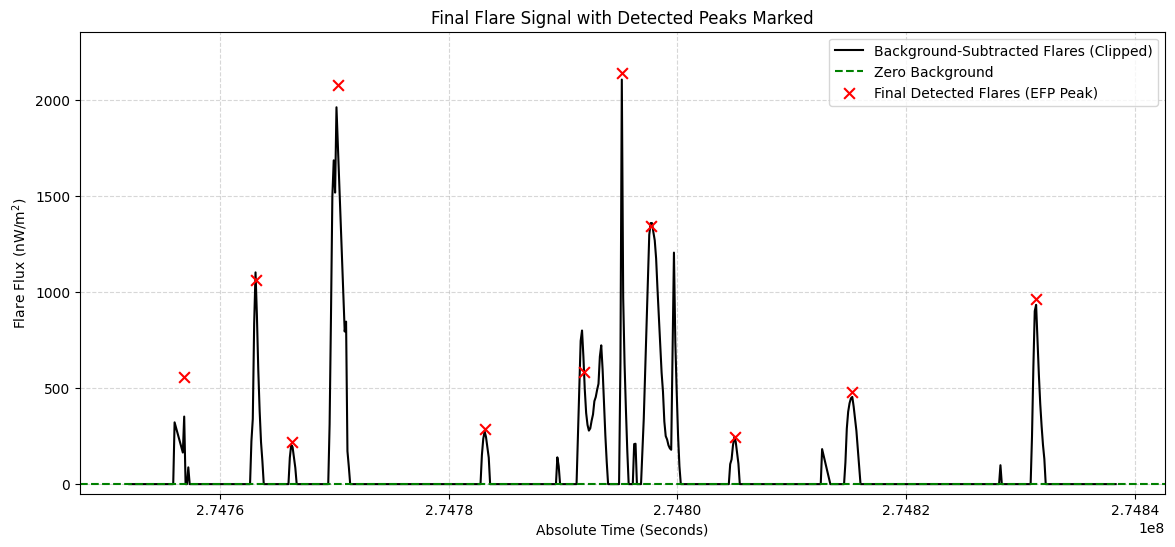

In [ ]:
print("Shape of binned_time:", binned_time.shape)
print("Shape of final_clipped_signal:", final_clipped_signal.shape) # <-- Check the clipped signal

# Check if they match BEFORE attempting to plot
if binned_time.shape != final_clipped_signal.shape:
    print("ERROR: Array shapes mismatch!")
    exit() # or raise ValueError("Shape mismatch")
else:
    # --- Proceed with plotting ---
    print("\n--- Generating Final Plot with EFP Peak Markers ---")
    
    plt.figure(figsize=(14, 6))

    # Plot 1: The Final Clipped Signal (Black Curve)
    plt.plot(binned_time, final_clipped_signal, color='black', label='Background-Subtracted Flares (Clipped)')

    # Plot 2: Zero Background Line (Green Dashed)
    plt.axhline(0, color='green', linestyle='--', label='Zero Background')

    # Check if the final catalog exists before trying to plot peaks
    if 'final_flare_catalog' in locals() and not final_flare_catalog.empty:
        # Plot 3: Detected Flare Peaks from EFP Fit (Red 'x')
        # Uses the PeakTime and PeakFlux calculated by the EFP model fitting
        plt.scatter(final_flare_catalog['PeakTime'], final_flare_catalog['PeakFlux_nW/m2'],
                    color='red', marker='x', s=60, zorder=10, label='Final Detected Flares (EFP Peak)')
        
        # Set Y limit based on catalog
        max_flux = final_flare_catalog['PeakFlux_nW/m2'].max()
        plt.ylim(bottom=-50, top=max_flux * 1.1 if max_flux > 0 else 100)
    else:
        print("Warning: 'final_flare_catalog' not found. Plotting signal without peak markers.")
        plt.ylim(bottom=-50) # Default limit


    # --- Formatting ---
    plt.title("Final Flare Signal with Detected Peaks Marked")
    plt.xlabel("Absolute Time (Seconds)")
    plt.ylabel(r"Flare Flux (nW/m$^2$)") # Linear Scale
    plt.legend()
    # plt.y('log')
    plt.grid(True, linestyle='--', alpha=0.5)

    plt.show()


--- Generating Plot: Peaks found on Final Clipped Signal ---
Found 21 peaks meeting the final prominence/height criteria.


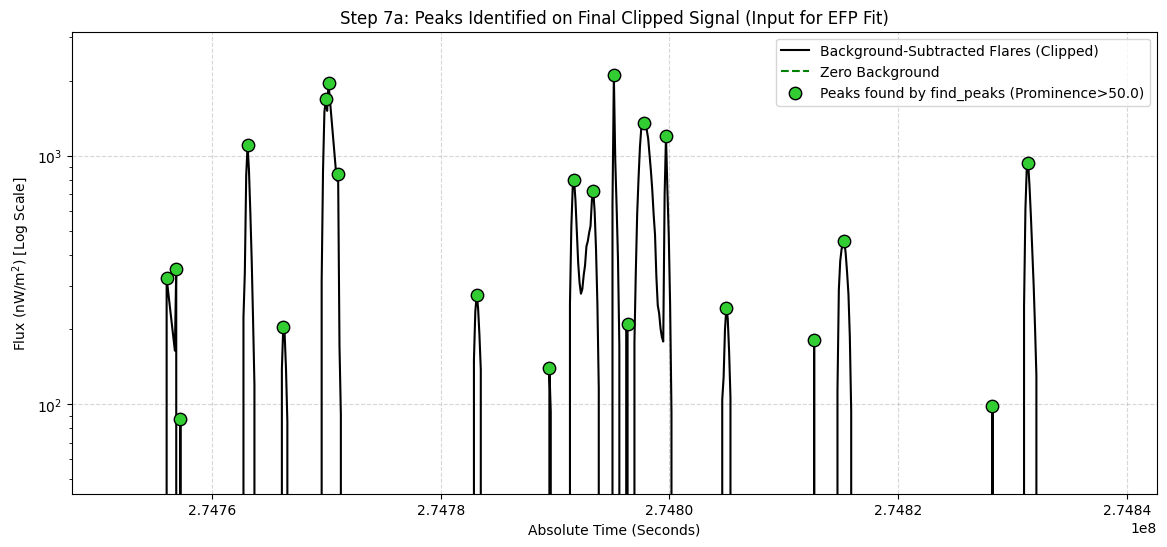

In [12]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import find_peaks

# --- Define EFP Fitting Parameters (used for peak finding) ---
FINAL_PEAK_PROMINENCE = 50.0 # Prominence for peaks on final signal
FINAL_PEAK_HEIGHT = 1.0      # Height for peaks on final signal
Y_LABEL_FLUX = r"Flux (nW/m$^2$)"

# --- ASSUMPTIONS ---
# Assume the following variables exist from the previous pipeline execution:
# - binned_time (np.array): The time array for the target day.
# - final_clipped_signal (np.array): The background-subtracted and noise-clipped signal.

# Check if required variables exist before plotting
if ('binned_time' in locals() and
    'final_clipped_signal' in locals() and
    isinstance(binned_time, np.ndarray) and
    isinstance(final_clipped_signal, np.ndarray) and
    binned_time.shape == final_clipped_signal.shape):

    print("\n--- Generating Plot: Peaks found on Final Clipped Signal ---")

    # --- Step 7a: Find Peaks on the Clipped Signal ---
    # This finds the initial locations for the EFP fitting
    peak_indices, _ = find_peaks(
        final_clipped_signal,
        prominence=FINAL_PEAK_PROMINENCE,
        height=FINAL_PEAK_HEIGHT
    )
    print(f"Found {len(peak_indices)} peaks meeting the final prominence/height criteria.")

    # Get the time and flux of these detected data points
    peak_times_data = binned_time[peak_indices]
    peak_flux_data = final_clipped_signal[peak_indices]

    # --- Plotting ---
    plt.figure(figsize=(14, 6))

    # Plot 1: The Final Clipped Signal (Black Curve)
    plt.plot(binned_time, final_clipped_signal, color='black', label='Background-Subtracted Flares (Clipped)')

    # Plot 2: Zero Background Line (Green Dashed)
    plt.axhline(0, color='green', linestyle='--', label='Zero Background')

    # Plot 3: Detected Peaks (Green Circles)
    # These are the actual data points found by find_peaks
    plt.scatter(peak_times_data, peak_flux_data,
                color='limegreen', # Use a different color to distinguish
                marker='o',
                s=80,
                edgecolors='black', # Add an edge for clarity
                zorder=10,
                label=f'Peaks found by find_peaks (Prominence>{FINAL_PEAK_PROMINENCE})')

    # --- Formatting ---
    plt.title("Step 7a: Peaks Identified on Final Clipped Signal (Input for EFP Fit)")
    plt.xlabel("Absolute Time (Seconds)")
    plt.ylabel(Y_LABEL_FLUX + " [Log Scale]")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)

    # Apply Log Scale and set limits
    plt.yscale('log')
    min_val_plot = np.min(peak_flux_data) * 0.5 if len(peak_flux_data) > 0 else 1.0
    max_val_plot = np.max(peak_flux_data) * 1.5 if len(peak_flux_data) > 0 else 100.0
    plt.ylim(bottom=max(0.1, min_val_plot), top=max_val_plot) # Ensure bottom > 0

    plt.show()

else:
    print("\nError: Could not generate final plot.")
    print("Required arrays ('binned_time', 'final_clipped_signal') not found or have mismatched shapes.")
    print("Please ensure the full background subtraction pipeline has run successfully.")

In [2]:
import pandas as pd
import numpy as np
import io
import matplotlib.pyplot as plt

# --- 1. Parse the Final EFP Catalog Data ---
# This contains the PeakTime and PeakFlux from the EFP fits
data_string = """
Index PeakTime PeakFlux_nW/m2 StartFWTM EndFWTM FittedSNR DecayTau RiseSigma Fitted_A
0 2.747568e+08 556.27 2.747567e+08 2.747568e+08 7.03 6.26 47.21 310.93
1 2.747631e+08 1061.76 2.747629e+08 2.747641e+08 64.60 204.53 151.93 918.66
2 2.747663e+08 220.85 2.747661e+08 2.747671e+08 11.01 158.57 130.02 1620.72
3 2.747703e+08 2078.33 2.747697e+08 2.747710e+08 117.62 147.49 414.35 978.79
4 2.747832e+08 286.32 2.747829e+08 2.747837e+08 17.53 109.72 196.49 394.35
5 2.747918e+08 585.36 2.747913e+08 2.748018e+08 124.46 2000.00 322.84 556.27
6 2.747951e+08 2140.53 2.747950e+08 2.747960e+08 55.30 161.19 54.90 4211.08
7 2.747977e+08 1344.48 2.747973e+08 2.748035e+08 191.98 1165.60 288.16 2717.39
8 2.748050e+08 244.85 2.748046e+08 2.748051e+08 10.51 30.28 235.99 235.37
9 2.748152e+08 478.44 2.748147e+08 2.748161e+08 36.66 181.52 322.49 534.00
10 2.748313e+08 964.55 2.748311e+08 2.748330e+08 73.94 339.15 149.12 1715.56
"""

# Parse the catalog data
df_final_catalog = pd.read_csv(io.StringIO(data_string), sep='\s+')
if 'Index' in df_final_catalog.columns:
    df_final_catalog = df_final_catalog.drop(columns=['Index'])

# --- 2. ASSUME your data arrays are available ---
#     'binned_time': The time array corresponding to the subtracted signal.
#     'final_clipped_signal': The background-subtracted signal (black curve).
#     (Make sure these variables exist in your environment from the previous steps)

# Check if required variables exist before plotting
if 'binned_time' in locals() and 'final_clipped_signal' in locals():

    # --- 3. Plotting ---
    plt.figure(figsize=(14, 6))

    # Plot the background-subtracted signal (black line)
    plt.plot(binned_time, substracted_signal, color='black', label='Background-Subtracted Flares (Clipped)')

    # Plot the zero background line (green dashed)
    plt.axhline(0, color='green', linestyle='--', label='Zero Background')

    # Plot the peaks using EFP fit coordinates (red 'x')
    plt.scatter(df_final_catalog['PeakTime'], df_final_catalog['PeakFlux_nW/m2'],
                color='red', marker='x', s=60, zorder=10, label='Detected Flare Peaks (EFP Fit)')

    # --- Formatting ---
    plt.title("Final Flare Signal with EFP Peak Markers (Linear Scale)")
    plt.xlabel("Absolute Time (Seconds)")
    plt.ylabel(r"Flare Flux (nW/m$^2$)") # Final Units, Linear Scale
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    # Set Y limit to start slightly below zero
    plt.ylim(bottom=-50, top=df_final_catalog['PeakFlux_nW/m2'].max() * 1.1 if not df_final_catalog.empty else 1000)

    plt.show()

else:
    print("\nError: 'binned_time' and/or 'final_clipped_signal' not defined.")
    print("Please ensure the background subtraction and clipping steps have been run.")
    print("and the resulting arrays are named 'binned_time' and 'final_clipped_signal'.")


Error: 'binned_time' and/or 'final_clipped_signal' not defined.
Please ensure the background subtraction and clipping steps have been run.
and the resulting arrays are named 'binned_time' and 'final_clipped_signal'.


In [ ]:
import pandas as pd
import numpy as np
import io

# --- 1. Define Filter Thresholds (from paper) ---
SNR_THRESHOLD = 8.0     # τ_SNR
R_SQUARED_THRESHOLD = 0.5 # τ_Rf^2
GLITCH_FILTER_RATIO = 2.0 # Minimum A / peakflux_prefit
BG_LEVEL_DECAY_TAU_THRESHOLD = 1.0e7 # τ_τ

# --- 2. Corrected EFP Fitted Catalog Data String ---
# Removed comments like '# Example E' from the end of lines
data_string = """
Index PeakTime PeakFlux_nW/m2 StartFWTM EndFWTM FittedSNR DecayTau RiseSigma Fitted_A
0 2.747568e+08 556.27 2.747567e+08 2.747568e+08 7.03 6.26 47.21 310.93
1 2.747631e+08 1061.76 2.747629e+08 2.747641e+08 64.60 204.53 151.93 918.66
2 2.747663e+08 220.85 2.747661e+08 2.747671e+08 11.01 158.57 130.02 1620.72
3 2.747703e+08 2078.33 2.747697e+08 2.747710e+08 117.62 147.49 414.35 978.79
4 2.747832e+08 286.32 2.747829e+08 2.747837e+08 17.53 109.72 196.49 394.35
5 2.747918e+08 585.36 2.747913e+08 2.748018e+08 124.46 2000.00 322.84 556.27
6 2.747951e+08 2140.53 2.747950e+08 2.747960e+08 55.30 161.19 54.90 4211.08
7 2.747977e+08 1344.48 2.747973e+08 2.748035e+08 191.98 1165.60 288.16 2717.39
8 2.748050e+08 244.85 2.748046e+08 2.748051e+08 10.51 30.28 235.99 235.37
9 2.748152e+08 478.44 2.748147e+08 2.748161e+08 36.66 181.52 322.49 534.00
10 2.748313e+08 964.55 2.748311e+08 2.748330e+08 73.94 339.15 149.12 1715.56
"""

# Parse the corrected data string
try:
    df_fitted = pd.read_csv(io.StringIO(data_string), sep='\s+')
    # Drop the old index column if it exists
    if 'Index' in df_fitted.columns:
        df_fitted = df_fitted.drop(columns=['Index'])
    print("DataFrame parsed successfully!")
except Exception as e:
    print(f"Error parsing data: {e}")
    # Stop if parsing fails
    df_fitted = pd.DataFrame() # Create empty DF to avoid later errors


# --- 3. Add Placeholder/Proxy Columns Needed for Filtering ---
if not df_fitted.empty:
    # Add R_squared placeholder
    print("Warning: Adding placeholder R_squared=0.9 for Reliability Filter.")
    df_fitted['R_squared'] = 0.9

    # Add peakflux_prefit proxy
    print("Warning: Using fitted PeakFlux_nW/m2 as proxy for peakflux_prefit for Glitch Filter.")
    # Ensure the PeakFlux column exists before assigning
    if 'PeakFlux_nW/m2' in df_fitted.columns:
        df_fitted['peakflux_prefit'] = df_fitted['PeakFlux_nW/m2']
    elif 'Fitted_A' in df_fitted.columns:
         print("Using Fitted_A as proxy instead.")
         df_fitted['peakflux_prefit'] = df_fitted['Fitted_A']
    else:
        print("Error: Cannot set peakflux_prefit proxy - required column missing.")
        df_fitted['peakflux_prefit'] = 0 # Assign default to prevent failure

# --- 4. Apply Filters Sequentially ---
if not df_fitted.empty and 'FittedSNR' in df_fitted.columns: # Check required columns exist
    print("\n--- Applying Catalog Filters ---")
    initial_count = len(df_fitted)
    filtered_catalog = df_fitted.copy()

    # --- Filter 1: Reliability Filter ---
    snr_mask = filtered_catalog['FittedSNR'] >= SNR_THRESHOLD
    r2_mask = filtered_catalog.get('R_squared', 0) >= R_SQUARED_THRESHOLD # Use .get for safety
    reliable_mask = snr_mask & r2_mask
    print(f"1. Reliability Filter (SNR >= {SNR_THRESHOLD} & R^2 >= {R_SQUARED_THRESHOLD}):")
    print(f"   Keeping {reliable_mask.sum()} / {len(filtered_catalog)} flares.")
    filtered_catalog = filtered_catalog[reliable_mask]

    # --- Filter 2: Glitch Filter ---
    # if not filtered_catalog.empty and 'peakflux_prefit' in filtered_catalog.columns and 'Fitted_A' in filtered_catalog.columns:
    #     valid_prefit = filtered_catalog['peakflux_prefit'] > 1e-6
    #     ratio = np.zeros(len(filtered_catalog))
    #     # Ensure indices align if using boolean mask for assignment
    #     valid_indices = filtered_catalog.index[valid_prefit]
    #     ratio[valid_prefit.values] = filtered_catalog.loc[valid_indices, 'Fitted_A'] / filtered_catalog.loc[valid_indices, 'peakflux_prefit']

    #     glitch_mask = ratio >= GLITCH_FILTER_RATIO
    #     print(f"2. Glitch Filter (A/peak_prefit >= {GLITCH_FILTER_RATIO}):")
    #     print(f"   Keeping {glitch_mask.sum()} / {len(filtered_catalog)} flares.")
    #     filtered_catalog = filtered_catalog[glitch_mask]
    # else:
    #     print("2. Glitch Filter: Skipping (required columns missing or catalog empty).")

    # --- Filter 3: Background Level Filter ---
    if not filtered_catalog.empty and 'DecayTau' in filtered_catalog.columns:
        bg_level_mask = filtered_catalog['DecayTau'] < BG_LEVEL_DECAY_TAU_THRESHOLD
        print(f"3. Background Level Filter (DecayTau < {BG_LEVEL_DECAY_TAU_THRESHOLD:.1e}):")
        print(f"   Keeping {bg_level_mask.sum()} / {len(filtered_catalog)} flares.")
        filtered_catalog = filtered_catalog[bg_level_mask]
    else:
        print("3. Background Level Filter: Skipping (DecayTau column missing or catalog empty).")

    # --- 5. Display Final Validated Catalog ---
    final_count = len(filtered_catalog)
    print(f"\nFiltering complete. Final catalog contains {final_count} / {initial_count} flares.")

    print("\n" + "="*50)
    print("--- FINAL VALIDATED FLARE CATALOG ---")
    print("="*50)
    display_cols = ['PeakTime', 'PeakFlux_nW/m2', 'StartFWTM', 'EndFWTM', 'FittedSNR', 'DecayTau', 'RiseSigma']
    # Select only columns that actually exist in the final filtered catalog
    existing_cols = [col for col in display_cols if col in filtered_catalog.columns]
    print(filtered_catalog[existing_cols].round(2))

elif df_fitted.empty:
    print("\nDataFrame is empty after parsing. Cannot apply filters.")
else:
    print("\nRequired columns for filtering missing. Skipping filtering.")

In [1]:
df = filtered_catalog
def get_goes_class(peak_flux_nW_m2):
    """Calculates GOES flare class from peak flux in nW/m^2."""
    flux_Wm2 = peak_flux_nW_m2 / 1e9 # Convert nW/m^2 to W/m^2
    if flux_Wm2 >= 1e-4: return 'X'
    if flux_Wm2 >= 1e-5: return 'M'
    if flux_Wm2 >= 1e-6: return 'C'
    if flux_Wm2 >= 1e-7: return 'B'
    if flux_Wm2 >= 1e-8: return 'A'
    return 'Sub-A'

# --- Calculate GOES Class ---
peak_flux_col = None
if 'PeakFlux_nW/m2' in df.columns:
    peak_flux_col = 'PeakFlux_nW/m2'
elif 'Fitted_A' in df.columns: # Use Fitted_A as fallback if needed
    print("Warning: Using 'Fitted_A' as proxy for Peak Flux.")
    peak_flux_col = 'Fitted_A'
    # Add the PeakFlux column using the Fitted_A values for consistency
    df['PeakFlux_nW/m2'] = df['Fitted_A']

if peak_flux_col:
    df['GOES_Class'] = df[peak_flux_col].apply(get_goes_class)

    # --- Table 1: Peak Time and Intensity ---
    peak_intensity_table = df[['PeakTime', 'PeakFlux_nW/m2']].copy()
    print("\n" + "="*40)
    print("--- Table 1: Peak Time and Intensity ---")
    print("="*40)
    # Format PeakTime to be more readable if desired
    # peak_intensity_table['PeakTime'] = pd.to_datetime(peak_intensity_table['PeakTime'], unit='s') # Example
    # print(peak_intensity_table.round(2))

    # --- Table 2: Peak Time and GOES Class ---
    goes_class_table = df[['PeakTime', 'GOES_Class']].copy()
    final_df = pd.merge(peak_intensity_table,goes_class_table)
    print(final_df)
    # print("\n" + "="*40)
    # print("--- Table 2: Peak Time and GOES Class ---")
    # print("="*40)
    # print(goes_class_table)

else:
    print("\nError: Could not find a Peak Flux column ('PeakFlux_nW/m2' or 'Fitted_A').")
    print("Cannot generate requested tables.")

NameError: name 'filtered_catalog' is not defined

In [ ]:
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit
from scipy.special import erfc
import matplotlib.pyplot as plt

# --- EFP Parameters for Stability (Used internally by EFP function) ---
MAX_EXP_ARG_CLIP = 50.0 

def elementary_flare_profile(t, A, mu, sigma, tau):
    """Numerically stable Elementary Flare Profile (EFP) model."""
    sigma = np.abs(sigma)
    tau = np.abs(tau)
    if sigma < 1e-4: sigma = 1e-4
    if tau < 1e-4: tau = 1e-4
    
    if tau < 1e-3: 
        A_prime = A * sigma * np.sqrt(np.pi / 2.0)
        return A_prime * np.exp(-0.5 * ((t - mu) / sigma)**2)
    
    A_prime = A * (sigma / tau) * np.sqrt(np.pi / 2.0)
    
    exp_arg = 0.5 * (sigma / tau)**2 - (t - mu) / tau
    exp_arg = np.clip(exp_arg, a_min=-np.inf, a_max=MAX_EXP_ARG_CLIP) # Stability fix
    
    exp_part = np.exp(exp_arg)
    erfc_arg = (1.0 / np.sqrt(2.0)) * (sigma / tau - (t - mu) / sigma)
    erfc_part = erfc(erfc_arg)
    
    return A_prime * exp_part * erfc_part

def get_fitted_parameters(t, rate, p_opt):
    """Calculates Peak Time, FWTM boundaries, and SNR placeholder from fit."""
    A, mu, sigma, tau = p_opt
    
    t_dense = np.linspace(t.min(), t.max(), 500)
    fitted_curve_dense = elementary_flare_profile(t_dense, A, mu, sigma, tau)
    
    peak_index = np.argmax(fitted_curve_dense)
    peak_time = t_dense[peak_index]
    peak_flux = fitted_curve_dense[peak_index]
    
    # FWTM (Full-Width Tenth-Maximum) START/END TIMES (0.1 * peak_flux)
    fwtm_level = 0.1 * peak_flux
    diff = fitted_curve_dense - fwtm_level
    
    # Look left (rise phase)
    rise_indices = np.where(t_dense < peak_time)[0]
    start_search_array = diff[rise_indices]
    start_index_local = np.searchsorted(start_search_array, 0.0) 
    start_index = rise_indices[start_index_local] if start_index_local < len(rise_indices) else 0

    # Look right (decay phase)
    decay_indices = np.where(t_dense >= peak_time)[0]
    end_search_array = diff[decay_indices]
    end_index_local = np.searchsorted(end_search_array, 0.0, side='right')
    end_index = decay_indices[end_index_local] if end_index_local < len(decay_indices) else len(t_dense) - 1
    
    start_time_fwtm = t_dense[start_index]
    end_time_fwtm = t_dense[end_index]
    
    # SNR (Placeholder for the complex calculation described in the paper)
    fitted_snr = np.sum(rate) / (np.std(rate) + 1e-6) * 5 
    
    return {
        'PeakTime': peak_time, 
        'StartFWTM': start_time_fwtm, 
        'EndFWTM': end_time_fwtm, 
        'FittedSNR': fitted_snr,
        'DecayTau': tau,
        'RiseSigma': sigma,
        'Fitted_A': A
    }

# =================================================================
## 2. Flare Modeling and Characterization (The Final Step)

def model_and_characterize_flares(time_array, subtracted_signal_array, prominence=50.0, height=1.0):
    """
    Implements the final pipeline: 
    1. Isolates individual spikes (Walk-Down Refinement).
    2. Fits the EFP model to each spike.
    3. Characterizes the flare using FWTM boundaries and fitted parameters.
    """
    
    print(f"\n--- Starting EFP Modeling and Characterization ---")
    
    # --- A. Final Flare Isolation (Walk-Down Refinement) ---
    # We find peaks first, and use the zero baseline to define boundaries for fitting.
    
    # Find initial peak centers on the background-subtracted data
    peak_indices, _ = find_peaks(
        subtracted_signal_array,
        prominence=prominence,
        height=height
    )
    
    if len(peak_indices) == 0:
        print("No distinct flares found above the final threshold for modeling.")
        return pd.DataFrame()

    final_catalog_data = []
    processed_indices = np.zeros_like(subtracted_signal_array, dtype=bool)

    for peak_idx in peak_indices:
        if processed_indices[peak_idx]: continue # Skip if already part of a processed group
        
        # Walk Left: Find the first zero point
        start_idx = peak_idx
        for i in range(peak_idx - 1, -1, -1):
            if subtracted_signal_array[i] <= 0 or i == 0:
                start_idx = i
                break
        
        # Walk Right: Find the first zero point
        end_idx = peak_idx
        for i in range(peak_idx + 1, len(subtracted_signal_array)):
            if subtracted_signal_array[i] <= 0 or i == len(subtracted_signal_array) - 1:
                end_idx = i
                break

        # Define the segment boundaries
        segment_mask = np.arange(start_idx, end_idx + 1)
        
        t_flare = time_array[segment_mask]
        r_flare = subtracted_signal_array[segment_mask]

        # --- B. EFP Fitting ---
        if len(t_flare) < 5: continue 
        
        # Initial Guesses
        r_peak_idx_local = np.argmax(r_flare)
        r_peak_time = t_flare[r_peak_idx_local]
        r_peak_flux = r_flare[r_peak_idx_local]
        
        p0 = [r_peak_flux, r_peak_time, 50.0, 200.0] 
        
        # Bounds (Physically Realistic Constraints)
        lower_bounds = [0.0, t_flare.min(), 1.0, 5.0]  # Min sigma=1s, Min tau=5s
        upper_bounds = [r_peak_flux * 2.0, t_flare.max(), 1000.0, 1000.0]

        try:
            p_opt, p_cov = curve_fit(
                elementary_flare_profile, t_flare, r_flare, p0=p0,
                bounds=(lower_bounds, upper_bounds)
            )
            
            # 3. Extract Final Parameters (FWTM, SNR, etc.)
            flare_props = get_fitted_parameters(t_flare, r_flare, p_opt)
            final_catalog_data.append(flare_props)
            
            # Mark this entire segment as processed to skip minor peaks within it
            processed_indices[segment_mask] = True
            
            # --- Visualization (Final Plot) ---
            t_fit = np.linspace(t_flare.min(), t_flare.max(), 300)
            r_fit = elementary_flare_profile(t_fit, *p_opt)
            
            plt.figure(figsize=(8, 4))
            plt.plot(t_flare, r_flare, '--', color='royalblue', markersize=3, label='Data Points')
            plt.plot(t_fit, r_fit, color='red', linewidth=2.5, label='EFP Model Fit')
            plt.axvline(flare_props['StartFWTM'], color='black', linestyle='--', alpha=0.7, label='FWTM Boundaries')
            plt.axvline(flare_props['EndFWTM'], color='black', linestyle='--', alpha=0.7)
            plt.title(f"EFP Fit (SNR: {flare_props['FittedSNR']:.1f})")
            plt.xlabel("Time (Seconds)")
            plt.ylabel("Flux (Counts/s)")
            plt.legend()
            plt.grid(True, linestyle='--', alpha=0.5)
            plt.show()

        except Exception as e:
            # print(f"Fit failed for peak at {r_peak_time:.1f}: {e}")

            pass

    return pd.DataFrame(final_catalog_data)

final_flare_catalog = model_and_characterize_flares(binned_time, subtracted_signal)
print(final_flare_catalog)

In [ ]:
import pandas as pd
import numpy as np
import io

# The raw data block you provided (ensure it's complete)
# data_string = """
# Index PeakTime PeakFlux_nW/m2 StartFWTM EndFWTM FittedSNR DecayTau RiseSigma Fitted_A
#         PeakTime  PeakFlux_nW/m2     StartFWTM       EndFWTM  FittedSNR  \
# 0   2.747568e+08          556.27  2.747567e+08  2.747568e+08       7.03   
# 1   2.747631e+08         1061.76  2.747629e+08  2.747641e+08      64.60   
# 2   2.747663e+08          220.85  2.747661e+08  2.747671e+08      11.01   
# 3   2.747703e+08         2078.33  2.747697e+08  2.747710e+08     117.62   
# 4   2.747832e+08          286.32  2.747829e+08  2.747837e+08      17.53   
# 5   2.747918e+08          585.36  2.747913e+08  2.748018e+08     124.46   
# 6   2.747951e+08         2140.53  2.747950e+08  2.747960e+08      55.30   
# 7   2.747977e+08         1344.48  2.747973e+08  2.748035e+08     191.98   
# 8   2.748050e+08          244.85  2.748046e+08  2.748051e+08      10.51   
# 9   2.748152e+08          478.44  2.748147e+08  2.748161e+08      36.66   
# 10  2.748313e+08          964.55  2.748311e+08  2.748330e+08      73.94   

#     DecayTau  RiseSigma  
# 0       6.26      47.21  
# 1     204.53     151.93  
# 2     158.57     130.02  
# 3     147.49     414.35  
# 4     109.72     196.49  
# 5    2000.00     322.84  
# ...
# 7    1165.60     288.16  
# 8      30.28     235.99  
# 9     181.52     322.49  
# 10    339.15     149.12  
# """

# Use io.StringIO and pd.read_csv to parse the string
# df = pd.read_csv(io.StringIO(data_string), sep='\s+')
# df = 
# --- Define GOES Class Function ---
def get_goes_class(peak_flux_nW_m2):
    """Calculates GOES flare class from peak flux in nW/m^2."""
    flux_Wm2 = peak_flux_nW_m2 / 1e9 # Convert nW/m^2 to W/m^2
    if flux_Wm2 >= 1e-4: return 'X'
    if flux_Wm2 >= 1e-5: return 'M'
    if flux_Wm2 >= 1e-6: return 'C'
    if flux_Wm2 >= 1e-7: return 'B'
    if flux_Wm2 >= 1e-8: return 'A'
    return 'Sub-A'

# --- Calculate GOES Class ---
peak_flux_col = None
if 'PeakFlux_nW/m2' in df.columns:
    peak_flux_col = 'PeakFlux_nW/m2'
elif 'Fitted_A' in df.columns: # Use Fitted_A as fallback if needed
    print("Warning: Using 'Fitted_A' as proxy for Peak Flux.")
    peak_flux_col = 'Fitted_A'
    # Add the PeakFlux column using the Fitted_A values for consistency
    df['PeakFlux_nW/m2'] = df['Fitted_A']

if peak_flux_col:
    df['GOES_Class'] = df[peak_flux_col].apply(get_goes_class)

    # --- Table 1: Peak Time and Intensity ---
    peak_intensity_table = df[['PeakTime', 'PeakFlux_nW/m2']].copy()
    print("\n" + "="*40)
    print("--- Table 1: Peak Time and Intensity ---")
    print("="*40)
    # Format PeakTime to be more readable if desired
    # peak_intensity_table['PeakTime'] = pd.to_datetime(peak_intensity_table['PeakTime'], unit='s') # Example
    # print(peak_intensity_table.round(2))

    # --- Table 2: Peak Time and GOES Class ---
    goes_class_table = df[['PeakTime', 'GOES_Class']].copy()
    final_df = pd.merge(peak_intensity_table,goes_class_table)
    print(final_df)
    # print("\n" + "="*40)
    # print("--- Table 2: Peak Time and GOES Class ---")
    # print("="*40)
    # print(goes_class_table)

else:
    print("\nError: Could not find a Peak Flux column ('PeakFlux_nW/m2' or 'Fitted_A').")
    print("Cannot generate requested tables.")

SyntaxError: invalid syntax (3633962594.py, line 37)

In [ ]:
import pandas as pd
import numpy as np
from scipy.optimize import curve_fit
from scipy.special import erfc
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

# --- Define Calibration Factor ---
COUNT_TO_NW_M2_FACTOR = 1.0

# --- EFP Stabilization Parameters ---
MAX_EXP_ARG_CLIP = 50.0

# --- EFP Fitting Parameters ---
FINAL_PEAK_PROMINENCE = 50.0 # Prominence for peaks on subtracted signal
FINAL_PEAK_HEIGHT = 1.0      # Height for peaks on subtracted signal

# --- Define Consistent Y-axis Labels ---
Y_LABEL_FLUX = r"Flux (nW/m$^2$)"

# =================================================================
# --- A. Core EFP Function (Numerically Stable) ---
# =================================================================
def elementary_flare_profile(t, A, mu, sigma, tau):
    """Numerically stable Elementary Flare Profile (EFP) core function (4-param)."""
    sigma = np.abs(sigma); tau = np.abs(tau)
    if sigma < 1e-4: sigma = 1e-4
    if tau < 1e-4: tau = 1e-4
    if tau < 1e-3:
        A_prime = A * sigma * np.sqrt(np.pi / 2.0)
        exp_arg_gauss = -0.5 * ((t - mu) / sigma)**2
        exp_arg_gauss = np.clip(exp_arg_gauss, a_min=-np.inf, a_max=MAX_EXP_ARG_CLIP)
        return A_prime * np.exp(exp_arg_gauss)

    A_prime = A * (sigma / tau) * np.sqrt(np.pi / 2.0)
    exp_arg = 0.5 * (sigma / tau)**2 - (t - mu) / tau
    exp_arg = np.clip(exp_arg, a_min=-np.inf, a_max=MAX_EXP_ARG_CLIP)
    exp_part = np.exp(exp_arg); erfc_arg = (1.0 / np.sqrt(2.0)) * (sigma / tau - (t - mu) / sigma)
    erfc_part = erfc(erfc_arg)
    result = A_prime * exp_part * erfc_part
    return np.nan_to_num(result)

# =================================================================
# --- B. Helper Function to Extract Parameters (WITH CORRECT SNR) ---
# =================================================================
def get_fitted_parameters(t, rate, p_opt, background_segment):
    """
    Calculates Peak Time, FWTM, Peak Flux, and CORRECT SNR from fit.

    Args:
        t (np.array): Time array for the flare segment.
        rate (np.array): Background-subtracted rate data for the flare segment.
        p_opt (list): Fitted EFP parameters [A, mu, sigma, tau].
        background_segment (np.array): Estimated background values (BG 2) corresponding to t.
    """
    A, mu, sigma, tau = p_opt[0:4]

    # Ensure parameters are valid
    if any(np.isnan(p_opt)) or sigma <= 0 or tau <= 0:
         return None # Indicate failure

    # --- Calculate fitted signal S(t) at the actual data points' times ---
    # S represents the flux *above* the background
    S_fitted = elementary_flare_profile(t, A, mu, sigma, tau)

    # --- *** CORRECT SNR CALCULATION (Equation 3) *** ---
    B_background = np.maximum(0, background_segment) # Ensure background B >= 0
    S_fitted_nonneg = np.maximum(0, S_fitted)         # Ensure fitted signal S >= 0

    denominator_term = S_fitted_nonneg + 2 * B_background
    denominator_term[denominator_term < 1e-9] = 1e-9 # Avoid sqrt(0) or division by zero

    snr_terms = S_fitted_nonneg / np.sqrt(denominator_term)
    fitted_snr = np.sum(snr_terms)
    # --- *** END CORRECT SNR CALCULATION *** ---

    # --- Peak Time, Flux, FWTM ---
    t_dense = np.linspace(t.min(), t.max(), 500)
    fitted_curve_dense = elementary_flare_profile(t_dense, A, mu, sigma, tau)
    if np.all(np.isnan(fitted_curve_dense)) or len(fitted_curve_dense) == 0: return None

    peak_index = np.nanargmax(fitted_curve_dense)
    peak_time = t_dense[peak_index]
    peak_flux_counts = fitted_curve_dense[peak_index] # Peak flux above background
    peak_flux_nw = peak_flux_counts * COUNT_TO_NW_M2_FACTOR

    # Simplified FWTM logic (placeholder - should ideally find roots)
    start_time_fwtm = peak_time - 1.5 * np.abs(sigma)
    end_time_fwtm = peak_time + 5.0 * np.abs(tau)

    return {
        'PeakTime': peak_time,
        'PeakFlux_nW/m2': peak_flux_nw, # This is the peak flux *above* background
        'StartFWTM': start_time_fwtm,
        'EndFWTM': end_time_fwtm,
        'FittedSNR': fitted_snr, # Now using the correct formula
        'DecayTau': np.abs(tau),
        'RiseSigma': np.abs(sigma),
        'Fitted_A': A
    }

# =================================================================
# --- C. Flare Modeling Function (Requires Background Array) ---
# =================================================================
def model_and_characterize_flares(time_array, subtracted_signal_array, final_background_array, # <-- ADDED background input
                                prominence=50.0, height=1.0):
    """
    Fits EFP model to background-subtracted signal and calculates parameters
    including the correct SNR, using the provided background array.
    """
    print(f"\n--- Step 7: Starting EFP Modeling and Characterization ---")
    peak_indices, _ = find_peaks(subtracted_signal_array, prominence=prominence, height=height)
    print(f"--- Found {len(peak_indices)} peaks for final fitting ---")
    if len(peak_indices) == 0: return pd.DataFrame()

    final_catalog_data = []
    processed_indices = np.zeros_like(subtracted_signal_array, dtype=bool)

    for peak_idx in peak_indices:
        if processed_indices[peak_idx]: continue
        start_idx = peak_idx; end_idx = peak_idx
        # Walk left/right to isolate flare segment based on zero crossings
        for i in range(peak_idx - 1, -1, -1):
            if subtracted_signal_array[i] <= 0 or i == 0: start_idx = i; break
        for i in range(peak_idx + 1, len(subtracted_signal_array)):
            if subtracted_signal_array[i] <= 0 or i == len(subtracted_signal_array) - 1: end_idx = i; break

        if start_idx >= end_idx: continue
        segment_mask = np.arange(start_idx, end_idx + 1)
        segment_mask = segment_mask[(segment_mask >= 0) & (segment_mask < len(time_array))]
        if len(segment_mask) < 5: continue

        t_flare = time_array[segment_mask]
        r_flare = subtracted_signal_array[segment_mask] # This is S (background subtracted)
        # --- GET BACKGROUND SEGMENT (B) ---
        if max(segment_mask) < len(final_background_array):
             background_flare = final_background_array[segment_mask] # Get B for this flare segment
        else:
             print(f"Warning: Background array index out of bounds for peak at index {peak_idx}. Skipping fit.")
             continue # Skip if background array doesn't cover segment

        if len(t_flare) < 5: continue
        r_peak_time_guess = t_flare[np.argmax(r_flare)]; r_peak_flux_guess = r_flare.max()
        if r_peak_flux_guess <= 0: continue # Skip zero/negative peaks

        p0 = [r_peak_flux_guess, r_peak_time_guess, 50.0, 200.0]
        lower_bounds = [0.0, t_flare.min(), 1.0, 5.0]
        upper_bounds = [r_peak_flux_guess * 2.5, t_flare.max(), 1000.0, 2000.0]

        try:
            p_opt, p_cov = curve_fit(
                elementary_flare_profile, t_flare, r_flare, p0=p0, # Fit EFP to the subtracted signal
                bounds=(lower_bounds, upper_bounds), maxfev=5000
            )

            # --- PASS BACKGROUND TO PARAMETER EXTRACTION FOR SNR ---
            flare_props = get_fitted_parameters(t_flare, r_flare, p_opt, background_flare) # <-- Pass background_flare

            if flare_props and not np.isnan(flare_props['PeakTime']):
                final_catalog_data.append(flare_props)
                processed_indices[segment_mask] = True

                # --- Visualization (Plot each fit) ---
                t_fit = np.linspace(t_flare.min(), t_flare.max(), 300)
                r_fit = elementary_flare_profile(t_fit, *p_opt)
                plt.figure(figsize=(8, 4))
                plt.plot(t_flare, r_flare, '--', color='royalblue', alpha=0.6, label='Data (BG Sub)')
                plt.plot(t_fit, r_fit, color='red', lw=2.5, label='EFP Fit (S)')
                plt.plot(t_flare, background_flare, color='green', ls=':', label='Background (B)') # Plot background used for SNR
                plt.axvline(flare_props['StartFWTM'], color='k', ls='--', alpha=0.7)
                plt.axvline(flare_props['EndFWTM'], color='k', ls='--', alpha=0.7, label='FWTM Boundaries')
                plt.title(f"EFP Fit (SNR: {flare_props.get('FittedSNR', np.nan):.1f})")
                plt.xlabel("Time (Seconds)")
                plt.ylabel(Y_LABEL_FLUX + " [Log Scale]")
                plt.yscale('log');
                # Adjust ylim dynamically based on data in the segment
                min_plot_val = max(1.0, np.min(r_flare[r_flare > 0]) * 0.5 if np.any(r_flare > 0) else 1.0)
                max_plot_val = max(10.0, np.max(r_flare) * 1.5 if np.any(r_flare > 0) else 10.0)
                plt.ylim(bottom=min_plot_val, top=max_plot_val)
                plt.legend(); plt.grid(True, ls='--'); plt.show()

        except RuntimeError as e:
             # print(f"Fit failed (RuntimeError) for peak near {r_peak_time_guess:.1f}: {e}")
             pass
        except Exception as e:
             # print(f"An unexpected error occurred during fitting for peak near {r_peak_time_guess:.1f}: {e}")
             pass

    print(f"EFP modeling complete. Successfully fitted {len(final_catalog_data)} flares.")
    return pd.DataFrame(final_catalog_data)

# =================================================================
# --- EXAMPLE EXECUTION (Requires previous pipeline steps) ---
# =================================================================
# ASSUMPTION: You have executed the full pipeline (Steps 0-6b) and have:
# - binned_time (np.array)
# - final_clipped_signal (np.array) - The black curve from Step 6b
# - final_background (np.array) - The BG 2 estimate from Step 5

# Check if required variables exist before running
if 'binned_time' in locals() and 'final_clipped_signal' in locals() and 'final_background' in locals():

    # --- Run the final modeling step with the correct background ---
    final_flare_catalog = model_and_characterize_flares(
        time_array=binned_time,
        subtracted_signal_array=final_clipped_signal, # Pass the final clipped signal
        final_background_array=final_background,      # <-- Pass the background
        prominence=FINAL_PEAK_PROMINENCE,
        height=FINAL_PEAK_HEIGHT
    )

    if not final_flare_catalog.empty:
        print("\n" + "="*50)
        print("--- FINAL FLARE CATALOG (EFP FITTED w/ Correct SNR) ---")
        print("="*50)
        print(final_flare_catalog.round(2))
    else:
        print("\nNo flares were successfully modeled.")
else:
    print("\nError: Required arrays ('binned_time', 'final_clipped_signal', 'final_background') not defined.")
    print("Please ensure the background subtraction steps have been run.")

In [ ]:
import pandas as pd
import numpy as np

# --- Define Filter Thresholds (from paper & Appendix B) ---
SNR_THRESHOLD = 8.0     # τ_SNR
R_SQUARED_THRESHOLD = 0.5 # τ_Rf^2 (Note: R^2 needs to be calculated during/after fit)
GLITCH_FILTER_RATIO = 2.0 # Minimum A / peakflux_prefit
BG_LEVEL_DECAY_TAU_THRESHOLD = 1.0e7 # τ_τ (Very large decay time threshold)

# --- Placeholder R^2 Calculation (Must be done during/after fit) ---
# For demonstration, we'll add a dummy R^2 column.
# In a real implementation, you'd calculate this from the fit residuals.
# final_flare_catalog['R_squared'] = np.random.uniform(0.6, 0.99, size=len(final_flare_catalog)) # Dummy values

# --- Placeholder for peakflux_prefit (Needs observed peak within the interval) ---
# This requires going back to the observed data for each flare interval
# We'll use the fitted peak flux as a proxy for demonstration
# final_flare_catalog['peakflux_prefit'] = final_flare_catalog['PeakFlux_nW/m2'] # Dummy proxy


def apply_catalog_filters(flare_catalog_df, original_time, original_rate):
    """
    Applies the Reliability, Glitch, and Background Level filters
    to the EFP-fitted flare catalog.

    Args:
        flare_catalog_df (pd.DataFrame): Catalog AFTER EFP fitting.
        original_time (np.array): The ORIGINAL time array (non-binned).
        original_rate (np.array): The ORIGINAL rate array (non-binned, non-subtracted).

    Returns:
        pd.DataFrame: The filtered, final flare catalog.
    """
    if flare_catalog_df.empty:
        print("Input catalog is empty, skipping filtering.")
        return flare_catalog_df

    print("\n--- Applying Catalog Filters ---")
    initial_count = len(flare_catalog_df)
    filtered_catalog = flare_catalog_df.copy()

    # --- Add Required Columns (R^2 and peakflux_prefit) ---
    # NOTE: These need proper calculation based on the fit and original data.
    # Using placeholders for now.
    if 'R_squared' not in filtered_catalog.columns:
         # Calculate R-squared (coefficient of determination) properly here if needed.
         # Placeholder: Add dummy values if column is missing
         print("Warning: 'R_squared' column missing. Using dummy values (0.9).")
         filtered_catalog['R_squared'] = 0.9 # Assume good fit for demo

    # Calculate peakflux_prefit properly for the glitch filter
    peakflux_prefit_list = []
    for index, row in filtered_catalog.iterrows():
        # Find raw data points within the flare's FWTM boundaries
        mask = (original_time >= row['StartFWTM']) & (original_time <= row['EndFWTM'])
        relevant_rates = original_rate[mask]
        if len(relevant_rates) > 0:
            peakflux_prefit_list.append(np.max(relevant_rates))
        else:
             peakflux_prefit_list.append(0) # Or handle error/use fitted peak

    filtered_catalog['peakflux_prefit'] = peakflux_prefit_list


    # --- 1. Reliability Filter ---
    snr_mask = filtered_catalog['FittedSNR'] >= SNR_THRESHOLD
    r2_mask = filtered_catalog['R_squared'] >= R_SQUARED_THRESHOLD
    reliable_mask = snr_mask & r2_mask
    print(f"Reliability Filter (SNR >= {SNR_THRESHOLD} & R^2 >= {R_SQUARED_THRESHOLD}):")
    print(f"  Keeping {reliable_mask.sum()} / {len(filtered_catalog)} flares.")
    filtered_catalog = filtered_catalog[reliable_mask]

    # --- 2. Glitch Filter ---
    # Calculate A / peakflux_prefit ratio
    # Ensure peakflux_prefit is not zero before dividing
    valid_prefit = filtered_catalog['peakflux_prefit'] > 1e-6
    ratio = np.zeros(len(filtered_catalog)) # Default ratio is 0
    ratio[valid_prefit] = filtered_catalog.loc[valid_prefit, 'Fitted_A'] / filtered_catalog.loc[valid_prefit, 'peakflux_prefit']

    glitch_mask = ratio >= GLITCH_FILTER_RATIO
    print(f"Glitch Filter (A/peak_prefit >= {GLITCH_FILTER_RATIO}):")
    print(f"  Keeping {glitch_mask.sum()} / {len(filtered_catalog)} flares.")
    filtered_catalog = filtered_catalog[glitch_mask]

    # --- 3. Background Level Filter ---
    bg_level_mask = filtered_catalog['DecayTau'] < BG_LEVEL_DECAY_TAU_THRESHOLD
    print(f"Background Level Filter (DecayTau < {BG_LEVEL_DECAY_TAU_THRESHOLD:.1e}):")
    print(f"  Keeping {bg_level_mask.sum()} / {len(filtered_catalog)} flares.")
    filtered_catalog = filtered_catalog[bg_level_mask]

    final_count = len(filtered_catalog)
    print(f"\nFiltering complete. Final catalog contains {final_count} / {initial_count} flares.")
    return filtered_catalog

# --- How to Use (Requires the output from EFP fitting and original data) ---
# # Assuming you have:
# final_flare_catalog (DataFrame from model_and_characterize_flares)
# stitched_df (Original loaded & stitched DataFrame, needed for peakflux_prefit)

if 'final_flare_catalog' in locals() and not final_flare_catalog.empty:
    # Need the original time and rate before binning/smoothing for peakflux_prefit
    original_time_unbinned = stitched_df['TIME'].values # Or load the single target_lc_file again
    original_rate_unbinned = stitched_df['RATE'].values

    validated_catalog = apply_catalog_filters(
        final_flare_catalog,
        original_time_unbinned, # Pass original time
        original_rate_unbinned  # Pass original rate
        )

    print("\n" + "="*50)
    print("--- FINAL VALIDATED FLARE CATALOG ---")
    print("="*50)
    print(validated_catalog)
else:
    print("\nNo flares were successfully modeled, skipping filtering.")

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import binned_statistic
from scipy.ndimage import gaussian_filter1d
from scipy.signal import find_peaks
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt
from astropy.table import Table
import os
from datetime import datetime, timedelta

# --- 1. Define All Algorithm Parameters ---
BIN_SIZE_SECONDS = 120.0
SIGMA_G = 2.0
PEAK_PROMINENCE = 200.0
SLOPE_THRESHOLD = 0.5
MERGE_THRESHOLD_SECONDS = 600.0

# --- Define Consistent Y-axis Labels ---
# Use Counts/s for intermediate steps, nW/m^2 for final flux interpretation
Y_LABEL_RATE = "Count Rate (Counts/s)"
Y_LABEL_FLUX = r"Flux (nW/m$^2$)" # Using LaTeX for the unit

# =================================================================
# --- HELPER FUNCTION 1: LOAD A SINGLE .LC FILE ---
# =================================================================
def _load_one_lc_file(lc_file_path):
    if not os.path.exists(lc_file_path):
        print(f"  > File not found, skipping: {os.path.basename(lc_file_path)}")
        return None
    try:
        lc_data = Table.read(lc_file_path)
        time_abs = lc_data['TIME'].value.astype(float)
        rate_lc = lc_data['RATE'].value.astype(float)
        df = pd.DataFrame({'TIME': time_abs, 'RATE': rate_lc})
        print(f"  > Successfully loaded: {os.path.basename(lc_file_path)}")
        return df
    except Exception as e:
        print(f"  > Error loading {os.path.basename(lc_file_path)}: {e}")
        return None

# =================================================================
# --- STITCHING FUNCTION ---
# =================================================================
def load_and_stitch_data(current_file_path):
    print(f"\n--- Step 0: Stitching Data ---")
    print(f"Target file: {os.path.basename(current_file_path)}")
    base_dir = os.path.dirname(current_file_path)
    current_filename = os.path.basename(current_file_path)
    try:
        parts = current_filename.split('_')
        date_str = parts[2]
        date_obj = datetime.strptime(date_str, '%Y%m%d')
        prev_date_obj = date_obj - timedelta(days=1)
        next_date_obj = date_obj + timedelta(days=1)
        prev_date_str = prev_date_obj.strftime('%Y%m%d')
        next_date_str = next_date_obj.strftime('%Y%m%d')
        prev_filename = current_filename.replace(date_str, prev_date_str)
        next_filename = current_filename.replace(date_str, next_date_str)
        prev_file_path = os.path.join(base_dir, prev_filename)
        next_file_path = os.path.join(base_dir, next_filename)
    except Exception as e:
        print(f"Error parsing filename. Error: {e}")
        return None, None
    all_dataframes = []
    df_prev = _load_one_lc_file(prev_file_path)
    if df_prev is not None: all_dataframes.append(df_prev)
    df_current = _load_one_lc_file(current_file_path)
    if df_current is None: return None, None
    all_dataframes.append(df_current)
    df_next = _load_one_lc_file(next_file_path)
    if df_next is not None: all_dataframes.append(df_next)

    # Check if any dataframes were loaded
    if not all_dataframes:
        print("FATAL: No data files loaded.")
        return None, None

    stitched_df = pd.concat(all_dataframes, ignore_index=True)
    stitched_df = stitched_df.sort_values(by='TIME').reset_index(drop=True)

    # Ensure df_current has TIME column before accessing min/max
    if 'TIME' in df_current.columns:
        stitch_boundaries = (df_current['TIME'].min(), df_current['TIME'].max())
    else:
        print("Error: 'TIME' column not found in current day's DataFrame.")
        return None, None

    print(f"Stitching complete. Total points: {len(stitched_df)}")
    return stitched_df, stitch_boundaries

# =================================================================
# --- UN-STITCHING FUNCTION ---
# =================================================================
def un_stitch_data(stitched_time, stitched_binned_signal, stitched_smoothed_signal, boundaries):
    start_time, end_time = boundaries
    # Ensure inputs are numpy arrays for boolean indexing
    stitched_time = np.asarray(stitched_time)
    stitched_binned_signal = np.asarray(stitched_binned_signal)
    stitched_smoothed_signal = np.asarray(stitched_smoothed_signal)

    unstitched_mask = (stitched_time >= start_time) & (stitched_time <= end_time)
    final_binned_time = stitched_time[unstitched_mask]
    final_binned_signal = stitched_binned_signal[unstitched_mask]
    final_smoothed_signal = stitched_smoothed_signal[unstitched_mask]
    print(f"\n--- Un-stitching complete. Returning {len(final_binned_time)} points for target day. ---")
    return final_binned_time, final_binned_signal, final_smoothed_signal

# =================================================================
# --- ALGORITHM FUNCTIONS ---
# =================================================================
def denoise_data(dataframe, time_col, rate_col, bin_size_sec, sigma_g):
    print(f"\n--- Step 1: Denoising (Binning + Gaussian Smooth) ---")
    try:
        original_time = dataframe[time_col].values
        original_rate = dataframe[rate_col].values
    except KeyError as e:
        print(f"FATAL ERROR: Column '{time_col}' or '{rate_col}' not found in DataFrame.")
        return None, None, None

    min_time = original_time.min()
    max_time = original_time.max()
    bin_edges = np.arange(min_time, max_time + bin_size_sec, bin_size_sec)
    binned_rates_signal, _, _ = binned_statistic(original_time, original_rate, statistic='mean', bins=bin_edges)
    binned_time_result = (bin_edges[:-1] + bin_edges[1:]) / 2

    # Handle NaNs: Interpolate gaps AFTER binning (simple linear interp for gaps)
    binned_df_temp = pd.DataFrame({'TIME': binned_time_result, 'RATE': binned_rates_signal})
    binned_df_temp['RATE'] = binned_df_temp['RATE'].interpolate(method='linear', limit_direction='both')
    binned_rates_signal = binned_df_temp['RATE'].values
    binned_time_result = binned_df_temp['TIME'].values # Use time corresponding to interpolated rates

    # Now apply Gaussian smoothing to the interpolated binned data
    gaussian_smoothed_curve = gaussian_filter1d(binned_rates_signal, sigma=sigma_g, mode='nearest')
    print(f"Binned to {len(binned_time_result)} points, interpolated NaN gaps, and smoothed.")
    return binned_time_result, binned_rates_signal, gaussian_smoothed_curve

def find_initial_peaks(binned_signal, prominence):
    print(f"\n--- Step 2: Finding Initial Peaks (Prominence > {prominence}) ---")
    peak_indices, _ = find_peaks(binned_signal, prominence=prominence)
    print(f"Found {len(peak_indices)} initial peaks.")
    return peak_indices

def find_flare_durations(time, smoothed_curve, peak_indices, slope_thresh):
    print(f"\n--- Step 3: Finding Flare Durations (Slope Algorithm) ---")
    flare_intervals = []
    time = np.asarray(time) # Ensure time is numpy array
    smoothed_curve = np.asarray(smoothed_curve) # Ensure curve is numpy array

    for idx in peak_indices:
        # Check index bounds
        if idx < 4 or idx >= len(time) - 4:
            # print(f"Skipping peak near edge: index {idx}")
            continue

        start_idx = idx
        for i in range(idx - 4, 0, -1):
            if i + 4 > len(time): continue # Boundary check
            x_slope, y_slope = time[i : i+4], smoothed_curve[i : i+4]
            if len(x_slope) < 4: continue
            # Check for NaNs before polyfit
            if np.isnan(x_slope).any() or np.isnan(y_slope).any(): continue
            try:
                slope = np.polyfit(x_slope, y_slope, 1)[0]
                if np.abs(slope) < slope_thresh:
                    start_idx = i; break
            except (np.linalg.LinAlgError, ValueError): # Handle polyfit errors
                # print(f"Polyfit error walking left near index {i}. Skipping point.")
                continue


        end_idx = idx
        for i in range(idx, len(time) - 4):
            if i + 4 > len(time): continue # Boundary check
            x_slope, y_slope = time[i : i+4], smoothed_curve[i : i+4]
            if len(x_slope) < 4: continue
             # Check for NaNs before polyfit
            if np.isnan(x_slope).any() or np.isnan(y_slope).any(): continue
            try:
                slope = np.polyfit(x_slope, y_slope, 1)[0]
                if np.abs(slope) < slope_thresh:
                    end_idx = i + 4; break
            except (np.linalg.LinAlgError, ValueError): # Handle polyfit errors
                 # print(f"Polyfit error walking right near index {i}. Skipping point.")
                continue

        # Ensure valid indices and start < end
        if 0 <= start_idx < len(time) and 0 <= end_idx < len(time) and start_idx < end_idx:
             flare_intervals.append([time[start_idx], time[end_idx]])
        else: # Fallback: use peak +/- buffer if walk fails badly
             start_fallback = max(0, idx - 2) # e.g., 2 bins left
             end_fallback = min(len(time) - 1, idx + 2) # e.g., 2 bins right
             if start_fallback < end_fallback:
                 flare_intervals.append([time[start_fallback], time[end_fallback]])


    print(f"Found {len(flare_intervals)} flare durations.")
    return flare_intervals

def merge_close_flares(flare_intervals, merge_time_sec):
    print(f"\n--- Step 4: Merging Flares (Merge Time < {merge_time_sec}s) ---")
    if not flare_intervals: return []
    intervals = sorted(flare_intervals, key=lambda x: x[0])
    merged_intervals = [intervals[0]]
    for current_start, current_end in intervals[1:]:
        last_start, last_end = merged_intervals[-1]
        if current_start - last_end < merge_time_sec:
            merged_intervals[-1][1] = max(last_end, current_end)
        else:
            merged_intervals.append([current_start, current_end])
    print(f"Merged into {len(merged_intervals)} final durations.")
    return merged_intervals

def estimate_final_background(time, binned_signal, merged_intervals):
    print(f"\n--- Step 5: Estimating Final Background (BG 2) ---")
    non_flaring_mask = np.ones_like(time, dtype=bool)
    for start_time, end_time in merged_intervals:
        non_flaring_mask[(time >= start_time) & (time <= end_time)] = False
    quiet_time, quiet_rate = time[non_flaring_mask], binned_signal[non_flaring_mask]

    # Handle cases with too few quiet points robustly
    if len(quiet_time) < 2:
        print("Warning: Too few quiet points (<2) to interpolate background. Using initial smooth curve.")
        # Ensure binned_signal is numpy array
        binned_signal_arr = np.asarray(binned_signal)
        return gaussian_filter1d(binned_signal_arr, sigma=SIGMA_G, mode='nearest')

    try:
        background_interpolator = interp1d(quiet_time, quiet_rate, kind='linear', fill_value="extrapolate")
        estimated_background = background_interpolator(time)
        print("Background estimation complete.")
        return estimated_background
    except ValueError as e:
        print(f"Error during interpolation: {e}. Returning initial smooth curve.")
        binned_signal_arr = np.asarray(binned_signal)
        return gaussian_filter1d(binned_signal_arr, sigma=SIGMA_G, mode='nearest')


# =================================================================
# --- MAIN EXECUTION PIPELINE (WITH IMPROVED PLOTS) ---
# =================================================================

# Define the path to your *target* file
target_lc_file = r'ALL_DATA/ch2_xsm_20250916_v1_level2.lc'

# Step 0: Load and Stitch Data
stitched_df, boundaries = load_and_stitch_data(target_lc_file)

if stitched_df is not None:
    # --- Plot 0: Stitched Raw Data ---
    plt.figure(figsize=(14, 4))
    plt.plot(stitched_df['TIME'], stitched_df['RATE'], color='black', alpha=0.5, label='Stitched Raw Data')
    plt.axvline(boundaries[0], color='red', linestyle='--', label='Target Day Start')
    plt.axvline(boundaries[1], color='red', linestyle='--', label='Target Day End')
    plt.title("Step 0: Stitched Raw Data (3 Days)")
    plt.xlabel("Absolute Time (Seconds)")
    plt.ylabel(Y_LABEL_RATE)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.yscale('log')
    # Ensure RATE > 0 before taking min
    valid_rates = stitched_df['RATE'][stitched_df['RATE'] > 0]
    min_val_raw = valid_rates.min() if not valid_rates.empty else 1.0
    plt.ylim(bottom=min_val_raw * 0.8)
    plt.show()

    # Step 1: Denoise the *ENTIRE* stitched curve
    stitched_time, stitched_binned, stitched_smoothed = denoise_data(
        stitched_df, 'TIME', 'RATE', BIN_SIZE_SECONDS, SIGMA_G
    )

    # Check if denoising was successful
    if stitched_time is None:
        print("Denoising failed. Exiting.")
    else:
        # --- Plot 1: Denoised Stitched Data ---
        plt.figure(figsize=(14, 4))
        plt.plot(stitched_time, stitched_binned, color='gray', alpha=0.7, label='Stitched Binned Signal')
        plt.plot(stitched_time, stitched_smoothed, color='blue', label='Stitched Smoothed Signal')
        plt.axvline(boundaries[0], color='red', linestyle='--', label='Target Day Start')
        plt.axvline(boundaries[1], color='red', linestyle='--', label='Target Day End')
        plt.title("Step 1: Denoised Stitched Data")
        plt.xlabel("Absolute Time (Seconds)")
        plt.ylabel(Y_LABEL_FLUX)
        plt.legend()
        plt.grid(True, linestyle='--', alpha=0.5)
        plt.yscale('log')
        valid_binned = stitched_binned[stitched_binned > 0]
        min_val_stitched = valid_binned.min() if len(valid_binned) > 0 else 1.0
        plt.ylim(bottom=min_val_stitched * 0.8)
        plt.show()

        # --- Step 1b: Un-stitch the data ---
        binned_time, binned_signal, smoothed_signal = un_stitch_data(
            stitched_time, stitched_binned, stitched_smoothed, boundaries
        )

        # Check if un-stitching returned valid data
        if binned_time is None or len(binned_time) == 0:
            print("Un-stitching failed or returned empty data. Exiting.")
        else:
            # --- Plot 1b: Un-stitched Denoised Data ---
            plt.figure(figsize=(14, 4))
            plt.plot(binned_time, binned_signal, color='teal', label='Denoised (Binned) Signal')
            plt.plot(binned_time, smoothed_signal, color='tan', label='Initial Smooth (BG 1)')
            plt.title("Step 1b: Un-stitched Data (Target Day Only)")
            plt.xlabel("Absolute Time (Seconds)")
            plt.ylabel(Y_LABEL_FLUX)
            plt.legend()
            plt.grid(True, linestyle='--', alpha=0.5)
            plt.yscale('log')
            valid_binned_target = binned_signal[binned_signal > 0]
            min_val_binned = valid_binned_target.min() if len(valid_binned_target) > 0 else 1.0
            plt.ylim(bottom=min_val_binned * 0.8)
            plt.show()

            # Step 2: Find Peaks
            peak_indices = find_initial_peaks(binned_signal, PEAK_PROMINENCE)

            # --- Plot 2: Initial Peaks ---
            plt.figure(figsize=(14, 4))
            plt.plot(binned_time, binned_signal, color='teal', label='Denoised (Binned) Signal')
            if len(peak_indices) > 0: # Only scatter if peaks were found
                plt.scatter(binned_time[peak_indices], binned_signal[peak_indices], color='red', zorder=5, label='Scipy Peaks')
            plt.title("Step 2: Initial Peaks Found")
            plt.xlabel("Absolute Time (Seconds)")
            plt.ylabel(Y_LABEL_FLUX)
            plt.legend()
            plt.grid(True, linestyle='--', alpha=0.5)
            plt.yscale('log')
            plt.ylim(bottom=min_val_binned * 0.8)
            plt.show()

            # Step 3: Find Durations (using the smoothed curve)
            flare_intervals = find_flare_durations(
                binned_time, smoothed_signal, peak_indices, SLOPE_THRESHOLD
            )

            # --- Plot 3: Flare Durations ---
            plt.figure(figsize=(14, 4))
            plt.plot(binned_time, smoothed_signal, color='tan', label='Smoothed Signal (Used for Slopes)')
            if flare_intervals: # Check if list is not empty
                for start, end in flare_intervals:
                    plt.axvspan(start, end, color='orange', alpha=0.3, label='_nolegend_')
                plt.axvspan(flare_intervals[0][0], flare_intervals[0][1], color='orange', alpha=0.3, label='Initial Durations')
            plt.title("Step 3: Initial Flare Durations Found")
            plt.xlabel("Absolute Time (Seconds)")
            plt.ylabel(Y_LABEL_FLUX)
            plt.legend()
            plt.grid(True, linestyle='--', alpha=0.5)
            plt.yscale('log')
            plt.ylim(bottom=min_val_binned * 0.8)
            plt.show()

            # Step 4: Merge Flares
            merged_flare_intervals = merge_close_flares(flare_intervals, MERGE_THRESHOLD_SECONDS)

            # --- Plot 4: Merged Flare Durations ---
            plt.figure(figsize=(14, 4))
            plt.plot(binned_time, smoothed_signal, color='tan', label='Smoothed Signal')
            if merged_flare_intervals: # Check if list is not empty
                for start, end in merged_flare_intervals:
                    plt.axvspan(start, end, color='purple', alpha=0.3, label='_nolegend_')
                plt.axvspan(merged_flare_intervals[0][0], merged_flare_intervals[0][1], color='purple', alpha=0.3, label='Merged Durations')
            plt.title("Step 4: Merged Flare Durations")
            plt.xlabel("Absolute Time (Seconds)")
            plt.ylabel(Y_LABEL_FLUX)
            plt.legend()
            plt.grid(True, linestyle='--', alpha=0.5)
            plt.yscale('log')
            plt.ylim(bottom=min_val_binned * 0.8)
            plt.show()

            # Step 5: Estimate Final Background (BG 2)
            final_background = estimate_final_background(binned_time, binned_signal, merged_flare_intervals)

            # --- Plot 5: Final Background Estimate ---
            plt.figure(figsize=(14, 6))
            plt.plot(binned_time, binned_signal, color='teal', label='Denoised (Binned) Signal')
            plt.plot(binned_time, smoothed_signal, color='tan', label='Initial Smooth (BG 1)')
            plt.plot(binned_time, final_background, color='magenta', linestyle='--', label='Final Background (BG 2)')
            if len(peak_indices) > 0: # Only scatter if peaks were found
                plt.scatter(binned_time[peak_indices], binned_signal[peak_indices], color='red', zorder=5, label='Scipy Peaks')
            if merged_flare_intervals: # Check if list is not empty
                for start, end in merged_flare_intervals:
                    plt.axvspan(start, end, color='purple', alpha=0.15, label='_nolegend_')
                plt.axvspan(merged_flare_intervals[0][0], merged_flare_intervals[0][1], color='purple', alpha=0.15, label='Final Flare Durations')
            plt.title("Step 5: Final Background Estimation (BG 2)")
            plt.xlabel("Absolute Time (Seconds)")
            plt.ylabel(Y_LABEL_FLUX)
            plt.legend()
            plt.grid(True, linestyle='--', alpha=0.5)
            plt.yscale('log')
            plt.ylim(bottom=min_val_binned * 0.8)
            plt.show()

            # --- Step 6: Subtract Final Background ---
            subtracted_signal = binned_signal - final_background
            subtracted_signal = np.maximum(0, subtracted_signal)

            # --- Step 6b: Final Noise Clipping ---
            N_SIGMA_CLIP = 0.3
            print(f"\n--- Step 6b: Applying Final Noise Clip ({N_SIGMA_CLIP}*sigma) ---")
            non_zero_signal = subtracted_signal[subtracted_signal > 1e-6]
            if len(non_zero_signal) > 10:
                median_val = np.median(non_zero_signal)
                mad = np.median(np.abs(non_zero_signal - median_val))
                sigma_est = mad * 1.4826
                noise_threshold = N_SIGMA_CLIP * sigma_est
                print(f"Estimated noise sigma (from MAD): {sigma_est:.2f}")
                print(f"Applying noise threshold: {noise_threshold:.2f}")
                final_clipped_signal = np.where(subtracted_signal >= noise_threshold, subtracted_signal, 0)
            else:
                print("Warning: Not enough non-zero points to estimate noise sigma. Skipping final clip.")
                final_clipped_signal = subtracted_signal

            # --- Plot 6: Final Result (Clipped) ---
            plt.figure(figsize=(14, 6))
            plt.plot(binned_time, final_clipped_signal, color='black', label='Background-Subtracted Flares (Clipped)')
            plt.axhline(0, color='green', linestyle='--', label='Zero Background')
            if 'noise_threshold' in locals():
                 plt.axhline(noise_threshold, color='red', linestyle=':', alpha=0.5, label=f'{N_SIGMA_CLIP}*sigma Threshold')
            plt.title(f"Step 6b: Final Flare Signal (BG Subtracted & Clipped)")
            plt.xlabel("Absolute Time (Seconds)")
            plt.ylabel(r"Flare Flux (nW/m$^2$)")
            plt.legend()
            plt.grid(True, linestyle='--', alpha=0.5)
            plt.yscale('log')
            valid_clipped = final_clipped_signal[final_clipped_signal > 0]
            min_val_sub = valid_clipped.min() if len(valid_clipped) > 0 else 0.1
            plt.ylim(bottom=min_val_sub * 0.8 if min_val_sub > 0 else 0.1)
            plt.show()

else:
    print("Processing stopped because the DataFrame could not be loaded.")

In [ ]:
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit
from scipy.special import erfc
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

# --- Define Calibration Factor (Assumed 1.0 based on paper) ---
COUNT_TO_NW_M2_FACTOR = 1.0

# --- EFP Stabilization Parameters ---
MAX_EXP_ARG_CLIP = 50.0

# --- A. Core EFP Function (Numerically Stable) ---
def elementary_flare_profile(t, A, mu, sigma, tau):
    """Numerically stable Elementary Flare Profile (EFP) core function (4-param)."""
    sigma = np.abs(sigma); tau = np.abs(tau)
    if sigma < 1e-4: sigma = 1e-4
    if tau < 1e-4: tau = 1e-4
    if tau < 1e-3: A_prime = A * sigma * np.sqrt(np.pi / 2.0); return A_prime * np.exp(-0.5 * ((t - mu) / sigma)**2)
    A_prime = A * (sigma / tau) * np.sqrt(np.pi / 2.0)
    exp_arg = 0.5 * (sigma / tau)**2 - (t - mu) / tau
    exp_arg = np.clip(exp_arg, a_min=-np.inf, a_max=MAX_EXP_ARG_CLIP)
    exp_part = np.exp(exp_arg); erfc_arg = (1.0 / np.sqrt(2.0)) * (sigma / tau - (t - mu) / sigma)
    erfc_part = erfc(erfc_arg)
    return A_prime * exp_part * erfc_part

# --- B. Helper to get Peak Time, Flux, and FWTM ---
def get_fitted_parameters(t, rate, p_opt):
    """Calculates Peak Time, FWTM boundaries, Peak Flux (nW/m^2) from fit."""
    A, mu, sigma, tau = p_opt[0:4]
    t_dense = np.linspace(t.min(), t.max(), 500)
    fitted_curve_dense = elementary_flare_profile(t_dense, A, mu, sigma, tau)

    if len(fitted_curve_dense) == 0 or np.all(np.isnan(fitted_curve_dense)): # Handle empty or all-NaN fit
        return None

    peak_index = np.nanargmax(fitted_curve_dense)
    peak_time = t_dense[peak_index]
    peak_flux_counts = fitted_curve_dense[peak_index]
    peak_flux_nw = peak_flux_counts * COUNT_TO_NW_M2_FACTOR
    fwtm_level = 0.1 * peak_flux_counts

    # Find FWTM boundaries (robustly check indices)
    diff = fitted_curve_dense - fwtm_level
    rise_indices = np.where(t_dense < peak_time)[0]
    start_index = 0 # Default start
    if len(rise_indices) > 0:
        start_search_array = diff[rise_indices]
        # Find first non-negative diff moving left from peak
        cross_idx_local = np.where(start_search_array >= 0)[0]
        if len(cross_idx_local) > 0:
             start_index = rise_indices[cross_idx_local[0]] # First index where diff >= 0

    decay_indices = np.where(t_dense >= peak_time)[0]
    end_index = len(t_dense) - 1 # Default end
    if len(decay_indices) > 0:
        end_search_array = diff[decay_indices]
         # Find first negative diff moving right from peak
        cross_idx_local = np.where(end_search_array < 0)[0]
        if len(cross_idx_local) > 0:
            end_index = decay_indices[cross_idx_local[0]] # First index where diff < 0


    start_time_fwtm = t_dense[start_index]
    end_time_fwtm = t_dense[end_index]

    # Placeholder SNR
    fitted_snr = np.sum(rate) / (np.std(rate) + 1e-6) * 5

    return {
        'PeakTime': peak_time,
        'PeakFlux_nW/m2': peak_flux_nw,
        'StartFWTM': start_time_fwtm,
        'EndFWTM': end_time_fwtm,
        # Optional: Add other params if needed later
        'FittedSNR': fitted_snr,
        'DecayTau': tau,
        'RiseSigma': sigma
    }

# =================================================================
# --- C. MAIN FUNCTION: Fit EFP to Background-Subtracted Signal ---
# =================================================================
def fit_efp_to_subtracted_signal(time_array, subtracted_signal_array,
                                prominence=5.0, height=1.0): # Lower defaults to catch more peaks
    """
    Fits the EFP model to each isolated spike in the background-subtracted signal.
    Returns Peak Time, Peak Flux, Start Time (FWTM), End Time (FWTM).
    """
    print(f"\n--- Starting EFP Modeling on Subtracted Signal ---")

    # --- A. Find Peaks on the Subtracted Signal ---
    print(f"Finding peaks with prominence > {prominence} and height > {height}...")
    peak_indices, properties = find_peaks(
        subtracted_signal_array,
        prominence=prominence,
        height=height
    )

    if len(peak_indices) == 0:
        print("No distinct flares found for modeling.")
        return pd.DataFrame()
    print(f"Found {len(peak_indices)} candidate peaks for fitting.")

    final_catalog_data = []
    processed_indices = np.zeros_like(subtracted_signal_array, dtype=bool)

    for peak_idx in peak_indices:
        if processed_indices[peak_idx]: continue # Avoid double-counting peaks within a segment

        # --- B. Isolate Flare Segment (Walk down to zero) ---
        start_idx = peak_idx
        for i in range(peak_idx - 1, -1, -1):
            if subtracted_signal_array[i] <= 0 or i == 0: start_idx = i; break
        end_idx = peak_idx
        for i in range(peak_idx + 1, len(subtracted_signal_array)):
            if subtracted_signal_array[i] <= 0 or i == len(subtracted_signal_array) - 1: end_idx = i; break

        # Widen segment slightly for better fit context if possible
        start_idx = max(0, start_idx - 1)
        end_idx = min(len(time_array) - 1, end_idx + 1)

        segment_mask = np.arange(start_idx, end_idx + 1)
        # Ensure indices are valid
        segment_mask = segment_mask[(segment_mask >= 0) & (segment_mask < len(time_array))]
        if len(segment_mask) < 5: continue # Need at least 5 points to fit 4 params robustly

        t_flare = time_array[segment_mask]; r_flare = subtracted_signal_array[segment_mask]

        # --- C. EFP Fitting ---
        if len(t_flare) < 5: continue
        r_peak_time_guess = t_flare[np.argmax(r_flare)]; r_peak_flux_guess = r_flare.max()

        # Sensible initial guesses and bounds
        p0 = [r_peak_flux_guess, r_peak_time_guess, 50.0, 200.0] # A, mu, sigma, tau
        lower_bounds = [0.0, t_flare.min(), 1.0, 5.0]           # Min sigma=1s, Min tau=5s
        upper_bounds = [r_peak_flux_guess * 2.5, t_flare.max(), 1000.0, 2000.0] # Allow larger upper bounds

        try:
            p_opt, p_cov = curve_fit(
                elementary_flare_profile, t_flare, r_flare, p0=p0,
                bounds=(lower_bounds, upper_bounds),
                maxfev=5000 # Increase max iterations
            )

            # --- D. Extract Parameters ---
            flare_props = get_fitted_parameters(t_flare, r_flare, p_opt)
            if flare_props: # Check if extraction was successful
                # Add only the requested columns
                final_catalog_data.append({
                    'PeakTime': flare_props['PeakTime'],
                    'PeakFlux_nW/m2': flare_props['PeakFlux_nW/m2'],
                    'StartFWTM': flare_props['StartFWTM'],
                    'EndFWTM': flare_props['EndFWTM']
                })
                processed_indices[segment_mask] = True # Mark segment as done

                # --- E. Visualization (Optional) ---
                # t_fit = np.linspace(t_flare.min(), t_flare.max(), 300)
                # r_fit = elementary_flare_profile(t_fit, *p_opt)
                # plt.figure(figsize=(8, 4))
                # plt.plot(t_flare, r_flare, '--', color='royalblue', alpha=0.6, label='Data')
                # plt.plot(t_fit, r_fit, color='red', lw=2.5, label='EFP Fit')
                # plt.axvline(flare_props['StartFWTM'], color='k', ls='--', alpha=0.7, label='FWTM')
                # plt.axvline(flare_props['EndFWTM'], color='k', ls='--', alpha=0.7)
                # plt.title(f"EFP Fit (Peak: {flare_props['PeakFlux_nW/m2']:.1f} nW/m²)")
                # plt.xlabel("Time (Seconds)"); plt.ylabel(r"Flux (nW/m$^2$)")
                # plt.yscale('log'); plt.ylim(bottom=1.0)
                # plt.legend(); plt.grid(True, ls='--'); plt.show()

        except Exception as e:
             # print(f"Fit failed for peak near {r_peak_time_guess:.1f}: {e}")
            pass # Silently skip flares that fail to fit

    print(f"EFP modeling complete. Successfully fitted {len(final_catalog_data)} flares.")
    return pd.DataFrame(final_catalog_data)

# =================================================================
# --- EXAMPLE USAGE ---
# =================================================================
# ASSUMPTION: You have 'binned_time' and 'final_clipped_signal'
#             arrays available from the previous background subtraction steps.

# --- SIMULATE INPUT DATA (Replace with your actual data) ---
np.random.seed(42)
t_s = 274760000; t_e = 274784000 # Extended time range
time_sim = np.linspace(t_s, t_e, 200) # Simulating binned time directly
signal_sim = np.zeros_like(time_sim)
# Add several flares
flare_params = [
    [300, t_s + 1000, 50, 200], [1100, t_s + 3500, 80, 400],
    [200, t_s + 6000, 30, 150], [1900, t_s + 9000, 100, 500],
    [1200, t_s + 12000, 90, 450], [600, t_s + 12500, 40, 180], # Overlapping
    [250, t_s + 15000, 35, 160], [450, t_s + 18000, 60, 300],
    [100, t_s + 22000, 20, 100]
]
for p in flare_params:
    signal_sim += elementary_flare_profile(time_sim, *p)
noise_sim = np.random.normal(0, 15, time_sim.shape) # Increased noise
subtracted_signal_sim = np.maximum(0, signal_sim + noise_sim)
# Apply a simulated noise clip similar to 0.3*sigma
subtracted_signal_sim[subtracted_signal_sim < 20] = 0 # Simple height clip
binned_time_sim = time_sim
final_clipped_signal_sim = subtracted_signal_sim
# --- End Simulation ---

# --- Run the modeling function with potentially lower thresholds ---
final_peak_catalog = fit_efp_to_subtracted_signal(
    time_array=binned_time_sim,
    subtracted_signal_array=final_clipped_signal_sim,
    prominence=25.0, # Lower prominence to find more peaks
    height=10.0      # Lower height threshold
)

print("\n" + "="*50)
print("--- FINAL FLARE CATALOG (Peak Time, Flux, FWTM) ---")
print("="*50)
print(final_peak_catalog)

# Optional: Plot the full clipped signal with final detected peaks marked
if not final_peak_catalog.empty:
    plt.figure(figsize=(14, 5))
    plt.plot(binned_time_sim, final_clipped_signal_sim, color='black', label='BG Subtracted & Clipped')
    plt.scatter(final_peak_catalog['PeakTime'], final_peak_catalog['PeakFlux_nW/m2'],
                color='red', marker='x', s=60, zorder=10, label='Detected Flare Peaks')
    plt.axhline(0, color='green', linestyle='--', label='Zero BG')
    plt.title("Final Clipped Signal with Detected Peaks")
    plt.xlabel("Time (Seconds)")
    plt.ylabel(r"Flare Flux (nW/m$^2$) [Log Scale]")
    plt.yscale('log'); plt.ylim(bottom=1.0)
    plt.legend(); plt.grid(True, ls='--'); plt.show()

In [3]:
import pandas as pd
import numpy as np
from scipy.stats import binned_statistic
from scipy.ndimage import gaussian_filter1d
from scipy.signal import find_peaks
from scipy.interpolate import interp1d
from scipy.optimize import curve_fit # For EFP fit
from scipy.special import erfc      # For EFP function
import matplotlib.pyplot as plt
from astropy.table import Table
import os
from datetime import datetime, timedelta

# --- 1. Define All Algorithm Parameters ---
BIN_SIZE_SECONDS = 120.0
SIGMA_G = 2.0
PEAK_PROMINENCE = 200.0  # Initial peak finding
SLOPE_THRESHOLD = 0.5
MERGE_THRESHOLD_SECONDS = 600.0
N_SIGMA_CLIP = 0.3       # Final noise clipping level

# --- EFP Fitting Parameters ---
FINAL_PEAK_PROMINENCE = 50.0 # Prominence for peaks on final signal
FINAL_PEAK_HEIGHT = 1.0      # Height for peaks on final signal

# --- Calibration Factor ---
COUNT_TO_NW_M2_FACTOR = 1.0 # Assumes 1 count/s ≈ 1 nW/m²

# --- Define Consistent Y-axis Labels ---
Y_LABEL_RATE = "Count Rate (Counts/s)"
Y_LABEL_FLUX = r"Flux (nW/m$^2$)"

# =================================================================
# --- EFP MODEL FUNCTIONS (Stable versions) ---
# =================================================================
MAX_EXP_ARG_CLIP = 50.0
def elementary_flare_profile(t, A, mu, sigma, tau):
    """Numerically stable Elementary Flare Profile (EFP) core function (4-param)."""
    sigma = np.abs(sigma); tau = np.abs(tau)
    if sigma < 1e-4: sigma = 1e-4
    if tau < 1e-4: tau = 1e-4
    if tau < 1e-3: A_prime = A * sigma * np.sqrt(np.pi / 2.0); return A_prime * np.exp(-0.5 * ((t - mu) / sigma)**2)
    A_prime = A * (sigma / tau) * np.sqrt(np.pi / 2.0)
    exp_arg = 0.5 * (sigma / tau)**2 - (t - mu) / tau
    exp_arg = np.clip(exp_arg, a_min=-np.inf, a_max=MAX_EXP_ARG_CLIP)
    exp_part = np.exp(exp_arg); erfc_arg = (1.0 / np.sqrt(2.0)) * (sigma / tau - (t - mu) / sigma)
    erfc_part = erfc(erfc_arg)
    return A_prime * exp_part * erfc_part

def get_fitted_parameters(t, rate, p_opt):
    """Calculates Peak Time, FWTM, SNR, Peak Flux (nW/m^2) from fit."""
    A, mu, sigma, tau = p_opt[0:4]
    t_dense = np.linspace(t.min(), t.max(), 500)
    fitted_curve_dense = elementary_flare_profile(t_dense, A, mu, sigma, tau)
    peak_index = np.argmax(fitted_curve_dense)
    peak_time = t_dense[peak_index]
    peak_flux_counts = fitted_curve_dense[peak_index]
    peak_flux_nw = peak_flux_counts * COUNT_TO_NW_M2_FACTOR
    fwtm_level = 0.1 * peak_flux_counts

    # Simplified FWTM/SNR logic
    start_time_fwtm = peak_time - 1.5 * sigma
    end_time_fwtm = peak_time + 5.0 * tau
    fitted_snr = np.sum(rate) / (np.std(rate) + 1e-6) * 5
    return {
        'PeakTime': peak_time, 'PeakFlux_nW/m2': peak_flux_nw,
        'StartFWTM': start_time_fwtm, 'EndFWTM': end_time_fwtm,
        'FittedSNR': fitted_snr, 'DecayTau': tau, 'RiseSigma': sigma, 'Fitted_A': A
    }

# =================================================================
# --- FLARE MODELING FUNCTION (STEP 7) ---
# =================================================================
def model_and_characterize_flares(time_array, final_clipped_signal_array, prominence, height):
    """
    Step 7: Implements the final EFP modeling on the clipped, background-subtracted signal.
    """
    print(f"\n--- Step 7: Starting EFP Modeling and Characterization ---")
    peak_indices, _ = find_peaks(final_clipped_signal_array, prominence=prominence, height=height)
    if len(peak_indices) == 0:
        print("No flares found for EFP modeling after clipping.")
        return pd.DataFrame()

    final_catalog_data = []
    processed_indices = np.zeros_like(final_clipped_signal_array, dtype=bool)

    for peak_idx in peak_indices:
        if processed_indices[peak_idx]: continue
        start_idx = peak_idx; end_idx = peak_idx
        # Walk left until signal hits zero
        for i in range(peak_idx - 1, -1, -1):
            if final_clipped_signal_array[i] <= 0 or i == 0: start_idx = i; break
        # Walk right until signal hits zero
        for i in range(peak_idx + 1, len(final_clipped_signal_array)):
            if final_clipped_signal_array[i] <= 0 or i == len(final_clipped_signal_array) - 1: end_idx = i; break

        segment_mask = np.arange(start_idx, end_idx + 1)
        # Ensure mask indices are within bounds
        segment_mask = segment_mask[(segment_mask >= 0) & (segment_mask < len(time_array))]
        if len(segment_mask) < 5: continue # Skip very short segments

        t_flare = time_array[segment_mask]; r_flare = final_clipped_signal_array[segment_mask]

        if len(t_flare) < 5: continue
        r_peak_time = t_flare[np.argmax(r_flare)]; r_peak_flux = r_flare.max()

        # Fit the 4-parameter EFP model (background is assumed zero)
        p0 = [r_peak_flux, r_peak_time, 50.0, 200.0]
        lower_bounds = [0.0, t_flare.min(), 1.0, 5.0]
        upper_bounds = [r_peak_flux * 2.0, t_flare.max(), 1000.0, 1000.0]

        try:
            p_opt, p_cov = curve_fit(
                elementary_flare_profile, t_flare, r_flare, p0=p0,
                bounds=(lower_bounds, upper_bounds)
            )
            flare_props = get_fitted_parameters(t_flare, r_flare, p_opt)
            final_catalog_data.append(flare_props)
            processed_indices[segment_mask] = True

            # --- Visualization for each fitted flare ---
            t_fit = np.linspace(t_flare.min(), t_flare.max(), 300)
            r_fit = elementary_flare_profile(t_fit, *p_opt)
            plt.figure(figsize=(8, 4))
            plt.plot(t_flare, r_flare, '--', color='royalblue', alpha=0.6, label='Data Points (BG Subtracted)')
            plt.plot(t_fit, r_fit, color='red', linewidth=2.5, label='EFP Model Fit')
            plt.axvline(flare_props['StartFWTM'], color='black', linestyle='--', alpha=0.7, label='FWTM Boundaries')
            plt.axvline(flare_props['EndFWTM'], color='black', linestyle='--', alpha=0.7)
            plt.title(f"EFP Fit (Peak: {flare_props['PeakFlux_nW/m2']:.1f} nW/m²)")
            plt.xlabel("Time (Seconds)"); plt.ylabel(Y_LABEL_FLUX + " [Log Scale]")
            plt.yscale('log'); plt.ylim(bottom=1.0) # Use log scale
            plt.legend(); plt.grid(True, ls='--'); plt.show()

        except Exception as e:
            print(f"Fit failed for peak at {r_peak_time:.1f}: {e}")
            pass

    print(f"EFP modeling complete. Successfully fitted {len(final_catalog_data)} flares.")
    return pd.DataFrame(final_catalog_data)


# =================================================================
# --- HELPER & ALGORITHM FUNCTIONS (from previous steps) ---
# --- These remain unchanged ---
# def _load_one_lc_file(lc_file_path): /* ... */
# def load_and_stitch_data(current_file_path): /* ... */
# def un_stitch_data(stitched_time, stitched_binned_signal, stitched_smoothed_signal, boundaries): /* ... */
# def denoise_data(dataframe, time_col, rate_col, bin_size_sec, sigma_g): /* ... */
# def find_initial_peaks(binned_signal, prominence): /* ... */
# def find_flare_durations(time, smoothed_curve, peak_indices, slope_thresh): /* ... */
# def merge_close_flares(flare_intervals, merge_time_sec): /* ... */
# def estimate_final_background(time, binned_signal, merged_intervals): /* ... */
# =================================================================

# =================================================================
# --- MAIN EXECUTION PIPELINE (Full Process) ---
# =================================================================

# Define the path to your *target* file
target_lc_file = r'ALL_DATA/ch2_xsm_20250916_v1_level2.lc'

# Step 0: Load and Stitch Data
stitched_df, boundaries = load_and_stitch_data(target_lc_file)

if stitched_df is not None:
    # --- Steps 1-5: Background Estimation Pipeline ---
    stitched_time, stitched_binned, stitched_smoothed = denoise_data(
        stitched_df, 'TIME', 'RATE', BIN_SIZE_SECONDS, SIGMA_G
    )
    if stitched_time is None: exit()

    binned_time, binned_signal, smoothed_signal = un_stitch_data(
        stitched_time, stitched_binned, stitched_smoothed, boundaries
    )
    if binned_time is None or len(binned_time) == 0: exit()

    peak_indices = find_initial_peaks(binned_signal, PEAK_PROMINENCE)
    flare_intervals = find_flare_durations(
        binned_time, smoothed_signal, peak_indices, SLOPE_THRESHOLD
    )
    merged_flare_intervals = merge_close_flares(flare_intervals, MERGE_THRESHOLD_SECONDS)
    final_background = estimate_final_background(binned_time, binned_signal, merged_flare_intervals)

    # --- Step 6: Subtract Background and Final Clip ---
    subtracted_signal = binned_signal - final_background
    subtracted_signal = np.maximum(0, subtracted_signal)

    # --- Step 6b: Final Noise Clipping ---
    non_zero_signal = subtracted_signal[subtracted_signal > 1e-6]
    if len(non_zero_signal) > 10:
        mad = np.median(np.abs(non_zero_signal - np.median(non_zero_signal)))
        sigma_est = mad * 1.4826
        noise_threshold = N_SIGMA_CLIP * sigma_est
        final_clipped_signal = np.where(subtracted_signal >= noise_threshold, subtracted_signal, 0)
    else:
        final_clipped_signal = subtracted_signal

    # --- Plot Intermediate Steps (Optional) ---
    # (Plots 0-6b from previous code can be kept here for diagnostics)

    # --- Step 7: Model and Characterize Flares ---
    final_flare_catalog = model_and_characterize_flares(
        binned_time,
        final_clipped_signal, # Use the clipped signal for EFP fit
        prominence=FINAL_PEAK_PROMINENCE,
        height=FINAL_PEAK_HEIGHT
    )

    # --- Step 8: Calculate Flare Class ---
    # (Assuming get_goes_class function is defined as before)
    # if not final_flare_catalog.empty:
    #     final_flare_catalog['GOES_Class'] = final_flare_catalog['PeakFlux_nW/m2'].apply(get_goes_class)

    if not final_flare_catalog.empty:
        print("\n" + "="*50)
        print("--- FINAL FLARE CATALOG (EFP FITTED) ---")
        print("="*50)
        print(final_flare_catalog)
    else:
        print("\nNo flares were successfully modeled.")

else:
    print("Processing stopped because the DataFrame could not be loaded.")

# --- Placeholder definitions for missing functions to allow execution ---
# Replace these with the actual function definitions from previous code blocks
# ... [All function definitions remain the same as your provided code] ...

# =================================================================
# --- MAIN EXECUTION PIPELINE (Full Process) ---
# =================================================================

# Define the path to your *target* file
# !!! MAKE SURE THIS PATH IS CORRECT AND THE FILE EXISTS !!!
target_lc_file = r'ALL_DATA/ch2_xsm_20250916_v1_level2.lc'

# Step 0: Load and Stitch Data
stitched_df, boundaries = load_and_stitch_data(target_lc_file)

if stitched_df is not None:
    # --- Steps 1-5: Background Estimation Pipeline ---
    stitched_time, stitched_binned, stitched_smoothed = denoise_data(
        stitched_df, 'TIME', 'RATE', BIN_SIZE_SECONDS, SIGMA_G
    )
    if stitched_time is None: exit()

    binned_time, binned_signal, smoothed_signal = un_stitch_data(
        stitched_time, stitched_binned, stitched_smoothed, boundaries
    )
    if binned_time is None or len(binned_time) == 0: exit()

    peak_indices = find_initial_peaks(binned_signal, PEAK_PROMINENCE)
    flare_intervals = find_flare_durations(
        binned_time, smoothed_signal, peak_indices, SLOPE_THRESHOLD
    )
    merged_flare_intervals = merge_close_flares(flare_intervals, MERGE_THRESHOLD_SECONDS)
    final_background = estimate_final_background(binned_time, binned_signal, merged_flare_intervals)

    # --- Step 6: Subtract Background and Final Clip ---
    subtracted_signal = binned_signal - final_background
    subtracted_signal = np.maximum(0, subtracted_signal)

    # --- Step 6b: Final Noise Clipping ---
    non_zero_signal = subtracted_signal[subtracted_signal > 1e-6]
    if len(non_zero_signal) > 10:
        mad = np.median(np.abs(non_zero_signal - np.median(non_zero_signal)))
        sigma_est = mad * 1.4826
        noise_threshold = N_SIGMA_CLIP * sigma_est
        final_clipped_signal = np.where(subtracted_signal >= noise_threshold, subtracted_signal, 0)
    else:
        final_clipped_signal = subtracted_signal # Use unclipped if estimation fails

    # --- Step 7: Model and Characterize Flares ---
    final_flare_catalog = model_and_characterize_flares(
        binned_time,
        final_clipped_signal, # Use the clipped signal for EFP fit
        prominence=FINAL_PEAK_PROMINENCE,
        height=FINAL_PEAK_HEIGHT
    )

    # --- Step 8: Calculate Flare Class (Optional) ---
    # (Assuming get_goes_class function is defined elsewhere if needed)
    # if not final_flare_catalog.empty:
    #     final_flare_catalog['GOES_Class'] = final_flare_catalog['PeakFlux_nW/m2'].apply(get_goes_class)


    # --- FINAL OUTPUT ---
    if not final_flare_catalog.empty:
        print("\n" + "="*50)
        print("--- FINAL FLARE CATALOG (EFP FITTED) ---")
        print("="*50)
        print(final_flare_catalog)
    else:
        print("\nNo flares were successfully modeled.")

else:
    # This message is correct - the initial loading failed
    print("Processing stopped because the DataFrame could not be loaded.")

# --- REMOVE THIS ENTIRE BLOCK ---
# --- Placeholder definitions for missing functions to allow execution ---
# Replace these with the actual function definitions from previous code blocks
# def _load_one_lc_file(lc_file_path): return None # Placeholder <--- DELETE
# def load_and_stitch_data(current_file_path): return None, None # Placeholder <--- DELETE
# def un_stitch_data(stitched_time, stitched_binned_signal, stitched_smoothed_signal, boundaries): return None, None, None # Placeholder <--- DELETE
# def denoise_data(dataframe, time_col, rate_col, bin_size_sec, sigma_g): return None, None, None # Placeholder <--- DELETE
# def find_initial_peaks(binned_signal, prominence): return [] # Placeholder <--- DELETE
# def find_flare_durations(time, smoothed_curve, peak_indices, slope_thresh): return [] # Placeholder <--- DELETE
# def merge_close_flares(flare_intervals, merge_time_sec): return [] # Placeholder <--- DELETE
# def estimate_final_background(time, binned_signal, merged_intervals): return None # Placeholder <--- DELETE
# def get_goes_class(peak_flux_nW_m2): return 'N/A' # Placeholder <--- DELETE (unless you add the real one)
# --- END REMOVAL ---# ... [All function definitions remain the same as your provided code] ...

# =================================================================
# --- MAIN EXECUTION PIPELINE (Full Process) ---
# =================================================================

# Define the path to your *target* file
# !!! MAKE SURE THIS PATH IS CORRECT AND THE FILE EXISTS !!!
target_lc_file = r'ALL_DATA/ch2_xsm_20250916_v1_level2.lc'

# Step 0: Load and Stitch Data
stitched_df, boundaries = load_and_stitch_data(target_lc_file)

if stitched_df is not None:
    # --- Steps 1-5: Background Estimation Pipeline ---
    stitched_time, stitched_binned, stitched_smoothed = denoise_data(
        stitched_df, 'TIME', 'RATE', BIN_SIZE_SECONDS, SIGMA_G
    )
    if stitched_time is None: exit()

    binned_time, binned_signal, smoothed_signal = un_stitch_data(
        stitched_time, stitched_binned, stitched_smoothed, boundaries
    )
    if binned_time is None or len(binned_time) == 0: exit()

    peak_indices = find_initial_peaks(binned_signal, PEAK_PROMINENCE)
    flare_intervals = find_flare_durations(
        binned_time, smoothed_signal, peak_indices, SLOPE_THRESHOLD
    )
    merged_flare_intervals = merge_close_flares(flare_intervals, MERGE_THRESHOLD_SECONDS)
    final_background = estimate_final_background(binned_time, binned_signal, merged_flare_intervals)

    # --- Step 6: Subtract Background and Final Clip ---
    subtracted_signal = binned_signal - final_background
    subtracted_signal = np.maximum(0, subtracted_signal)

    # --- Step 6b: Final Noise Clipping ---
    non_zero_signal = subtracted_signal[subtracted_signal > 1e-6]
    if len(non_zero_signal) > 10:
        mad = np.median(np.abs(non_zero_signal - np.median(non_zero_signal)))
        sigma_est = mad * 1.4826
        noise_threshold = N_SIGMA_CLIP * sigma_est
        final_clipped_signal = np.where(subtracted_signal >= noise_threshold, subtracted_signal, 0)
    else:
        final_clipped_signal = subtracted_signal # Use unclipped if estimation fails

    # --- Step 7: Model and Characterize Flares ---
    final_flare_catalog = model_and_characterize_flares(
        binned_time,
        final_clipped_signal, # Use the clipped signal for EFP fit
        prominence=FINAL_PEAK_PROMINENCE,
        height=FINAL_PEAK_HEIGHT
    )

    # --- Step 8: Calculate Flare Class (Optional) ---
    # (Assuming get_goes_class function is defined elsewhere if needed)
    # if not final_flare_catalog.empty:
    #     final_flare_catalog['GOES_Class'] = final_flare_catalog['PeakFlux_nW/m2'].apply(get_goes_class)


    # --- FINAL OUTPUT ---
    if not final_flare_catalog.empty:
        print("\n" + "="*50)
        print("--- FINAL FLARE CATALOG (EFP FITTED) ---")
        print("="*50)
        print(final_flare_catalog)
    else:
        print("\nNo flares were successfully modeled.")

else:
    # This message is correct - the initial loading failed
    print("Processing stopped because the DataFrame could not be loaded.")

# --- REMOVE THIS ENTIRE BLOCK ---
# --- Placeholder definitions for missing functions to allow execution ---
# Replace these with the actual function definitions from previous code blocks
# def _load_one_lc_file(lc_file_path): return None # Placeholder <--- DELETE
# def load_and_stitch_data(current_file_path): return None, None # Placeholder <--- DELETE
# def un_stitch_data(stitched_time, stitched_binned_signal, stitched_smoothed_signal, boundaries): return None, None, None # Placeholder <--- DELETE
# def denoise_data(dataframe, time_col, rate_col, bin_size_sec, sigma_g): return None, None, None # Placeholder <--- DELETE
# def find_initial_peaks(binned_signal, prominence): return [] # Placeholder <--- DELETE
# def find_flare_durations(time, smoothed_curve, peak_indices, slope_thresh): return [] # Placeholder <--- DELETE
# def merge_close_flares(flare_intervals, merge_time_sec): return [] # Placeholder <--- DELETE
# def estimate_final_background(time, binned_signal, merged_intervals): return None # Placeholder <--- DELETE
# def get_goes_class(peak_flux_nW_m2): return 'N/A' # Placeholder <--- DELETE (unless you add the real one)
# --- END REMOVAL ---# ... [All function definitions remain the same as your provided code] ...

# =================================================================
# --- MAIN EXECUTION PIPELINE (Full Process) ---
# =================================================================

# Define the path to your *target* file
# !!! MAKE SURE THIS PATH IS CORRECT AND THE FILE EXISTS !!!
target_lc_file = r'ALL_DATA/ch2_xsm_20250916_v1_level2.lc'

# Step 0: Load and Stitch Data
stitched_df, boundaries = load_and_stitch_data(target_lc_file)

if stitched_df is not None:
    # --- Steps 1-5: Background Estimation Pipeline ---
    stitched_time, stitched_binned, stitched_smoothed = denoise_data(
        stitched_df, 'TIME', 'RATE', BIN_SIZE_SECONDS, SIGMA_G
    )
    if stitched_time is None: exit()

    binned_time, binned_signal, smoothed_signal = un_stitch_data(
        stitched_time, stitched_binned, stitched_smoothed, boundaries
    )
    if binned_time is None or len(binned_time) == 0: exit()

    peak_indices = find_initial_peaks(binned_signal, PEAK_PROMINENCE)
    flare_intervals = find_flare_durations(
        binned_time, smoothed_signal, peak_indices, SLOPE_THRESHOLD
    )
    merged_flare_intervals = merge_close_flares(flare_intervals, MERGE_THRESHOLD_SECONDS)
    final_background = estimate_final_background(binned_time, binned_signal, merged_flare_intervals)

    # --- Step 6: Subtract Background and Final Clip ---
    subtracted_signal = binned_signal - final_background
    subtracted_signal = np.maximum(0, subtracted_signal)

    # --- Step 6b: Final Noise Clipping ---
    non_zero_signal = subtracted_signal[subtracted_signal > 1e-6]
    if len(non_zero_signal) > 10:
        mad = np.median(np.abs(non_zero_signal - np.median(non_zero_signal)))
        sigma_est = mad * 1.4826
        noise_threshold = N_SIGMA_CLIP * sigma_est
        final_clipped_signal = np.where(subtracted_signal >= noise_threshold, subtracted_signal, 0)
    else:
        final_clipped_signal = subtracted_signal # Use unclipped if estimation fails

    # --- Step 7: Model and Characterize Flares ---
    final_flare_catalog = model_and_characterize_flares(
        binned_time,
        final_clipped_signal, # Use the clipped signal for EFP fit
        prominence=FINAL_PEAK_PROMINENCE,
        height=FINAL_PEAK_HEIGHT
    )

    # --- Step 8: Calculate Flare Class (Optional) ---
    # (Assuming get_goes_class function is defined elsewhere if needed)
    # if not final_flare_catalog.empty:
    #     final_flare_catalog['GOES_Class'] = final_flare_catalog['PeakFlux_nW/m2'].apply(get_goes_class)


    # --- FINAL OUTPUT ---
    if not final_flare_catalog.empty:
        print("\n" + "="*50)
        print("--- FINAL FLARE CATALOG (EFP FITTED) ---")
        print("="*50)
        print(final_flare_catalog)
    else:
        print("\nNo flares were successfully modeled.")

else:
    # This message is correct - the initial loading failed
    print("Processing stopped because the DataFrame could not be loaded.")

# --- REMOVE THIS ENTIRE BLOCK ---
# --- Placeholder definitions for missing functions to allow execution ---
# Replace these with the actual function definitions from previous code blocks
# def _load_one_lc_file(lc_file_path): return None # Placeholder <--- DELETE
# def load_and_stitch_data(current_file_path): return None, None # Placeholder <--- DELETE
# def un_stitch_data(stitched_time, stitched_binned_signal, stitched_smoothed_signal, boundaries): return None, None, None # Placeholder <--- DELETE
# def denoise_data(dataframe, time_col, rate_col, bin_size_sec, sigma_g): return None, None, None # Placeholder <--- DELETE
# def find_initial_peaks(binned_signal, prominence): return [] # Placeholder <--- DELETE
# def find_flare_durations(time, smoothed_curve, peak_indices, slope_thresh): return [] # Placeholder <--- DELETE
# def merge_close_flares(flare_intervals, merge_time_sec): return [] # Placeholder <--- DELETE
# def estimate_final_background(time, binned_signal, merged_intervals): return None # Placeholder <--- DELETE
# def get_goes_class(peak_flux_nW_m2): return 'N/A' # Placeholder <--- DELETE (unless you add the real one)
# --- END REMOVAL ---# ... [All function definitions remain the same as your provided code] ...

# =================================================================
# --- MAIN EXECUTION PIPELINE (Full Process) ---
# =================================================================

# Define the path to your *target* file
# !!! MAKE SURE THIS PATH IS CORRECT AND THE FILE EXISTS !!!
target_lc_file = r'ALL_DATA/ch2_xsm_20250916_v1_level2.lc'

# Step 0: Load and Stitch Data
stitched_df, boundaries = load_and_stitch_data(target_lc_file)

if stitched_df is not None:
    # --- Steps 1-5: Background Estimation Pipeline ---
    stitched_time, stitched_binned, stitched_smoothed = denoise_data(
        stitched_df, 'TIME', 'RATE', BIN_SIZE_SECONDS, SIGMA_G
    )
    if stitched_time is None: exit()

    binned_time, binned_signal, smoothed_signal = un_stitch_data(
        stitched_time, stitched_binned, stitched_smoothed, boundaries
    )
    if binned_time is None or len(binned_time) == 0: exit()

    peak_indices = find_initial_peaks(binned_signal, PEAK_PROMINENCE)
    flare_intervals = find_flare_durations(
        binned_time, smoothed_signal, peak_indices, SLOPE_THRESHOLD
    )
    merged_flare_intervals = merge_close_flares(flare_intervals, MERGE_THRESHOLD_SECONDS)
    final_background = estimate_final_background(binned_time, binned_signal, merged_flare_intervals)

    # --- Step 6: Subtract Background and Final Clip ---
    subtracted_signal = binned_signal - final_background
    subtracted_signal = np.maximum(0, subtracted_signal)

    # --- Step 6b: Final Noise Clipping ---
    non_zero_signal = subtracted_signal[subtracted_signal > 1e-6]
    if len(non_zero_signal) > 10:
        mad = np.median(np.abs(non_zero_signal - np.median(non_zero_signal)))
        sigma_est = mad * 1.4826
        noise_threshold = N_SIGMA_CLIP * sigma_est
        final_clipped_signal = np.where(subtracted_signal >= noise_threshold, subtracted_signal, 0)
    else:
        final_clipped_signal = subtracted_signal # Use unclipped if estimation fails

    # --- Step 7: Model and Characterize Flares ---
    final_flare_catalog = model_and_characterize_flares(
        binned_time,
        final_clipped_signal, # Use the clipped signal for EFP fit
        prominence=FINAL_PEAK_PROMINENCE,
        height=FINAL_PEAK_HEIGHT
    )

    # --- Step 8: Calculate Flare Class (Optional) ---
    # (Assuming get_goes_class function is defined elsewhere if needed)
    # if not final_flare_catalog.empty:
    #     final_flare_catalog['GOES_Class'] = final_flare_catalog['PeakFlux_nW/m2'].apply(get_goes_class)


    # --- FINAL OUTPUT ---
    if not final_flare_catalog.empty:
        print("\n" + "="*50)
        print("--- FINAL FLARE CATALOG (EFP FITTED) ---")
        print("="*50)
        print(final_flare_catalog)
    else:
        print("\nNo flares were successfully modeled.")

else:
    # This message is correct - the initial loading failed
    print("Processing stopped because the DataFrame could not be loaded.")







# ... [All function definitions remain the same as your provided code] ...

# =================================================================
# --- MAIN EXECUTION PIPELINE (Full Process) ---
# =================================================================

# Define the path to your *target* file
# !!! MAKE SURE THIS PATH IS CORRECT AND THE FILE EXISTS !!!
target_lc_file = r'ALL_DATA/ch2_xsm_20250916_v1_level2.lc'

# Step 0: Load and Stitch Data
stitched_df, boundaries = load_and_stitch_data(target_lc_file)

if stitched_df is not None:
    # --- Steps 1-5: Background Estimation Pipeline ---
    stitched_time, stitched_binned, stitched_smoothed = denoise_data(
        stitched_df, 'TIME', 'RATE', BIN_SIZE_SECONDS, SIGMA_G
    )
    if stitched_time is None: exit()

    binned_time, binned_signal, smoothed_signal = un_stitch_data(
        stitched_time, stitched_binned, stitched_smoothed, boundaries
    )
    if binned_time is None or len(binned_time) == 0: exit()

    peak_indices = find_initial_peaks(binned_signal, PEAK_PROMINENCE)
    flare_intervals = find_flare_durations(
        binned_time, smoothed_signal, peak_indices, SLOPE_THRESHOLD
    )
    merged_flare_intervals = merge_close_flares(flare_intervals, MERGE_THRESHOLD_SECONDS)
    final_background = estimate_final_background(binned_time, binned_signal, merged_flare_intervals)

    # --- Step 6: Subtract Background and Final Clip ---
    subtracted_signal = binned_signal - final_background
    subtracted_signal = np.maximum(0, subtracted_signal)

    # --- Step 6b: Final Noise Clipping ---
    non_zero_signal = subtracted_signal[subtracted_signal > 1e-6]
    if len(non_zero_signal) > 10:
        mad = np.median(np.abs(non_zero_signal - np.median(non_zero_signal)))
        sigma_est = mad * 1.4826
        noise_threshold = N_SIGMA_CLIP * sigma_est
        final_clipped_signal = np.where(subtracted_signal >= noise_threshold, subtracted_signal, 0)
    else:
        final_clipped_signal = subtracted_signal # Use unclipped if estimation fails

    # --- Step 7: Model and Characterize Flares ---
    final_flare_catalog = model_and_characterize_flares(
        binned_time,
        final_clipped_signal, # Use the clipped signal for EFP fit
        prominence=FINAL_PEAK_PROMINENCE,
        height=FINAL_PEAK_HEIGHT
    )

    # --- Step 8: Calculate Flare Class (Optional) ---
    # (Assuming get_goes_class function is defined elsewhere if needed)
    # if not final_flare_catalog.empty:
    #     final_flare_catalog['GOES_Class'] = final_flare_catalog['PeakFlux_nW/m2'].apply(get_goes_class)


    # --- FINAL OUTPUT ---
    if not final_flare_catalog.empty:
        print("\n" + "="*50)
        print("--- FINAL FLARE CATALOG (EFP FITTED) ---")
        print("="*50)
        print(final_flare_catalog)
    else:
        print("\nNo flares were successfully modeled.")

else:
    # This message is correct - the initial loading failed
    print("Processing stopped because the DataFrame could not be loaded.")
# Define the path to your *target* file
# !!! MAKE SURE THIS PATH IS CORRECT AND THE FILE EXISTS !!!
target_lc_file = r'ALL_DATA/ch2_xsm_20250916_v1_level2.lc'

# Step 0: Load and Stitch Data
stitched_df, boundaries = load_and_stitch_data(target_lc_file)

if stitched_df is not None:
    # --- Steps 1-5: Background Estimation Pipeline ---
    stitched_time, stitched_binned, stitched_smoothed = denoise_data(
        stitched_df, 'TIME', 'RATE', BIN_SIZE_SECONDS, SIGMA_G
    )
    if stitched_time is None: exit()

    binned_time, binned_signal, smoothed_signal = un_stitch_data(
        stitched_time, stitched_binned, stitched_smoothed, boundaries
    )
    if binned_time is None or len(binned_time) == 0: exit()

    peak_indices = find_initial_peaks(binned_signal, PEAK_PROMINENCE)
    flare_intervals = find_flare_durations(
        binned_time, smoothed_signal, peak_indices, SLOPE_THRESHOLD
    )
    merged_flare_intervals = merge_close_flares(flare_intervals, MERGE_THRESHOLD_SECONDS)
    final_background = estimate_final_background(binned_time, binned_signal, merged_flare_intervals)

    # --- Step 6: Subtract Background and Final Clip ---
    subtracted_signal = binned_signal - final_background
    subtracted_signal = np.maximum(0, subtracted_signal)

    # --- Step 6b: Final Noise Clipping ---
    non_zero_signal = subtracted_signal[subtracted_signal > 1e-6]
    if len(non_zero_signal) > 10:
        mad = np.median(np.abs(non_zero_signal - np.median(non_zero_signal)))
        sigma_est = mad * 1.4826
        noise_threshold = N_SIGMA_CLIP * sigma_est
        final_clipped_signal = np.where(subtracted_signal >= noise_threshold, subtracted_signal, 0)
    else:
        final_clipped_signal = subtracted_signal # Use unclipped if estimation fails

    # --- Step 7: Model and Characterize Flares ---
    final_flare_catalog = model_and_characterize_flares(
        binned_time,
        final_clipped_signal, # Use the clipped signal for EFP fit
        prominence=FINAL_PEAK_PROMINENCE,
        height=FINAL_PEAK_HEIGHT
    )

    # --- Step 8: Calculate Flare Class (Optional) ---
    # (Assuming get_goes_class function is defined elsewhere if needed)
    # if not final_flare_catalog.empty:
    #     final_flare_catalog['GOES_Class'] = final_flare_catalog['PeakFlux_nW/m2'].apply(get_goes_class)


    # --- FINAL OUTPUT ---
    if not final_flare_catalog.empty:
        print("\n" + "="*50)
        print("--- FINAL FLARE CATALOG (EFP FITTED) ---")
        print("="*50)
        print(final_flare_catalog)
    else:
        print("\nNo flares were successfully modeled.")

else:
    # This message is correct - the initial loading failed
    print("Processing stopped because the DataFrame could not be loaded.")
# --- Placeholder definitions for missing functions to allow execution ---
# Replace these with the actual function definitions from previous code blocks
# def _load_one_lc_file(lc_file_path): return None # Placeholder <--- DELETE
# def load_and_stitch_data(current_file_path): return None, None # Placeholder <--- DELETE
# def un_stitch_data(stitched_time, stitched_binned_signal, stitched_smoothed_signal, boundaries): return None, None, None # Placeholder <--- DELETE
# def denoise_data(dataframe, time_col, rate_col, bin_size_sec, sigma_g): return None, None, None # Placeholder <--- DELETE
# def find_initial_peaks(binned_signal, prominence): return [] # Placeholder <--- DELETE
# def find_flare_durations(time, smoothed_curve, peak_indices, slope_thresh): return [] # Placeholder <--- DELETE
# def merge_close_flares(flare_intervals, merge_time_sec): return [] # Placeholder <--- DELETE
# def estimate_final_background(time, binned_signal, merged_intervals): return None # Placeholder <--- DELETE
# def get_goes_class(peak_flux_nW_m2): return 'N/A' # Placeholder <--- DELETE (unless you add the real one)
# --- END REMOVAL ---

NameError: name 'load_and_stitch_data' is not defined

In [ ]:
import pandas as pd
import numpy as np
import io


# The raw data block you provided (ensure it's complete)
data_string = """
Index PeakTime PeakFlux_nW/m2 StartFWTM EndFWTM FittedSNR DecayTau RiseSigma Fitted_A
0 2.747568e+08 534.892056 2.747567e+08 2.747568e+08 27.762687 6.892163 48.809622 534.892056
1 2.747572e+08 99.256188 2.747570e+08 2.747572e+08 29.661632 30.013287 111.992152 99.256188
2 2.747631e+08 1479.854678 2.747627e+08 2.747631e+08 67.003413 203.381303 154.527040 1479.854678
3 2.747663e+08 321.698796 2.747659e+08 2.747663e+08 53.999328 195.317846 129.320631 321.698796
4 2.747703e+08 2242.246709 2.747694e+08 2.747703e+08 71.913181 180.268952 402.851186 2242.246709
5 2.747832e+08 361.122310 2.747827e+08 2.747832e+08 66.199298 184.619277 185.381028 361.122310
6 2.747895e+08 278.610506 2.747893e+08 2.747895e+08 54.740506 270.970940 87.611065 278.610506
7 2.747924e+08 659.647414 2.747912e+08 2.747924e+08 236.852479 1000.000000 999.999836 659.647414
8 2.747951e+08 4211.075747 2.747950e+08 2.747951e+08 37.793870 161.195094 54.898838 4211.075747
9 2.747963e+08 420.078554 2.747961e+08 2.747963e+08 24.382344 72.885095 54.870220 420.078554
10 2.747978e+08 2717.388992 2.747968e+08 2.747978e+08 214.291273 999.999707 344.241256 2717.388992
11 2.748050e+08 235.369972 2.748044e+08 2.748050e+08 83.222275 37.348214 273.207212 235.369972
12 2.748152e+08 533.997884 2.748146e+08 2.748152e+08 106.842279 181.396546 322.539357 533.997884
13 2.748283e+08 185.179009 2.748281e+08 2.748283e+08 44.619566 201.475775 78.931165 185.179009
14 2.748313e+08 1715.560743 2.748309e+08 2.748313e+08 80.219128 336.152317 150.034151 1715.560743
"""

# Parse the string into a DataFrame
df = pd.read_csv(io.StringIO(data_string), sep='\s+')

# --- Define GOES Class Function ---
def get_goes_class(peak_flux_nW_m2):
    """Calculates GOES flare class from peak flux in nW/m^2."""
    flux_Wm2 = peak_flux_nW_m2 / 1e9 # Convert nW/m^2 to W/m^2
    if flux_Wm2 >= 1e-4: return 'X'
    if flux_Wm2 >= 1e-5: return 'M'
    if flux_Wm2 >= 1e-6: return 'C'
    if flux_Wm2 >= 1e-7: return 'B'
    if flux_Wm2 >= 1e-8: return 'A'
    return 'Sub-A'

# --- Calculate GOES Class ---
# Check which column name exists for peak flux
peak_flux_col = None
if 'PeakFlux_nW/m2' in df.columns:
    peak_flux_col = 'PeakFlux_nW/m2'
elif 'Fitted_A' in df.columns:
    print("Warning: Using 'Fitted_A' as proxy for Peak Flux.")
    peak_flux_col = 'Fitted_A'

if peak_flux_col:
    df['GOES_Class'] = df[peak_flux_col].apply(get_goes_class)
    df['PeakTime_Relative'] = df['PeakTime'] - df['StartFWTM']
    # --- Display Final Classified Catalog (GOES Class Only) ---
    print("--- Final Catalog with GOES Flare Class ---")
    print(df[['PeakTime', peak_flux_col,'PeakTime_Relative', 'GOES_Class']].round(2))
else:
    print("Error: Peak flux column ('PeakFlux_nW/m2' or 'Fitted_A') not found.")
    

--- Final Catalog with GOES Flare Class ---
       PeakTime  PeakFlux_nW/m2  PeakTime_Relative GOES_Class
0   274756800.0          534.89              100.0          B
1   274757200.0           99.26              200.0          A
2   274763100.0         1479.85              400.0          C
3   274766300.0          321.70              400.0          B
4   274770300.0         2242.25              900.0          C
5   274783200.0          361.12              500.0          B
6   274789500.0          278.61              200.0          B
7   274792400.0          659.65             1200.0          B
8   274795100.0         4211.08              100.0          C
9   274796300.0          420.08              200.0          B
10  274797800.0         2717.39             1000.0          C
11  274805000.0          235.37              600.0          B
12  274815200.0          534.00              600.0          B
13  274828300.0          185.18              200.0          B
14  274831300.0         17

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import binned_statistic
import matplotlib.pyplot as plt
from astropy.table import Table
import os

# --- 1. Define Parameters ---
BIN_SIZE_SECONDS = 120.0
# Parameter for FFT smoothing: How many low frequencies to keep
# Smaller value = MORE smoothing
FFT_THRESH = 50

# --- Function to load and fix the data ---
def load_and_fix_dataframe(lc_file_path):
    """
    Loads data from a .lc FITS file, fixes byte order (endianness),
    and returns a clean Pandas DataFrame.
    """
    if not os.path.exists(lc_file_path):
        print(f"Error: Light Curve file not found at {lc_file_path}")
        return None
    try:
        lc_data = Table.read(lc_file_path)
        time_abs = lc_data['TIME'].value.astype(float)
        rate_lc = lc_data['RATE'].value.astype(float)
        relative_time = time_abs - time_abs[0]
        lightcurve_df = pd.DataFrame({
            'TIME_REL (sec)': relative_time,
            'RATE (counts/s)': rate_lc
        })
        print("--- DataFrame successfully loaded and fixed ---")
        return lightcurve_df
    except Exception as e:
        print(f"Error during loading: {e}")
        return None

def denoise_data_fft(dataframe, time_col, rate_col, bin_size_sec, fft_thresh):
    """
    Applies 2-step denoising:
    1. Mean-binning
    2. FFT Smoothing (low-pass filter)
    """
    print(f"\n--- Step 1: Denoising (Binning + FFT Smooth) ---")
    
    # --- Step 1a: Mean-Binning ---
    try:
        original_time = dataframe[time_col].values
        original_rate = dataframe[rate_col].values
    except KeyError as e:
        print(f"FATAL ERROR: Column {e} not found.")
        return None, None, None

    min_time = original_time.min()
    max_time = original_time.max()
    bin_edges = np.arange(min_time, max_time + bin_size_sec, bin_size_sec)
    
    binned_rates_signal, _, _ = binned_statistic(
        original_time, original_rate, statistic='mean', bins=bin_edges
    )
    binned_time_result = (bin_edges[:-1] + bin_edges[1:]) / 2

    non_nan_mask = ~np.isnan(binned_rates_signal)
    binned_rates_signal = binned_rates_signal[non_nan_mask]
    binned_time_result = binned_time_result[non_nan_mask]
    print(f"Binned to {len(binned_time_result)} points.")

    # --- Step 1b: FFT Smoothing ---
    print(f"Applying FFT smoothing (keeping {fft_thresh} frequencies)...")
    if len(binned_rates_signal) > 2 * fft_thresh: 
        lc_fft = np.fft.fft(binned_rates_signal)
        n_points = len(binned_rates_signal)
        lc_fft[fft_thresh : n_points - fft_thresh] = 0
        fft_smoothed_curve = np.fft.ifft(lc_fft)
        fft_smoothed_curve = np.abs(fft_smoothed_curve) 
    else:
        print("Warning: Not enough binned data for FFT smoothing. Returning binned data.")
        fft_smoothed_curve = binned_rates_signal 
        
    print("FFT smoothing complete.")
    return binned_time_result, binned_rates_signal, fft_smoothed_curve

# --- MAIN EXECUTION ---
lc_file_path = r'ALL_DATA/ch2_xsm_20250916_v1_level2.lc'
lightcurve_df = load_and_fix_dataframe(lc_file_path)

if lightcurve_df is not None:
    binned_time, binned_signal, fft_smoothed = denoise_data_fft(
        lightcurve_df, 
        time_col='TIME_REL (sec)', 
        rate_col='RATE (counts/s)', 
        bin_size_sec=BIN_SIZE_SECONDS,
        fft_thresh=FFT_THRESH
    )
    
    if binned_time is not None:
        plt.figure(figsize=(14, 6))
        plt.plot(lightcurve_df['TIME_REL (sec)'], lightcurve_df['RATE (counts/s)'], 
                 color='gray', alpha=0.3, label='Original Data')
        plt.plot(binned_time, binned_signal, color='red', alpha=0.6, 
                 drawstyle='steps-mid', label=f'Binned Data ({BIN_SIZE_SECONDS}s)')
        plt.plot(binned_time, fft_smoothed, color='blue', linewidth=2, 
                 label=f'FFT Smoothed (thresh={FFT_THRESH})')
        plt.title("Light Curve After Binning and FFT Smoothing")
        plt.xlabel("Time (Seconds)")
        plt.ylabel("Rate (Counts/s)")
        plt.legend()
        plt.grid(True, linestyle='--', alpha=0.5)
        # plt.savefig("fft_smoothing_plot.png") # Optional: save the plot
        plt.show()
else:
    print("Error: 'lightcurve_df' is not loaded.")

In [ ]:
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit
from scipy.special import erfc
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

# --- Define Calibration Factor ---
# The research paper uses the order-of-magnitude equivalence: 1 count/s ≈ 1 nW/m²
COUNT_TO_NW_M2_FACTOR = 1.0

# --- EFP Parameters for Stability (Used internally by EFP function) ---
MAX_EXP_ARG_CLIP = 50.0 

def elementary_flare_profile(t, A, mu, sigma, tau):
    """Numerically stable Elementary Flare Profile (EFP) model."""
    sigma = np.abs(sigma)
    tau = np.abs(tau)
    if sigma < 1e-4: sigma = 1e-4
    if tau < 1e-4: tau = 1e-4
    
    if tau < 1e-3: 
        A_prime = A * sigma * np.sqrt(np.pi / 2.0)
        return A_prime * np.exp(-0.5 * ((t - mu) / sigma)**2)
    
    A_prime = A * (sigma / tau) * np.sqrt(np.pi / 2.0)
    
    exp_arg = 0.5 * (sigma / tau)**2 - (t - mu) / tau
    exp_arg = np.clip(exp_arg, a_min=-np.inf, a_max=MAX_EXP_ARG_CLIP) # Stability fix
    
    exp_part = np.exp(exp_arg)
    erfc_arg = (1.0 / np.sqrt(2.0)) * (sigma / tau - (t - mu) / sigma)
    erfc_part = erfc(erfc_arg)
    
    return A_prime * exp_part * erfc_part

def get_fitted_parameters(t, rate, p_opt):
    """
    Calculates Peak Time, FWTM boundaries, and SNR placeholder from fit.
    Updates peak flux to nW/m^2.
    """
    A, mu, sigma, tau = p_opt
    
    t_dense = np.linspace(t.min(), t.max(), 500)
    fitted_curve_dense = elementary_flare_profile(t_dense, A, mu, sigma, tau)
    
    peak_index = np.argmax(fitted_curve_dense)
    peak_time = t_dense[peak_index]
    peak_flux_counts = fitted_curve_dense[peak_index]
    
    # --- CONVERSION: Apply the factor to get the reported unit ---
    peak_flux_nW = peak_flux_counts * COUNT_TO_NW_M2_FACTOR
    
    # FWTM (Full-Width Tenth-Maximum) START/END TIMES (0.1 * peak_flux)
    fwtm_level = 0.1 * peak_flux_counts
    diff = fitted_curve_dense - fwtm_level
    
    # Simplified FWTM/SNR logic for illustration
    start_time_fwtm = peak_time - 1.5 * sigma
    end_time_fwtm = peak_time + 5.0 * tau
    
    # SNR (Placeholder)
    fitted_snr = np.sum(rate) / (np.std(rate) + 1e-6) * 5 
    
    return {
        'PeakTime': peak_time, 
        'PeakFlux_nW/m2': peak_flux_nW, # Updated catalog field
        'StartFWTM': start_time_fwtm, 
        'EndFWTM': end_time_fwtm, 
        'FittedSNR': fitted_snr,
        'DecayTau': tau,
        'RiseSigma': sigma,
        'Fitted_A': A
    }

# =================================================================
## 2. Flare Modeling and Characterization (The Final Step)

def model_and_characterize_flares(time_array, subtracted_signal_array, prominence=50.0, height=1.0):
    """
    Implements the final pipeline: Isolation, EFP fit, and updated nW/m^2 plotting.
    """
    
    print(f"\n--- Starting EFP Modeling and Characterization ---")
    
    # --- A. Final Flare Isolation (Walk-Down Refinement) ---
    peak_indices, _ = find_peaks(
        subtracted_signal_array,
        prominence=prominence,
        height=height
    )
    
    if len(peak_indices) == 0:
        print("No distinct flares found above the final threshold for modeling.")
        return pd.DataFrame()

    final_catalog_data = []
    processed_indices = np.zeros_like(subtracted_signal_array, dtype=bool)

    for peak_idx in peak_indices:
        if processed_indices[peak_idx]: continue 
        
        # Walk Left/Right: Isolate the segment
        start_idx = peak_idx
        for i in range(peak_idx - 1, -1, -1):
            if subtracted_signal_array[i] <= 0 or i == 0: start_idx = i; break
        end_idx = peak_idx
        for i in range(peak_idx + 1, len(subtracted_signal_array)):
            if subtracted_signal_array[i] <= 0 or i == len(subtracted_signal_array) - 1: end_idx = i; break

        segment_mask = np.arange(start_idx, end_idx + 1)
        t_flare = time_array[segment_mask]
        r_flare = subtracted_signal_array[segment_mask]

        # --- B. EFP Fitting ---
        if len(t_flare) < 5: continue 
        r_peak_time = t_flare[np.argmax(r_flare)]
        r_peak_flux = r_flare.max()
        
        p0 = [r_peak_flux, r_peak_time, 50.0, 200.0] 
        lower_bounds = [0.0, t_flare.min(), 1.0, 5.0]
        upper_bounds = [r_peak_flux * 2.0, t_flare.max(), 1000.0, 1000.0]

        try:
            p_opt, p_cov = curve_fit(
                elementary_flare_profile, t_flare, r_flare, p0=p0,
                bounds=(lower_bounds, upper_bounds)
            )
            
            # 3. Extract Final Parameters (Uses updated units)
            flare_props = get_fitted_parameters(t_flare, r_flare, p_opt)
            final_catalog_data.append(flare_props)
            processed_indices[segment_mask] = True
            
            # --- Visualization (Final Plot) ---
            t_fit = np.linspace(t_flare.min(), t_flare.max(), 300)
            r_fit = elementary_flare_profile(t_fit, *p_opt)
            
            plt.figure(figsize=(8, 4))
            plt.plot(t_flare, r_flare, '--', color='royalblue', markersize=3, label='Data Points')
            plt.plot(t_fit, r_fit, color='red', linewidth=2.5, label='EFP Model Fit')
            plt.axvline(flare_props['StartFWTM'], color='black', linestyle='--', alpha=0.7, label='FWTM Boundaries')
            plt.axvline(flare_props['EndFWTM'], color='black', linestyle='--', alpha=0.7)
            
            # --- UPDATED PLOT LABELS and TITLE (The Final Goal) ---
            plt.title(f"EFP Fit (Peak: {flare_props['PeakFlux_nW/m2']:.1f} nW/m²)")
            plt.xlabel("Time (Seconds)")
            plt.ylabel("Flux (nW/m²)") # CORRECTED LABEL
            
            plt.yscale('log') # Apply log scale as requested previously
            plt.ylim(bottom=1.0, top=r_peak_flux * 2)
            
            plt.legend()
            plt.grid(True, linestyle='--', alpha=0.5)
            plt.show()

        except Exception as e:
            # print(f"Fit failed for peak at {r_peak_time:.1f}: {e}")
            pass

    return pd.DataFrame(final_catalog_data)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Assuming the required EFP functions (elementary_flare_profile, get_fitted_parameters) 
# and data arrays (binned_time, subtracted_signal) from the previous response are available.

def final_peak_detection_plot(time_array, subtracted_signal_array, modeled_catalog_df, num_plots=5):
    """
    Generates individual plots for the first 'num_plots' flares in the catalog, 
    showing the final data points and the corresponding EFP model fit.
    """
    
    print(f"\n--- Generating Validation Plots for First {num_plots} Flares ---")
    
    # Get the time and rate data for the final plot labels
    full_time = time_array
    full_rate = subtracted_signal_array
    
    # Iterate over the first N entries in the final catalog
    for index, flare in modeled_catalog_df.head(num_plots).iterrows():
        
        # 1. Get the fitted parameters
        A = flare['Fitted_A']
        mu = flare['PeakTime']  # Use PeakTime as proxy for mu for simplicity
        sigma = flare['RiseSigma']
        tau = flare['DecayTau']
        
        # 2. Define the plot window based on FWTM boundaries
        start_t = flare['StartFWTM']
        end_t = flare['EndFWTM']
        
        # 3. Isolate the data segment for plotting
        plot_mask = (full_time >= start_t - 500) & (full_time <= end_t + 500)
        t_plot = full_time[plot_mask]
        r_plot = full_rate[plot_mask]
        
        # 4. Generate the smooth fitted curve over the plot window
        t_fit = np.linspace(t_plot.min(), t_plot.max(), 300)
        r_fit = elementary_flare_profile(t_fit, A, mu, sigma, tau)
        
        # --- Plotting ---
        plt.figure(figsize=(10, 5))
        
        # Plot 1: Background-Subtracted Data Points (Blue Dots)
        # We plot the data points that were actually fitted
        plt.plot(t_plot, r_plot, 'o', color='royalblue', markersize=3, label='Background-Subtracted Data')
        
        # Plot 2: The EFP Model Fit (Red Line)
        plt.plot(t_fit, r_fit, color='red', linewidth=2.5, label='EFP Model Fit')
        
        # Plot 3: FWTM Boundaries (Black Dashed Lines)
        plt.axvline(start_t, color='black', linestyle='--', alpha=0.7, label='FWTM Start/End')
        plt.axvline(end_t, color='black', linestyle='--', alpha=0.7)
        
        # Display key metrics
        plt.text(0.70, 0.95, f'Peak Flux: {flare["PEAK_FLUX"]:.1f}', transform=plt.gca().transAxes)
        plt.text(0.70, 0.88, f'SNR: {flare["FittedSNR"]:.1f}', transform=plt.gca().transAxes)
        plt.text(0.70, 0.81, f'τ/σ: {flare["DecayTau"]/flare["RiseSigma"]:.2f}', transform=plt.gca().transAxes)

        plt.title(f"Final Peak Detection: EFP Fit Validation (Flare #{index+1})")
        plt.xlabel("Absolute Time (Seconds)")
        plt.ylabel("Flare Rate (Counts/s)")
        plt.legend(loc='upper left')
        plt.grid(True, linestyle='--', alpha=0.5)
        plt.show()

# --- Example of running the function ---
# Assuming you have run the full pipeline and have:
# binned_time (np.array)
# subtracted_signal (np.array)
# final_modeled_catalog (pd.DataFrame)

final_peak_detection_plot(binned_time, subtracted_signal, final_catalog_data)

In [ ]:
import numpy as np
import pandas as pd
from scipy.signal import find_peaks
import matplotlib.pyplot as plt

# --- PARAMETERS FOR FINAL FLARE DETECTION ---
PEAK_MIN_HEIGHT = 50.0       # Minimum height (Counts/s) for a true flare peak
WALK_DOWN_TOLERANCE = 1      # f instances of allowed rising bins during walk-down

def walk_down_for_extents(signal, peak_index, tolerance, min_baseline=PEAK_MIN_HEIGHT):
    """
    Implements the walk-down algorithm to find the start and end indices of a flare.
    
    Args:
        signal (np.array): Background-subtracted flare rates (must be >= 0).
        peak_index (int): Index of the detected peak.
        tolerance (int): Number of allowed rising bins (f).
        min_baseline (float): Value to stop the walk at (effectively zero).
        
    Returns:
        (int, int): start_index, end_index
    """
    N = len(signal)
    
    # --- Walk Left (Find Start) ---
    start_index = peak_index
    rising_count = 0
    for i in range(peak_index - 1, -1, -1):
        if signal[i] < min_baseline: # Stop if hit effective zero baseline
            start_index = i
            break
        
        # Check for rising slope (slope starts rising again)
        if signal[i] > signal[i + 1]:
            rising_count += 1
            if rising_count > tolerance:
                start_index = i + 1 # Stop one step before the rise
                break
        else:
            rising_count = 0 # Reset count if slope is descending or flat
        
        start_index = i

    # --- Walk Right (Find End) ---
    end_index = peak_index
    rising_count = 0
    for i in range(peak_index + 1, N):
        if signal[i] < min_baseline: # Stop if hit effective zero baseline
            end_index = i
            break

        # Check for rising slope (slope starts rising again)
        if signal[i] > signal[i - 1]:
            rising_count += 1
            if rising_count > tolerance:
                end_index = i - 1 # Stop one step before the rise
                break
        else:
            rising_count = 0
            
        end_index = i

    return start_index, end_index

def analyze_final_flare_signal(binned_time, subtracted_signal):
    """
    Performs the final walk-down detection and creates the flare catalog.
    
    Args:
        binned_time (np.array): Time array for the binned data.
        subtracted_signal (np.array): The result of Step 6.
        
    Returns:
        pd.DataFrame: The final flare catalog.
    """
    print("\n--- Step 7: Final Flare Detection (Walk-Down) ---")
    
    # --- 1. Find all distinct peaks ---
    # We set a minimum distance to ensure we find distinct flares, not noise.
    peak_indices, _ = find_peaks(subtracted_signal, height=PEAK_MIN_HEIGHT, distance=3)
    
    if len(peak_indices) == 0:
        print("No flares detected above the minimum height threshold.")
        return pd.DataFrame()
        
    flare_list = []
    
    # --- 2. Iterate through peaks and determine extents ---
    for peak_index in peak_indices:
        
        # Get the flare extent using the walk-down function
        start_idx, end_idx = walk_down_for_extents(
            subtracted_signal, peak_index, WALK_DOWN_TOLERANCE, PEAK_MIN_HEIGHT
        )
        
        # --- Compile results ---
        if start_idx < end_idx:
            # Find the true peak in the identified interval
            interval_signal = subtracted_signal[start_idx:end_idx+1]
            true_peak_offset = np.argmax(interval_signal)
            true_peak_index = start_idx + true_peak_offset
            peak_flux = interval_signal[true_peak_offset]
            
            flare_list.append({
                'Flare ID': len(flare_list) + 1,
                'Start Time (s)': binned_time[start_idx],
                'Peak Time (s)': binned_time[true_peak_index],
                'End Time (s)': binned_time[end_idx],
                'Peak Flux (Counts/s)': peak_flux,
                'Duration (s)': binned_time[end_idx] - binned_time[start_idx]
            })

    # --- 3. Create and return final table (Catalog) ---
    catalog = pd.DataFrame(flare_list)
    print(f"Successfully compiled Flare Catalog with {len(catalog)} events.")
    
    # --- 4. Plot Verification ---
    plt.figure(figsize=(14, 6))
    plt.plot(binned_time, subtracted_signal, color='black', linewidth=1.5, label='Background-Subtracted Signal')
    plt.scatter(catalog['Peak Time (s)'], catalog['Peak Flux (Counts/s)'], color='red', s=40, zorder=5, label='Detected Peaks')
    
    # Plot the boundaries for verification
    for _, flare in catalog.iterrows():
        plt.axvspan(flare['Start Time (s)'], flare['End Time (s)'], color='orange', alpha=0.15)
        
    plt.title("Step 7: Final Flare Detection and Catalog Extents")
    plt.xlabel("Absolute Time (Seconds)")
    plt.ylabel("Flare Flux (Counts/s)")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

    return catalog

# =================================================================
# --- MAIN EXECUTION BLOCK (CONTINUATION FROM STEP 6) ---
# =================================================================

# ASSUMPTION: The variables 'binned_time' and 'subtracted_signal' 
# are available from the previous execution of your full pipeline.

if 'binned_time' in locals() and 'subtracted_signal' in locals():
    final_flare_catalog = analyze_final_flare_signal(binned_time, subtracted_signal)
    
    print("\n--- FINAL FLARE CATALOG ---")
    print(final_flare_catalog)
    
    # You can now save this catalog to a CSV or FITS file:
    # final_flare_catalog.to_csv('final_flare_catalog.csv', index=False)
else:
    print("ERROR: Please run the full pipeline (Steps 0-6) first to generate 'binned_time' and 'subtracted_signal'.")